# Modello surrogato differenziabile — Split angolare continuo

**Progetto IRIDE** — Posizionamento automatico della placca nella brachiterapia del retinoblastoma pediatrico

---

## Contesto

Il retinoblastoma è il tumore intraoculare maligno più frequente in età pediatrica. Tra i trattamenti conservativi, la brachiterapia episclerale con placche di rutenio-106 permette di irradiare la lesione dall'esterno del bulbo. La placca, che emette elettroni $\beta$, viene suturata sulla sclera in corrispondenza del tumore e rimossa al raggiungimento della dose prescritta.

La distribuzione di dose dipende dalla posizione della placca. Uno spostamento angolare modifica simultaneamente la dose depositata nel tumore e quella ricevuta dalle strutture sane: cristallino, retina, cornea, nervo ottico e sclera. I limiti di tolleranza di queste strutture sono differenti tra loro, per cui la scelta della posizione costituisce un problema di ottimizzazione vincolata.

---

## Motivazione del modello surrogato

La distribuzione di dose associata a una data configurazione geometrica viene calcolata mediante simulazione Monte Carlo Geant4. Una singola simulazione richiede circa 30-60 minuti di calcolo.

Una procedura di ottimizzazione della posizione richiede un numero elevato di valutazioni della funzione obiettivo, e il costo complessivo di una ricerca basata direttamente sulle simulazioni risulta proibitivo.

Viene quindi costruito un modello surrogato, cioè una rete neurale che approssima la mappa

$$
f_{\mathrm{NN}}:
\mathbf{x}
\longmapsto
\mathbf{y}\in\mathbb{R}^{19},
\qquad
f_{\mathrm{NN}}(\mathbf{x})
\approx
f_{\mathrm{Geant4}}(\mathbf{x}),
$$

dove $\mathbf{x}$ contiene la rappresentazione geometrica della posizione della placca.

Il costo di una valutazione del surrogato è inferiore di diversi ordini di grandezza rispetto a quello della simulazione corrispondente. Poiché la rete è differenziabile rispetto ai propri input, il gradiente

$$
\nabla_{\mathbf{x}}
f_{\mathrm{NN}}(\mathbf{x})
$$

è disponibile analiticamente e la ricerca della posizione ottimale può essere formulata come problema di ottimizzazione a gradiente.

---

## Obiettivo del notebook

L'obiettivo di questo notebook è valutare il comportamento del modello quando un'intera regione angolare viene esclusa sia dal training sia dalla model selection.

Viene adottato uno **split angolare a blocchi**:

- il training set e il validation set contengono esclusivamente posizioni della placca lontane dal tumore;
- il test set contiene esclusivamente le posizioni appartenenti al settore angolare centrato sul tumore.

Questa configurazione costituisce uno stress test della capacità di generalizzazione del modello. Il settore escluso è quello clinicamente rilevante per la ricerca della posizione ottimale, per cui il notebook verifica se un modello addestrato lontano dal tumore possa essere utilizzato nella regione di interesse.

---

## Dataset

Il dataset contiene 72 simulazioni Geant4 disposte su una griglia angolare uniforme di passo $5^\circ$, corrispondente a

$$
\theta \in
\left\{
0^\circ,5^\circ,\ldots,355^\circ
\right\}.
$$

Le coordinate $\phi$ e $r$ sono costanti in tutte le simulazioni disponibili, per cui la variabilità geometrica del dataset è associata alla sola coordinata $\theta$.

L'angolo $\theta$ è misurato a partire dalla direzione del tumore. Per costruzione si ha quindi

$$
\theta_{\mathrm{tumore}} = 0^\circ,
$$

e la definizione dello split non dipende dalla posizione anatomica specifica della lesione.

---

## Definizione dello split angolare

Poiché la coordinata angolare è periodica nell'intervallo $[0^\circ,360^\circ)$, la distanza di una posizione dalla direzione del tumore viene definita mediante la distanza angolare circolare

$$
d_{\mathrm{circ}}(\theta,0)
=
\min\left(
\theta_{\mathrm{mod}},
360^\circ-\theta_{\mathrm{mod}}
\right),
$$

dove

$$
\theta_{\mathrm{mod}}
=
\theta \operatorname{mod} 360^\circ.
$$

Viene fissata una soglia angolare

$$
\theta_{\mathrm{cut}} = 45^\circ,
$$

corrispondente alla variabile `SOGLIA_GRADI` utilizzata nel codice.

Il test set è quindi definito dalla condizione

$$
d_{\mathrm{circ}}(\theta,0)
\leq
\theta_{\mathrm{cut}},
$$

mentre training e validation contengono i campioni per i quali

$$
d_{\mathrm{circ}}(\theta,0)
>
\theta_{\mathrm{cut}}.
$$

La soglia produce un test set di 19 configurazioni su 72, pari al $26\%$ del dataset. Il settore escluso comprende quindi l'intera regione in cui la placca è affacciata sul tumore, con nove posizioni per ciascun lato rispetto alla direzione $\theta=0^\circ$.

Il validation set viene estratto esclusivamente dal sottoinsieme degli angoli lontani dal tumore, selezionando una posizione ogni cinque dopo aver ordinato i campioni rispetto a $\theta$.

Di conseguenza, il settore *near-tumor* non viene utilizzato durante:

- l'ottimizzazione dei parametri del modello;
- la selezione del modello;
- l'aggiornamento del learning rate;
- l'early stopping.

Il test set misura quindi la capacità predittiva del modello in una regione angolare contigua non rappresentata nel training e nella validation.

Il validation set, essendo interlacciato tra gli angoli di training, è invece separato da questi di soli $5^\circ$. La validation loss misura pertanto una capacità di interpolazione locale e non fornisce informazioni sull'estrapolazione nel settore escluso.

Il confronto con split random, uniformemente interlacciati permetterà di studiare in modo sistematico la dipendenza delle prestazioni stimate dalla strategia di partizionamento dei dati.

---

## Vettore target

Ogni simulazione è associata a un vettore target

$$
\mathbf{y}\in\mathbb{R}^{19}.
$$

La prima componente rappresenta il tempo di irradiazione espresso in giorni. Questa quantità non è un output diretto della simulazione Monte Carlo. Le restanti 18 componenti contengono tre quantità dosimetriche per ciascuna struttura anatomica:

$$
D_{\mathrm{mean}},
\qquad
\sigma_D,
\qquad
D_{\mathrm{max}}.
$$

Le quantità dosimetriche sono espresse in Gy.

| Indici | Grandezza target |
|:---:|---|
| 0 | Tempo di irradiazione [giorni] |
| 1–3 | Cristallino: $D_{\mathrm{mean}}$, $\sigma_D$, $D_{\mathrm{max}}$ [Gy] |
| 4–6 | Retina: $D_{\mathrm{mean}}$, $\sigma_D$, $D_{\mathrm{max}}$ [Gy] |
| 7–9 | Cornea: $D_{\mathrm{mean}}$, $\sigma_D$, $D_{\mathrm{max}}$ [Gy] |
| 10–12 | Nervo ottico: $D_{\mathrm{mean}}$, $\sigma_D$, $D_{\mathrm{max}}$ [Gy] |
| 13–15 | Sclera: $D_{\mathrm{mean}}$, $\sigma_D$, $D_{\mathrm{max}}$ [Gy] |
| 16–18 | Tumore: $D_{\mathrm{mean}}$, $\sigma_D$, $D_{\mathrm{max}}$ [Gy] |

In [1]:
#CONFIGURAZIONE AMBIENTE

import copy
import random
import time
import platform

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import urllib.request
import io

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset


print("Versioni delle librerie")
print(f"  Python       {platform.python_version()}")
print(f"  PyTorch      {torch.__version__}")
print(f"  NumPy        {np.__version__}")
print(f"  pandas       {pd.__version__}")
print(f"  scikit-learn {sklearn.__version__}")
print(f"  matplotlib   {matplotlib.__version__}")

# Selezione del device
if torch.cuda.is_available():
    device = torch.device("cuda")

elif (
    hasattr(torch.backends, "mps")
    and torch.backends.mps.is_available()
):
    device = torch.device("mps")

else:
    device = torch.device("cpu")


print(f"Device: {device}")




Versioni delle librerie
  Python       3.14.3
  PyTorch      2.10.0
  NumPy        2.4.3
  pandas       3.0.3
  scikit-learn 1.9.0
  matplotlib   3.10.9
Device: cpu


In [2]:
# Random seed globale
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Generatore dedicato allo shuffle dei DataLoader
loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

print(f"Seed globale: {SEED}")

Seed globale: 42


## 1. Caricamento del dataset e split angolare a blocchi

**Obiettivo:** costruire training, validation e test set mantenendo escluso
dal training l'intero settore angolare centrato sul tumore.


### Rappresentazione degli input

La posizione della placca è rappresentata mediante

$$
\mathbf{x}
=
\left(
\sin\theta,
\cos\theta,
\sin\phi,
\cos\phi,
r
\right).
$$

L'encoding trigonometrico evita la discontinuità tra angoli prossimi a
$0^\circ$ e $360^\circ$ e incorpora direttamente la periodicità della
coordinata angolare.

Nel dataset disponibile $\phi$ e $r$ sono costanti, per cui l'unica
coordinata geometrica variabile è $\theta$. Le altre feature vengono
mantenute per rendere la pipeline compatibile con future estensioni del
dataset.

La coordinata angolare viene ricostruita mediante

$$
\theta
=
\operatorname{atan2}
\left(
\sin\theta,\cos\theta
\right),
$$

e riportata nell'intervallo $[0^\circ,360^\circ)$.

Prima dello split viene verificato che

$$
\sin^2\theta+\cos^2\theta = 1,
$$

in modo da controllare la corretta interpretazione delle prime due feature.

### Costruzione dello split

Il test set contiene tutte le configurazioni con distanza angolare circolare
dalla direzione del tumore minore o uguale a

$$
\theta_{\mathrm{cut}}=45^\circ.
$$

Sono quindi inclusi nel test anche gli estremi
$\theta=45^\circ$ e $\theta=315^\circ$, per un totale di 19 configurazioni.

Le configurazioni rimanenti vengono ordinate rispetto a $\theta$. Una
posizione ogni cinque viene assegnata al validation set, mentre le altre
costituiscono il training set.

Prima di procedere vengono verificate:

- la disgiunzione tra training, validation e test;
- la copertura completa delle 72 simulazioni;
- l'unicità delle configurazioni angolari;
- la separazione tra il settore near-tumor e quello utilizzato per
  l'addestramento.

In [3]:
# CARICAMENTO DEL DATASET

url_X = "https://raw.githubusercontent.com/EmanuelePinci/AML-project-IRIDE/main/input_tensor.npy"
url_y = "https://raw.githubusercontent.com/EmanuelePinci/AML-project-IRIDE/main/output_tensor.npy"

req_X = urllib.request.urlopen(url_X)
X = np.load(io.BytesIO(req_X.read()), allow_pickle=True)

req_y = urllib.request.urlopen(url_y)
y = np.load(io.BytesIO(req_y.read()), allow_pickle=True)

# --- VERIFICHE DI INTEGRITÀ ---
if X.ndim != 2 or y.ndim != 2:
    raise ValueError(
        f"I tensori devono essere bidimensionali: "
        f"X {X.shape}, y {y.shape}."
    )

if X.shape[0] != y.shape[0]:
    raise ValueError(
        f"Numero di simulazioni incoerente: "
        f"X contiene {X.shape[0]} righe, y ne contiene {y.shape[0]}."
    )

if not np.all(np.isfinite(X)) or not np.all(np.isfinite(y)):
    raise ValueError(
        "Il dataset contiene valori NaN o infiniti."
    )

n_simulazioni = X.shape[0]

print(f"Dataset caricato con successo! Simulazioni totali: {n_simulazioni}")
print(f"Shape X: {X.shape} | Shape y: {y.shape}")
print(f"Feature: {X.shape[1]} → Output: {y.shape[1]}")

if X.ndim != 2 or y.ndim != 2:
    raise ValueError(
        f"I tensori devono essere bidimensionali: "
        f"X {X.shape}, y {y.shape}."
    )

if X.shape[0] != y.shape[0]:
    raise ValueError(
        f"Numero di simulazioni incoerente: "
        f"X contiene {X.shape[0]} righe, y ne contiene {y.shape[0]}."
    )

if not np.all(np.isfinite(X)) or not np.all(np.isfinite(y)):
    raise ValueError(
        "Il dataset contiene valori NaN o infiniti."
    )

n_simulazioni = X.shape[0]

print(f"Dataset: {n_simulazioni} simulazioni, {X.shape[1]} feature → {y.shape[1]} output")

Dataset caricato con successo! Simulazioni totali: 72
Shape X: (72, 5) | Shape y: (72, 19)
Feature: 5 → Output: 19
Dataset: 72 simulazioni, 5 feature → 19 output


In [4]:
# Split angolare a blocchi
SOGLIA_GRADI = 45.0

if not 0.0 <= SOGLIA_GRADI < 180.0:
    raise ValueError(
        "SOGLIA_GRADI deve appartenere all'intervallo [0, 180)."
    )

sin_theta = X[:, 0]
cos_theta = X[:, 1]

# Verifica della rappresentazione sulla circonferenza unitaria
if not np.allclose(
    sin_theta**2 + cos_theta**2,
    1.0,
    atol=1e-5
):
    raise ValueError(
        "Le prime due feature non rappresentano "
        "correttamente sin(theta) e cos(theta)."
    )

# Ricostruzione di theta nell'intervallo [0°, 360°)
theta_rad = np.arctan2(sin_theta, cos_theta)
theta_deg = np.mod(np.degrees(theta_rad), 360.0)

# Verifica dell'unicità delle configurazioni angolari
if np.unique(np.round(theta_deg, decimals=6)).size != n_simulazioni:
    raise ValueError(
        "Il dataset contiene configurazioni con lo stesso angolo."
    )

# Distanza angolare circolare dalla direzione del tumore
dist_da_zero = np.minimum(
    theta_deg,
    360.0 - theta_deg
)

mask_vicini = dist_da_zero <= SOGLIA_GRADI
mask_lontani = ~mask_vicini

idx_vicini = np.flatnonzero(mask_vicini)
idx_lontani = np.flatnonzero(mask_lontani)

if idx_vicini.size == 0 or idx_lontani.size == 0:
    raise ValueError(
        "La soglia scelta produce uno split vuoto."
    )

# Angolo con segno, monotono attraverso la direzione del tumore
theta_signed = (theta_deg + 180.0) % 360.0 - 180.0

# Ordinamento rispetto alla coordinata angolare
idx_lontani_sorted = idx_lontani[
    np.argsort(theta_deg[idx_lontani])
]

# Il test set è ordinato per angolo con segno, da -45° a +45°
idx_test = idx_vicini[
    np.argsort(theta_signed[idx_vicini])
]

# Una posizione ogni cinque è assegnata alla validation
posizioni_lontane = np.arange(idx_lontani_sorted.size)
mask_val_lontani = posizioni_lontane % 5 == 0

idx_val = idx_lontani_sorted[mask_val_lontani]
idx_train = idx_lontani_sorted[~mask_val_lontani]

# Shuffle riproducibile del solo training set
rng_split = np.random.default_rng(SEED)
idx_train = rng_split.permutation(idx_train)

# Verifica della disgiunzione
assert np.intersect1d(idx_train, idx_val).size == 0, (
    "Training e validation condividono almeno una simulazione."
)

assert np.intersect1d(idx_train, idx_test).size == 0, (
    "Training e test condividono almeno una simulazione."
)

assert np.intersect1d(idx_val, idx_test).size == 0, (
    "Validation e test condividono almeno una simulazione."
)

# Verifica della copertura completa
idx_totali = np.concatenate([
    idx_train,
    idx_val,
    idx_test
])

assert np.array_equal(
    np.sort(idx_totali),
    np.arange(n_simulazioni)
), (
    "Lo split contiene simulazioni duplicate "
    "oppure non assegna tutti i campioni."
)

# Verifica della separazione angolare tra test e insieme di addestramento
separazione_minima = np.min(
    dist_da_zero[idx_lontani]
) - np.max(
    dist_da_zero[idx_vicini]
)

if separazione_minima <= 0.0:
    raise ValueError(
        "I settori vicino e lontano dal tumore non risultano separati."
    )

# Costruzione dei dataset
X_train, y_train = X[idx_train], y[idx_train]
X_val, y_val = X[idx_val], y[idx_val]
X_test, y_test = X[idx_test], y[idx_test]

print(
    f"Split angolare a blocchi "
    f"(settore test: ±{SOGLIA_GRADI:.0f}°)"
)

print(
    f"  Training:   {len(idx_train):3d} simulazioni "
    "[settore lontano dal tumore]"
)

print(
    f"  Validation: {len(idx_val):3d} simulazioni "
    "[settore lontano dal tumore]"
)

print(
    f"  Test:       {len(idx_test):3d} simulazioni "
    "[settore near-tumor escluso dal training]"
)

print(
    f"  Separazione angolare training/test: "
    f"{separazione_minima:.1f}°"
)

print()

print(
    "  θ training:",
    np.sort(np.rint(theta_deg[idx_train]).astype(int)).tolist()
)

print(
    "  θ validation:",
    np.sort(np.rint(theta_deg[idx_val]).astype(int)).tolist()
)

print(
    "  θ test:",
    np.rint(theta_signed[idx_test]).astype(int).tolist()
)

Split angolare a blocchi (settore test: ±45°)
  Training:    42 simulazioni [settore lontano dal tumore]
  Validation:  11 simulazioni [settore lontano dal tumore]
  Test:        19 simulazioni [settore near-tumor escluso dal training]
  Separazione angolare training/test: 5.0°

  θ training: [55, 60, 65, 70, 80, 85, 90, 95, 105, 110, 115, 120, 130, 135, 140, 145, 155, 160, 165, 170, 180, 185, 190, 195, 205, 210, 215, 220, 230, 235, 240, 245, 255, 260, 265, 270, 280, 285, 290, 295, 305, 310]
  θ validation: [50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]
  θ test: [-45, -40, -35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45]


### Analisi descrittiva della dipendenza angolare

Prima di introdurre la rete neurale viene valutata la dipendenza degli output
dalla posizione angolare della placca.

Per ciascun output dosimetrico viene adattato sul training set il modello

$$
\widehat{y}
=
\beta_0
+
\beta_1\sin\theta
+
\beta_2\cos\theta.
$$

Questo modello corrisponde alla prima armonica di Fourier. Infatti,

$$
\beta_1\sin\theta+\beta_2\cos\theta
=
A\cos(\theta-\theta_0),
$$

con

$$
A=\sqrt{\beta_1^2+\beta_2^2},
\qquad
\theta_0=\operatorname{atan2}(\beta_1,\beta_2).
$$

Per ogni target vengono quindi calcolati:

- il coefficiente $R^2_{\mathrm{ang}}$, che misura la frazione di varianza
  descritta dalla prima armonica;
- l'ampiezza $A$ dell'oscillazione;
- la direzione $\theta_0$ in cui il modello presenta il massimo.

Il calcolo viene effettuato:

- esclusivamente sulle 42 configurazioni del training set;
- nello spazio fisico originale, prima di `log1p` e standardizzazione;
- sui 18 output dosimetrici, escludendo il tempo di irradiazione;
- adattando e valutando il modello sugli stessi campioni.

Il valore di $R^2_{\mathrm{ang}}$ è quindi una misura descrittiva in-sample e
può sovrastimare la capacità predittiva della prima armonica.

Un valore basso non implica indipendenza da $\theta$: la dipendenza può
contenere armoniche superiori o variazioni localizzate in intervalli angolari
ristretti. Gli eventuali output costanti vengono segnalati separatamente,
poiché in quel caso $R^2$ non è definito.

In [5]:
from sklearn.linear_model import LinearRegression


# Nomi dei 18 output dosimetrici
COLS_OUTPUT = [
    "Crist_media", "Crist_std", "Crist_max",
    "Ret_media", "Ret_std", "Ret_max",
    "Corn_media", "Corn_std", "Corn_max",
    "Nervo_media", "Nervo_std", "Nervo_max",
    "Sclera_media", "Sclera_std", "Sclera_max",
    "Tumor_media", "Tumor_std", "Tumor_max",
]

if y.shape[1] != len(COLS_OUTPUT) + 1:
    raise ValueError(
        f"y contiene {y.shape[1]} colonne; "
        f"ne erano attese {len(COLS_OUTPUT) + 1}."
    )

# Coordinate angolari periodiche e target originali del training set
X_angolare_train = np.column_stack([
    sin_theta[idx_train],
    cos_theta[idx_train],
])

y_angolare_train = y[idx_train]

righe_angolari = []

for i, nome_output in enumerate(COLS_OUTPUT):

    valori_output = y_angolare_train[:, i + 1]

    media_output = np.mean(np.abs(valori_output))
    std_output = np.std(valori_output)

    if std_output <= 1e-8 * max(media_output, 1.0):

        righe_angolari.append({
            "Col": i + 1,
            "Output": nome_output,
            "R² angolare": np.nan,
            "Ampiezza [Gy]": np.nan,
            "Direzione [deg]": np.nan,
        })

        continue

    regressore_angolare = LinearRegression()

    regressore_angolare.fit(
        X_angolare_train,
        valori_output
    )

    r2_angolare = regressore_angolare.score(
        X_angolare_train,
        valori_output
    )

    beta_sin, beta_cos = regressore_angolare.coef_

    ampiezza = np.hypot(beta_sin, beta_cos)

    direzione = np.mod(
        np.degrees(np.arctan2(beta_sin, beta_cos)),
        360.0
    )

    righe_angolari.append({
        "Col": i + 1,
        "Output": nome_output,
        "R² angolare": r2_angolare,
        "Ampiezza [Gy]": ampiezza,
        "Direzione [deg]": direzione,
    })


df_angolare = pd.DataFrame(righe_angolari)

R2_ANGOLARE = dict(
    zip(
        df_angolare["Output"],
        df_angolare["R² angolare"]
    )
)

print(
    f"Dipendenza angolare di primo ordine sul training set "
    f"({len(idx_train)} configurazioni, settore lontano dal tumore)"
)

display(
    df_angolare.style
    .hide(axis="index")
    .format({
        "Col": "{:.0f}",
        "R² angolare": lambda v: f"{v:.4f}" if np.isfinite(v) else "costante",
        "Ampiezza [Gy]": lambda v: f"{v:.4f}" if np.isfinite(v) else "n.d.",
        "Direzione [deg]": lambda v: f"{v:.1f}" if np.isfinite(v) else "n.d.",
    })
)

Dipendenza angolare di primo ordine sul training set (42 configurazioni, settore lontano dal tumore)


Col,Output,R² angolare,Ampiezza [Gy],Direzione [deg]
1,Crist_media,0.8551,250.3506,181.0
2,Crist_std,0.7693,11.2691,179.3
3,Crist_max,0.8276,4314.7249,182.6
4,Ret_media,0.8591,12964.1807,187.8
5,Ret_std,0.8300,44.0382,185.0
6,Ret_max,0.5359,144793.5553,202.9
7,Corn_media,0.5492,1956.3349,173.4
8,Corn_std,0.7105,27.1311,184.5
9,Corn_max,0.5590,93424.0481,171.5
10,Nervo_media,0.4332,6655.9611,127.9


### Interpretazione della dipendenza angolare

I risultati mostrano che la prima armonica descrive una parte rilevante, ma
non completa, della variabilità degli output.

Per cristallino, retina, cornea e sclera le direzioni stimate sono
prevalentemente concentrate intorno a

$$
\theta_0 \simeq 180^\circ.
$$

Le dosi integrate a questi organi risultano quindi maggiori nelle
configurazioni in cui la placca è lontana dal tumore. In tali posizioni il
tempo necessario a raggiungere la prescrizione tumorale aumenta
considerevolmente, producendo dosi accumulate molto elevate anche nelle
strutture sane.

Il nervo ottico presenta invece direzioni comprese approssimativamente tra
$128^\circ$ e $158^\circ$ e valori di

$$
R^2_{\mathrm{ang}}\simeq 0.41-0.47.
$$

La dipendenza risulta quindi meno allineata con quella degli altri organi a
rischio, compatibilmente con una diversa relazione geometrica tra nervo,
tumore e posizione della placca.

Le quantità tumorali presentano i valori di $R^2_{\mathrm{ang}}$ più bassi:

$$
0.13 \lesssim R^2_{\mathrm{ang}} \lesssim 0.28.
$$

In particolare, dose media e dose massima mostrano una direzione prossima a
$0^\circ$, ma la prima armonica spiega soltanto una parte limitata della loro
variabilità. Questo suggerisce che la dipendenza tumorale sia fortemente
localizzata intorno alla direzione della lesione e non sia ben rappresentata
da una singola oscillazione sinusoidale.

La deviazione standard della dose tumorale presenta invece una fase vicina a
$180^\circ$, indicando un comportamento differente rispetto alle altre due
quantità tumorali.

Le ampiezze molto elevate osservate per alcuni output, in particolare per le
dosi massime a retina e sclera, derivano dalle configurazioni lontane dal
tumore. In questo settore i tempi di trattamento possono raggiungere valori
non compatibili con un impiego clinico, facendo aumentare fortemente le dosi
integrate.

Nel complesso,

$$
0.13 \leq R^2_{\mathrm{ang}} \leq 0.86,
$$

e nessun output è descritto completamente dalla prima armonica.

Dal punto di vista dello split, il training set comprende soprattutto il
regime in cui molte dosi agli organi a rischio sono elevate, mentre il test
set contiene il settore near-tumor, caratterizzato da valori molto più bassi.
Il modello deve pertanto generalizzare verso un regime dosimetrico non
rappresentato direttamente durante l'addestramento.

## 2. Data augmentation locale con vincoli geometrici

Lo split angolare continuo lascia nel training set soltanto 42 simulazioni
Geant4. Per introdurre una regolarizzazione locale, ogni configurazione viene
affiancata da 29 copie perturbate, ottenendo un fattore di augmentation
complessivo pari a 30.

L'augmentation viene applicata esclusivamente al training set dopo lo split.
Validation e test rimangono invariati e contengono soltanto configurazioni
originali.

### Perturbazione angolare

Nel dataset disponibile l'unica coordinata geometrica variabile è $\theta$.
A ciascuna configurazione di training viene applicata la perturbazione

$$
\Delta\theta
\sim
\mathcal{N}
\left(
0,\sigma_\theta^2
\right),
\qquad
\sigma_\theta=1^\circ.
$$

Poiché il passo della griglia originale è $5^\circ$, la deviazione standard
della perturbazione corrisponde a un quinto della distanza tra configurazioni
consecutive. Il $99.7\%$ delle copie ricade approssimativamente entro
$\pm3^\circ$ dal campione originale.

L'angolo perturbato viene nuovamente rappresentato mediante

$$
\left(
\sin\theta',\cos\theta'
\right),
$$

preservando il vincolo geometrico

$$
\sin^2\theta'+\cos^2\theta'=1.
$$

Viene inoltre verificato che nessuna configurazione sintetica attraversi il
confine del settore near-tumor riservato al test.

### Coordinate attualmente costanti

Nel dataset disponibile $\phi$ e $r$ sono costanti e non vengono perturbati,
poiché non sono presenti simulazioni che permettano di stimare la dipendenza
dei target rispetto a queste coordinate.

La pipeline mantiene tuttavia separati i parametri di perturbazione associati
a $\theta$, $\phi$ e $r$, in modo che l'augmentation possa essere estesa senza
modificare la struttura del codice quando saranno disponibili dataset con più
coordinate geometriche variabili.


In [6]:
# DATA AUGMENTATION LOCALE CON VINCOLI GEOMETRICI

# Parametri dell'augmentation
std_noise_theta_gradi = 1.0
std_noise_phi_gradi = 1.0
std_noise_r_relativo = 0.01

# Nel dataset corrente variano solo le configurazioni in theta.
# Le altre perturbazioni potranno essere abilitate su dataset futuri.
perturba_phi = False
perturba_r = False

std_noise_theta_rad = np.radians(std_noise_theta_gradi)
std_noise_phi_rad = np.radians(std_noise_phi_gradi)

num_copie_aggiuntive = 29

rng_aug = np.random.default_rng(SEED)

X_train_base = X[idx_train].copy()
y_train_base = y[idx_train].copy()

assert X_train_base.shape[1] >= 5, (
    f"Sono attese almeno 5 feature, "
    f"trovate {X_train_base.shape[1]}."
)

assert np.all(np.isfinite(X_train_base)), (
    "Il training set contiene feature NaN o infinite."
)

assert np.all(np.isfinite(y_train_base)), (
    "Il training set contiene target NaN o infiniti."
)

theta_base = np.arctan2(
    X_train_base[:, 0],
    X_train_base[:, 1]
)

phi_base = np.arctan2(
    X_train_base[:, 2],
    X_train_base[:, 3]
)

X_aug_list = [X_train_base]
y_aug_list = [y_train_base]

for _ in range(num_copie_aggiuntive):

    X_noisy = X_train_base.copy()

    theta_noisy = theta_base + rng_aug.normal(
        loc=0.0,
        scale=std_noise_theta_rad,
        size=theta_base.shape
    )

    # Eventuali copie entrate nel settore di test vengono rigenerate.
    theta_noisy_deg = np.mod(
        np.degrees(theta_noisy),
        360.0
    )

    dist_noisy_da_zero = np.minimum(
        theta_noisy_deg,
        360.0 - theta_noisy_deg
    )

    mask_non_valido = (
        dist_noisy_da_zero <= SOGLIA_GRADI
    )

    while np.any(mask_non_valido):

        theta_noisy[mask_non_valido] = (
            theta_base[mask_non_valido]
            + rng_aug.normal(
                loc=0.0,
                scale=std_noise_theta_rad,
                size=np.sum(mask_non_valido)
            )
        )

        theta_noisy_deg = np.mod(
            np.degrees(theta_noisy),
            360.0
        )

        dist_noisy_da_zero = np.minimum(
            theta_noisy_deg,
            360.0 - theta_noisy_deg
        )

        mask_non_valido = (
            dist_noisy_da_zero <= SOGLIA_GRADI
        )

    X_noisy[:, 0] = np.sin(theta_noisy)
    X_noisy[:, 1] = np.cos(theta_noisy)

    if perturba_phi:

        phi_noisy = phi_base + rng_aug.normal(
            loc=0.0,
            scale=std_noise_phi_rad,
            size=phi_base.shape
        )

        X_noisy[:, 2] = np.sin(phi_noisy)
        X_noisy[:, 3] = np.cos(phi_noisy)

    if perturba_r:

        X_noisy[:, 4] *= rng_aug.normal(
            loc=1.0,
            scale=std_noise_r_relativo,
            size=X_noisy[:, 4].shape
        )

    X_aug_list.append(X_noisy)
    y_aug_list.append(y_train_base)

X_train = np.vstack(X_aug_list)
y_train = np.vstack(y_aug_list)

n_atteso = (
    X_train_base.shape[0]
    * (num_copie_aggiuntive + 1)
)

assert X_train.shape[0] == n_atteso, (
    f"Numero di campioni X errato: "
    f"{X_train.shape[0]}, attesi {n_atteso}."
)

assert y_train.shape[0] == n_atteso, (
    f"Numero di campioni y errato: "
    f"{y_train.shape[0]}, attesi {n_atteso}."
)

assert np.all(np.isfinite(X_train)), (
    "L'augmentation ha generato valori NaN o infiniti."
)

assert np.all(X_train[:, 4] > 0.0), (
    "L'augmentation ha generato valori radiali non positivi."
)

assert np.allclose(
    X_train[:, 0]**2 + X_train[:, 1]**2,
    1.0,
    atol=1e-6
), (
    "Il vincolo sin²(theta) + cos²(theta) = 1 "
    "non è soddisfatto."
)

assert np.allclose(
    X_train[:, 2]**2 + X_train[:, 3]**2,
    1.0,
    atol=1e-6
), (
    "Il vincolo sin²(phi) + cos²(phi) = 1 "
    "non è soddisfatto."
)

print(
    f"Training set dopo augmentation: "
    f"{X_train.shape[0]} campioni "
    f"({num_copie_aggiuntive + 1}× gli originali)"
)

print(
    f"Perturbazione theta: "
    f"sigma = {std_noise_theta_gradi:.1f}°"
)

print(
    f"Perturbazione phi attiva: {perturba_phi}"
)

print(
    f"Perturbazione r attiva: {perturba_r}"
)

print(
    "Vincoli geometrici verificati."
)

Training set dopo augmentation: 1260 campioni (30× gli originali)
Perturbazione theta: sigma = 1.0°
Perturbazione phi attiva: False
Perturbazione r attiva: False
Vincoli geometrici verificati.


## 3. Preprocessing degli input e dei target

I target presentano scale numeriche molto differenti e distribuzioni
fortemente asimmetriche. Per evitare che gli output con valori più elevati
dominino la funzione di loss, viene applicato un preprocessing in due stadi:

1. trasformazione `log1p`;
2. standardizzazione mediante `StandardScaler`.

Tutte le trasformazioni vengono adattate esclusivamente sul training set e
successivamente applicate senza un nuovo fit a validation e test set.

### Trasformazione dei target

A tutte le 19 componenti del target, incluso il tempo di irradiazione, viene
applicata la trasformazione

$$
y_j^{(\log)}=\log(1+y_j).
$$

I target trasformati vengono quindi standardizzati separatamente:

$$
\widetilde y_j
=
\frac{y_j^{(\log)}-\mu_j}{\sigma_j},
$$

dove $\mu_j$ e $\sigma_j$ sono calcolati sul training set augmentato. Poiché
ogni target originale viene replicato lo stesso numero di volte durante
l'augmentation, queste statistiche coincidono con quelle delle 42
simulazioni originali di training.

### Preprocessing degli input

Le componenti

$$
\sin\theta,\quad
\cos\theta,\quad
\sin\phi,\quad
\cos\phi
$$

sono già limitate all'intervallo $[-1,1]$ e vengono lasciate invariate.

La coordinata radiale viene invece processata mediante `StandardScaler`. 


### Trasformazione inversa

Le predizioni della rete vengono riportate nello spazio fisico applicando,
nell'ordine:

1. `inverse_transform` dello scaler dei target;
2. trasformazione `expm1`.

Pertanto,

$$
\widehat y_j
=
\exp\left(\widehat y_j^{(\log)}\right)-1.
$$

Le quantità ricostruite sono espresse nuovamente in giorni per il tempo di
irradiazione e in Gy per gli output dosimetrici.

In [7]:
# PREPROCESSING DEGLI INPUT E DEI TARGET

OUT_DIR = Path("output")          # cartella locale per gli artefatti
OUT_DIR.mkdir(parents=True, exist_ok=True)

# I target vengono trasformati con log1p e successivamente standardizzati.
# Le statistiche sono calcolate esclusivamente sul training set augmentato.
#
# Degli input viene standardizzata la sola coordinata radiale: le componenti
# trigonometriche sono già in [-1, 1] e vengono lasciate invariate.

COLONNA_INIZIO_SCALING_X = 4
BATCH_SIZE = 16

assert np.all(y_train >= 0.0), (
    "log1p richiede target non negativi."
)

assert np.all(y_val >= 0.0), (
    "log1p richiede target non negativi."
)

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(y_train_log)
y_val_scaled = scaler_y.transform(y_val_log)

scaler_X = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[:, COLONNA_INIZIO_SCALING_X:] = scaler_X.fit_transform(
    X_train[:, COLONNA_INIZIO_SCALING_X:]
)

X_val_scaled[:, COLONNA_INIZIO_SCALING_X:] = scaler_X.transform(
    X_val[:, COLONNA_INIZIO_SCALING_X:]
)

X_test_scaled[:, COLONNA_INIZIO_SCALING_X:] = scaler_X.transform(
    X_test[:, COLONNA_INIZIO_SCALING_X:]
)

assert scaler_X.n_features_in_ == X.shape[1] - COLONNA_INIZIO_SCALING_X, (
    "scaler_X non è stato fittato sul numero di feature atteso."
)

assert scaler_y.n_features_in_ == y.shape[1], (
    "scaler_y non è stato fittato su tutte le componenti del target."
)

for nome, array in {
    "X_train_scaled": X_train_scaled,
    "X_val_scaled": X_val_scaled,
    "X_test_scaled": X_test_scaled,
    "y_train_scaled": y_train_scaled,
    "y_val_scaled": y_val_scaled,
}.items():

    assert np.all(np.isfinite(array)), (
        f"{nome} contiene valori NaN o infiniti."
    )

assert np.allclose(
    X_train_scaled[:, :COLONNA_INIZIO_SCALING_X],
    X_train[:, :COLONNA_INIZIO_SCALING_X]
), (
    "Le componenti trigonometriche sono state modificate "
    "dal preprocessing."
)

# Verifica dell'invertibilità del preprocessing dei target
y_train_ricostruito = np.expm1(
    scaler_y.inverse_transform(y_train_scaled)
)

assert np.allclose(
    y_train_ricostruito,
    y_train,
    rtol=1e-5
), (
    "La trasformazione inversa non ricostruisce i target originali."
)

# Conversione in tensori
X_train_t = torch.as_tensor(X_train_scaled, dtype=torch.float32, device=device)
y_train_t = torch.as_tensor(y_train_scaled, dtype=torch.float32, device=device)

X_val_t = torch.as_tensor(X_val_scaled, dtype=torch.float32, device=device)
y_val_t = torch.as_tensor(y_val_scaled, dtype=torch.float32, device=device)

X_test_t = torch.as_tensor(X_test_scaled, dtype=torch.float32, device=device)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator
)

val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Salvataggio degli scaler per l'uso in fase di ottimizzazione
joblib.dump(scaler_X, OUT_DIR / "scaler_X.joblib")
joblib.dump(scaler_y, OUT_DIR / "scaler_y.joblib")

print("Preprocessing completato.")

print(
    f"  Training:   {X_train_scaled.shape[0]:4d} campioni "
    f"→ {len(train_loader)} batch da {BATCH_SIZE}"
)

print(
    f"  Validation: {X_val_scaled.shape[0]:4d} campioni "
    f"→ {len(val_loader)} batch"
)

print(
    f"  Test:       {X_test_scaled.shape[0]:4d} campioni"
)

print(
    f"  Feature standardizzate: {scaler_X.n_features_in_} "
    f"(dalla colonna {COLONNA_INIZIO_SCALING_X})"
)

print(
    f"  Target standardizzati:  {scaler_y.n_features_in_}"
)

Preprocessing completato.
  Training:   1260 campioni → 79 batch da 16
  Validation:   11 campioni → 1 batch
  Test:         19 campioni
  Feature standardizzate: 1 (dalla colonna 4)
  Target standardizzati:  19


## 4. Architettura del modello surrogato

Il modello surrogato è una rete neurale completamente connessa
(*Multi-Layer Perceptron*, MLP) con architettura

$$
5 \rightarrow 64 \rightarrow 32 \rightarrow 19.
$$

Il vettore di input contiene la rappresentazione geometrica della posizione
della placca,

$$
\mathbf{x}
=
\left(
\sin\theta,
\cos\theta,
\sin\phi,
\cos\phi,
r
\right),
$$

mentre l'output comprende il tempo di irradiazione e le 18 quantità
dosimetriche.

### Struttura della rete

La rete è composta da due hidden layer:

$$
\mathrm{Linear}(5,64)
\rightarrow
\mathrm{GELU}
\rightarrow
\mathrm{LayerNorm}
\rightarrow
\mathrm{Dropout},
$$

$$
\mathrm{Linear}(64,32)
\rightarrow
\mathrm{GELU}
\rightarrow
\mathrm{LayerNorm}
\rightarrow
\mathrm{Dropout}
\rightarrow
\mathrm{Linear}(32,19).
$$

Il modello contiene complessivamente 3283 parametri allenabili:

| Blocco | Parametri |
|---|---:|
| `Linear(5, 64)` | 384 |
| `LayerNorm(64)` | 128 |
| `Linear(64, 32)` | 2080 |
| `LayerNorm(32)` | 64 |
| `Linear(32, 19)` | 627 |
| **Totale** | **3283** |

### Attivazione e normalizzazione

Nei layer nascosti viene utilizzata la funzione GELU,

$$
\operatorname{GELU}(x)=x\Phi(x),
$$

dove $\Phi(x)$ è la funzione di distribuzione cumulativa della normale
standard. La sua regolarità permette di rappresentare dipendenze non lineari
e rende continua la propagazione del gradiente utilizzata nella successiva
ottimizzazione della posizione della placca.

Dopo ciascuna attivazione viene applicata una `LayerNorm`, che normalizza le
feature separatamente per ogni campione:

$$
\widetilde{h}_i
=
\gamma_i
\frac{h_i-\mu_{\mathbf h}}
{\sqrt{\sigma_{\mathbf h}^2+\varepsilon}}
+
\beta_i.
$$

A differenza della `BatchNorm`, la `LayerNorm` non utilizza statistiche mobili
del batch e mantiene lo stesso comportamento durante training e inferenza.
Questa proprietà semplifica anche l'impiego del Monte Carlo Dropout.

### Dropout e incertezza

Nei due hidden layer viene utilizzato un dropout con probabilità

$$
p_{\mathrm{dropout}}=0.15.
$$

Il dropout agisce come regolarizzazione durante il training ed è disattivato
nell'inferenza deterministica.

Per l'analisi dell'incertezza vengono invece riattivati soltanto i layer di
dropout ed eseguite più forward pass sullo stesso input. La dispersione delle
predizioni fornisce un indicatore approssimato dell'incertezza epistemica, ma
non deve essere interpretata come un intervallo statistico automaticamente
calibrato.

### Layer di output

L'ultimo layer è lineare e produce le predizioni nello spazio
log-trasformato e standardizzato:

$$
\widehat{\mathbf y}_{\mathrm{scaled}}
=
W_{\mathrm{out}}\mathbf h+\mathbf b_{\mathrm{out}}.
$$

Non viene applicata un'attivazione finale perché i target standardizzati
possono assumere valori sia positivi sia negativi.

Le quantità vengono riportate nelle unità fisiche mediante

$$
\widehat{\mathbf y}
=
\operatorname{expm1}
\left[
\operatorname{Scaler}^{-1}
\left(
\widehat{\mathbf y}_{\mathrm{scaled}}
\right)
\right].
$$

Questa trasformazione non impone una positività rigorosa: predizioni
sufficientemente negative nello spazio logaritmico possono produrre valori
fisici negativi, che verranno quantificati durante l'inferenza.

### Capacità del modello

Il rischio di overfitting viene limitato mediante data augmentation locale,
dropout, weight decay ed early stopping sulla validation loss.

In [8]:
# ARCHITETTURA DEL MODELLO SURROGATO

N_INPUT = X_train_scaled.shape[1]
N_OUTPUT = y_train_scaled.shape[1]

DROPOUT_RATE = 0.15

if N_INPUT != 5:
    raise ValueError(
        f"Sono attese 5 feature di input, trovate {N_INPUT}."
    )

if N_OUTPUT != 19:
    raise ValueError(
        f"Sono attesi 19 target, trovati {N_OUTPUT}."
    )

if not 0.0 <= DROPOUT_RATE < 1.0:
    raise ValueError(
        "DROPOUT_RATE deve appartenere all'intervallo [0, 1)."
    )


class ModelloSurrogato(nn.Module):
    """MLP differenziabile per la previsione degli output dosimetrici."""

    def __init__(
        self,
        input_dim=N_INPUT,
        output_dim=N_OUTPUT,
        dropout_rate=DROPOUT_RATE
    ):
        super().__init__()

        self.rete = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.GELU(),
            nn.LayerNorm(64),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 32),
            nn.GELU(),
            nn.LayerNorm(32),
            nn.Dropout(dropout_rate),

            # Output lineare nello spazio log-standardizzato
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        return self.rete(x)


# Reimpostazione del seed prima dell'inizializzazione dei pesi
torch.manual_seed(SEED)

modello = ModelloSurrogato().to(device)

n_parametri = sum(
    parametro.numel()
    for parametro in modello.parameters()
    if parametro.requires_grad
)

print("Modello definito.")
print(f"  Architettura: {N_INPUT} → 64 → 32 → {N_OUTPUT}")
print(f"  Dropout rate: {DROPOUT_RATE:.2f}")
print(f"  Parametri allenabili: {n_parametri:,}")

Modello definito.
  Architettura: 5 → 64 → 32 → 19
  Dropout rate: 0.15
  Parametri allenabili: 3,283


## 5. Funzione di loss multi-output

### Mean Squared Error pesata

Per un mini-batch di $B$ campioni viene utilizzata la loss

$$
\mathcal L
=
\frac{1}{B}
\sum_{b=1}^{B}
\frac{
\displaystyle
\sum_{j=1}^{N_{\mathrm{output}}}
w_j
\left(
\widehat{\widetilde y}_{b,j}
-
\widetilde y_{b,j}
\right)^2
}{
\displaystyle
\sum_{j=1}^{N_{\mathrm{output}}} w_j
},
$$

con

$$
N_{\mathrm{output}}=19.
$$

La normalizzazione rispetto alla somma dei pesi rende la loss invariata
rispetto a una moltiplicazione comune di tutti i coefficienti.

Nel presente lavoro vengono utilizzati pesi uniformi:

$$
w_j=1,
\qquad j=1,\ldots,19.
$$

La funzione coincide quindi con la Mean Squared Error calcolata sui target
log-trasformati e standardizzati.

La standardizzazione rende confrontabili le scale dei diversi output, ma non
garantisce contributi identici alla loss, poiché le quantità possono avere
diversa variabilità residua e diversa difficoltà predittiva.

### Motivazione della scelta

Training e validation set appartengono entrambi al settore lontano dal
tumore, mentre il test set contiene il settore near-tumor escluso
dall'addestramento.

L'ottimizzazione dei pesi sulla validation introdurrebbe quindi priorità
selezionate esclusivamente nel dominio angolare osservato, senza garanzia che
siano appropriate nel settore di test.

I pesi uniformi permettono di valutare il modello senza introdurre ulteriori
preferenze tra le quantità simulate. Le priorità cliniche vengono invece
inserite nella Task 2, mediante una funzione obiettivo distinta utilizzata
per l'ottimizzazione della posizione della placca.

La struttura pesata viene comunque mantenuta nel codice per consentire future
configurazioni con priorità differenziate. I coefficienti
$R^2_{\mathrm{ang}}$ della precedente analisi restano descrittivi e non
intervengono nella definizione della loss.

In [9]:
# PESI DELLA LOSS — configurazione uniforme

# Ogni target è stato trasformato con log1p e standardizzato
# separatamente. Durante il training non vengono quindi
# introdotte ulteriori priorità tra i 19 output.
#
# La struttura pesata viene mantenuta: per introdurre priorità
# differenziate è sufficiente modificare LOSS_WEIGHTS.

OUTPUT_NAMES = ["Tempo"] + COLS_OUTPUT

if len(OUTPUT_NAMES) != N_OUTPUT:
    raise ValueError(
        f"Sono stati definiti {len(OUTPUT_NAMES)} nomi, "
        f"ma il modello produce {N_OUTPUT} output."
    )

LOSS_WEIGHTS = torch.ones(
    N_OUTPUT,
    dtype=torch.float32,
    device=device
)


# Controlli
assert LOSS_WEIGHTS.shape == (N_OUTPUT,), (
    f"Forma dei pesi non valida: {LOSS_WEIGHTS.shape}."
)

assert torch.all(torch.isfinite(LOSS_WEIGHTS)), (
    "LOSS_WEIGHTS contiene valori NaN o infiniti."
)

assert torch.all(LOSS_WEIGHTS > 0.0), (
    "Tutti i pesi devono essere strettamente positivi."
)

pesi_uniformi = bool(
    torch.allclose(
        LOSS_WEIGHTS,
        torch.ones_like(LOSS_WEIGHTS)
    )
)


# Riepilogo
print("Configurazione della loss multi-output")

print(f"  Output: {N_OUTPUT}")

print(
    f"  Configurazione dei pesi: "
    f"{'uniforme' if pesi_uniformi else 'differenziata'}"
)

print(f"  Somma dei pesi: {LOSS_WEIGHTS.sum().item():.2f}")

print()

if not pesi_uniformi:

    for nome, peso in zip(
        OUTPUT_NAMES,
        LOSS_WEIGHTS.tolist()
    ):
        print(f"  {nome:<15} w = {peso:.2f}")

else:

    print(
        f"  w_j = {LOSS_WEIGHTS[0].item():.2f} "
        f"per tutti i {N_OUTPUT} output"
    )

Configurazione della loss multi-output
  Output: 19
  Configurazione dei pesi: uniforme
  Somma dei pesi: 19.00

  w_j = 1.00 per tutti i 19 output


## 6. Training del modello con iperparametri fissati

Il modello viene addestrato nello spazio log-trasformato e standardizzato.

La loss non è espressa direttamente in giorni o Gy. Le prestazioni nelle
unità fisiche vengono valutate successivamente, dopo l'inversione del
preprocessing.

### Ottimizzazione

I parametri della rete vengono aggiornati mediante Adam con

$$
\eta_0=10^{-3},
\qquad
\lambda_{\mathrm{weight\ decay}}=10^{-4}.
$$

Nell'implementazione utilizzata, il weight decay è applicato in forma
accoppiata all'aggiornamento di Adam, diversamente dalla formulazione
disaccoppiata di AdamW.

Gli iperparametri vengono mantenuti fissi, senza una procedura aggiuntiva di
model selection.

### Scheduler ed early stopping

Lo scheduler `ReduceLROnPlateau` dimezza il learning rate quando la validation
loss non migliora per 25 epoche:

$$
\eta_{\mathrm{new}}=0.5\,\eta_{\mathrm{old}},
$$

fino a un minimo di

$$
\eta_{\min}=10^{-6}.
$$

Il training può proseguire per un massimo di 500 epoche ed è interrotto se
non viene osservato un miglioramento significativo della validation loss per
60 epoche consecutive.

Un miglioramento viene considerato significativo quando

$$
\mathcal{L}_{\mathrm{val}}
<
\mathcal{L}_{\mathrm{best,ES}}-10^{-5}.
$$

Il criterio di salvataggio è invece più restrittivo dal punto di vista
numerico: i parametri vengono conservati ogni volta che viene raggiunto un
nuovo minimo assoluto della validation loss, anche quando il miglioramento è
inferiore a $10^{-5}$.

Al termine del training vengono ripristinati i parametri corrispondenti al
minimo numerico della validation loss.

In [10]:
# TRAINING DEL MODELLO CON IPERPARAMETRI FISSATI

# Il modello viene ottimizzato nello spazio log-trasformato e standardizzato. Le loss di training e validation non sono quindi espresse nelle unità fisiche originali.
#
# I pesi della loss sono uniformi: ogni target contribuisce allo stesso modo nello spazio log-standardizzato.

# Iperparametri
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

MAX_NUM_EPOCHS = 500
SCHEDULER_PATIENCE = 25
EARLY_STOPPING_PATIENCE = 60
MIN_DELTA = 1e-5


# Controlli preliminari
if len(train_loader.dataset) == 0:
    raise ValueError("Il training set è vuoto.")

if len(val_loader.dataset) == 0:
    raise ValueError("Il validation set è vuoto.")

assert LOSS_WEIGHTS.ndim == 1, (
    "LOSS_WEIGHTS deve essere un vettore monodimensionale."
)

assert LOSS_WEIGHTS.numel() == N_OUTPUT, (
    f"Numero di pesi incompatibile: "
    f"{LOSS_WEIGHTS.numel()}, attesi {N_OUTPUT}."
)

assert torch.all(torch.isfinite(LOSS_WEIGHTS)), (
    "LOSS_WEIGHTS contiene valori NaN o infiniti."
)

assert torch.all(LOSS_WEIGHTS > 0.0), (
    "Tutti i pesi della loss devono essere positivi."
)


# Inizializzazione riproducibile
torch.manual_seed(SEED)

if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

loader_generator.manual_seed(SEED)

modello = ModelloSurrogato().to(device)


# Funzione di loss
def multioutput_mse(pred, target):
    """
    Calcola la MSE multi-output come media pesata
    sulle componenti del target e sui campioni del batch.
    """

    if pred.shape != target.shape:
        raise ValueError(
            f"Forma delle predizioni {pred.shape} diversa "
            f"dalla forma dei target {target.shape}."
        )

    if pred.shape[-1] != LOSS_WEIGHTS.numel():
        raise ValueError(
            f"Il modello produce {pred.shape[-1]} output, "
            f"ma sono definiti {LOSS_WEIGHTS.numel()} pesi."
        )

    errore_quadratico = (pred - target).pow(2)

    loss_per_campione = (
        errore_quadratico * LOSS_WEIGHTS
    ).sum(dim=-1) / LOSS_WEIGHTS.sum()

    return loss_per_campione.mean()


criterion = multioutput_mse


# Ottimizzatore e scheduler
optimizer = torch.optim.Adam(
    modello.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=SCHEDULER_PATIENCE,
    min_lr=1e-6
)


# Variabili per l'early stopping
best_val_loss = float("inf")
best_val_for_early_stopping = float("inf")

epochs_no_improve = 0
best_epoch = 0

best_model_wts = copy.deepcopy(
    modello.state_dict()
)

train_losses = []
val_losses = []

tempo_inizio = time.time()


# Training loop
print("Inizio del training.")

for epoch in range(MAX_NUM_EPOCHS):

    # Training
    modello.train()

    train_loss_sum = 0.0
    n_train_seen = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad(set_to_none=True)

        predizioni = modello(batch_X)
        loss = criterion(predizioni, batch_y)

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Loss di training non finita "
                f"all'epoca {epoch + 1}: {loss.item()}."
            )

        loss.backward()
        optimizer.step()

        n_batch = batch_X.size(0)

        train_loss_sum += loss.detach().item() * n_batch
        n_train_seen += n_batch

    train_loss = train_loss_sum / n_train_seen


    # Validation
    modello.eval()

    val_loss_sum = 0.0
    n_val_seen = 0

    with torch.no_grad():

        for batch_X, batch_y in val_loader:

            predizioni = modello(batch_X)
            batch_val_loss = criterion(
                predizioni,
                batch_y
            )

            if not torch.isfinite(batch_val_loss):
                raise RuntimeError(
                    f"Loss di validation non finita "
                    f"all'epoca {epoch + 1}: "
                    f"{batch_val_loss.item()}."
                )

            n_batch = batch_X.size(0)

            val_loss_sum += (
                batch_val_loss.item() * n_batch
            )

            n_val_seen += n_batch

    val_loss = val_loss_sum / n_val_seen


    # Salvataggio del modello con validation loss minima
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        best_model_wts = copy.deepcopy(
            modello.state_dict()
        )


    # Aggiornamento del contatore per l'early stopping
    if val_loss < (
        best_val_for_early_stopping - MIN_DELTA
    ):

        best_val_for_early_stopping = val_loss
        epochs_no_improve = 0

    else:

        epochs_no_improve += 1


    # Aggiornamento del learning rate
    lr_precedente = optimizer.param_groups[0]["lr"]

    scheduler.step(val_loss)

    lr_corrente = optimizer.param_groups[0]["lr"]

    if lr_corrente < lr_precedente:

        print(
            f"[Scheduler] Epoca {epoch + 1}: "
            f"learning rate {lr_precedente:.3e} "
            f"→ {lr_corrente:.3e}"
        )


    # Salvataggio dello storico
    train_losses.append(train_loss)
    val_losses.append(val_loss)


    # Riepilogo periodico
    if epoch == 0 or (epoch + 1) % 20 == 0:

        print(
            f"Epoca [{epoch + 1:4d}/{MAX_NUM_EPOCHS}] | "
            f"Train: {train_loss:.6f} | "
            f"Val: {val_loss:.6f} | "
            f"LR: {lr_corrente:.3e} | "
            f"No improve: "
            f"{epochs_no_improve}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )


    # Interruzione anticipata
    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:

        print(
            f"[Early stopping] Training interrotto "
            f"all'epoca {epoch + 1}."
        )

        break


# Ripristino del modello migliore
modello.load_state_dict(best_model_wts)
modello.eval()

numero_epoche_eseguite = len(train_losses)
tempo_training = time.time() - tempo_inizio


# Riepilogo finale
print()
print("Training completato.")
print(f"  Epoche eseguite:        {numero_epoche_eseguite}")
print(f"  Migliore epoca:         {best_epoch}")
print(f"  Minima validation loss: {best_val_loss:.6f}")
print(f"  Durata:                 {tempo_training:.1f} s")
print("  Parametri del modello migliore ripristinati.")


Inizio del training.
Epoca [   1/500] | Train: 0.619391 | Val: 0.273710 | LR: 1.000e-03 | No improve: 0/60
Epoca [  20/500] | Train: 0.062429 | Val: 0.035301 | LR: 1.000e-03 | No improve: 0/60
Epoca [  40/500] | Train: 0.051555 | Val: 0.024248 | LR: 1.000e-03 | No improve: 0/60
Epoca [  60/500] | Train: 0.043455 | Val: 0.022761 | LR: 1.000e-03 | No improve: 5/60
Epoca [  80/500] | Train: 0.041463 | Val: 0.023954 | LR: 1.000e-03 | No improve: 6/60
Epoca [ 100/500] | Train: 0.039856 | Val: 0.023527 | LR: 1.000e-03 | No improve: 2/60
Epoca [ 120/500] | Train: 0.039046 | Val: 0.020971 | LR: 1.000e-03 | No improve: 2/60
Epoca [ 140/500] | Train: 0.038709 | Val: 0.019165 | LR: 1.000e-03 | No improve: 22/60
[Scheduler] Epoca 144: learning rate 1.000e-03 → 5.000e-04
Epoca [ 160/500] | Train: 0.036615 | Val: 0.019065 | LR: 5.000e-04 | No improve: 11/60
[Scheduler] Epoca 175: learning rate 5.000e-04 → 2.500e-04
Epoca [ 180/500] | Train: 0.036047 | Val: 0.018938 | LR: 2.500e-04 | No improve: 31/6

## 7. Inferenza con Monte Carlo Dropout

L'incertezza epistemica del modello viene analizzata mediante Monte Carlo
Dropout.

Durante l'inferenza il modello viene posto in modalità `eval()` e vengono
riattivati esclusivamente i layer di dropout. Gli altri componenti della rete
mantengono quindi il comportamento previsto in fase di valutazione.

Per ciascun input vengono eseguite

$$
N_{\mathrm{MC}}=500
$$

forward pass stocastiche. Indicando con
$\widehat{\mathbf y}^{(t)}$ la predizione ottenuta alla realizzazione $t$,
vengono calcolate la media, la mediana, la deviazione standard campionaria e
i quantili empirici al 5% e al 95%.

La deviazione standard MC è

$$
\boldsymbol{\sigma}_{\mathrm{MC}}
=
\sqrt{
\frac{1}{N_{\mathrm{MC}}-1}
\sum_{t=1}^{N_{\mathrm{MC}}}
\left(
\widehat{\mathbf y}^{(t)}
-
\overline{\mathbf y}_{\mathrm{MC}}
\right)^2
}.
$$

Questa quantità rappresenta un indicatore approssimato dell'incertezza
epistemica associata al modello. Non include l'incertezza statistica delle
simulazioni Geant4 e non costituisce automaticamente un'incertezza calibrata.

### Inversione del preprocessing

Ogni campione MC viene riportato separatamente nello spazio fisico mediante

$$
\widehat{\mathbf y}^{(t)}
=
\operatorname{expm1}
\left[
\operatorname{Scaler}^{-1}
\left(
\widehat{\widetilde{\mathbf y}}^{(t)}
\right)
\right].
$$

Le statistiche vengono calcolate dopo questa trasformazione, poiché
l'esponenziale è non lineare e in generale

$$
\mathbb E[\exp(X)]
\neq
\exp\!\left(\mathbb E[X]\right).
$$

Non viene applicato clipping alle predizioni negative. La loro frequenza viene
conservata come indicatore diagnostico, evitando di modificare artificialmente
media, deviazione standard e quantili.

### Selezione della predizione centrale

Vengono confrontati sul validation set quattro stimatori:

- predizione deterministica con dropout disattivato;
- media delle predizioni nello spazio log-standardizzato, successivamente
  invertita;
- mediana dei campioni nello spazio fisico;
- media dei campioni nello spazio fisico.

Il confronto utilizza la media, sui 19 output, della MAE normalizzata alla
scala del rispettivo target:

$$
E
=
\frac{1}{N_{\mathrm{output}}}
\sum_{j=1}^{N_{\mathrm{output}}}
\frac{
\operatorname{MAE}_j
}{
\overline{|y_j|}
}.
$$

Lo stimatore con il valore più basso sul validation set viene adottato come
predizione centrale per tutte le analisi successive. Il test set non
interviene nella scelta.

Poiché il validation set contiene soltanto 11 configurazioni del settore
lontano dal tumore, questa selezione deve essere interpretata con cautela e
non garantisce che lo stesso stimatore sia ottimale nel settore near-tumor.

I quantili al 5% e al 95% rimangono in ogni caso quantili empirici dei
campioni Monte Carlo Dropout e non intervalli di confidenza calibrati.

In [11]:
# INFERENZA CON MONTE CARLO DROPOUT

NUM_MC_SIMULATIONS = 500

MC_SEED = SEED + 1000


def attiva_solo_dropout(model):
    """
    Imposta il modello in modalità evaluation e riattiva
    esclusivamente i layer Dropout.
    """

    model.eval()

    for modulo in model.modules():
        if isinstance(modulo, nn.Dropout):
            modulo.train()


def mc_dropout_predict(
    model,
    X_tensor,
    scaler_y,
    num_simulations=NUM_MC_SIMULATIONS,
    mc_seed=MC_SEED
):
    """
    Esegue Monte Carlo Dropout e restituisce i campioni
    predittivi negli spazi standardizzato e fisico.
    """

    if num_simulations < 2:
        raise ValueError(
            "num_simulations deve essere almeno pari a 2."
        )

    if X_tensor.ndim != 2:
        raise ValueError(
            f"X_tensor deve essere bidimensionale, "
            f"trovata shape {tuple(X_tensor.shape)}."
        )

    if X_tensor.shape[1] != N_INPUT:
        raise ValueError(
            f"X_tensor contiene {X_tensor.shape[1]} feature, "
            f"ma il modello ne richiede {N_INPUT}."
        )

    torch.manual_seed(mc_seed)

    if device.type == "cuda":
        torch.cuda.manual_seed_all(mc_seed)

    attiva_solo_dropout(model)

    n_campioni = X_tensor.shape[0]

    pred_scaled_mc = np.empty(
        (
            num_simulations,
            n_campioni,
            N_OUTPUT
        ),
        dtype=np.float32
    )

    try:
        with torch.no_grad():

            for i in range(num_simulations):

                pred_scaled = model(X_tensor)

                if not torch.all(
                    torch.isfinite(pred_scaled)
                ):
                    raise RuntimeError(
                        f"Predizione non finita al forward "
                        f"pass MC {i + 1}."
                    )

                pred_scaled_mc[i] = (
                    pred_scaled
                    .detach()
                    .cpu()
                    .numpy()
                )

    finally:
        model.eval()

    shape_mc = pred_scaled_mc.shape

    pred_log_mc = scaler_y.inverse_transform(
        pred_scaled_mc.reshape(-1, N_OUTPUT)
    ).reshape(shape_mc)

    # Nessun clipping: eventuali valori fisici negativi vengono
    # conservati e quantificati mediante negative_fraction.
    pred_physical_mc = np.expm1(pred_log_mc)

    if not np.all(np.isfinite(pred_log_mc)):
        raise RuntimeError(
            "L'inversione dello scaler ha prodotto "
            "valori NaN o infiniti."
        )

    if not np.all(np.isfinite(pred_physical_mc)):
        raise RuntimeError(
            "La trasformazione expm1 ha prodotto "
            "valori NaN o infiniti."
        )

    return {
        "samples_scaled": pred_scaled_mc,
        "samples_physical_raw": pred_physical_mc,

        "mean_scaled": pred_scaled_mc.mean(axis=0),
        "std_scaled": pred_scaled_mc.std(
            axis=0,
            ddof=1
        ),

        "mean_physical_raw": pred_physical_mc.mean(
            axis=0
        ),

        "median_physical_raw": np.median(
            pred_physical_mc,
            axis=0
        ),

        "std_physical_raw": pred_physical_mc.std(
            axis=0,
            ddof=1
        ),

        "q05_physical_raw": np.quantile(
            pred_physical_mc,
            0.05,
            axis=0
        ),

        "q95_physical_raw": np.quantile(
            pred_physical_mc,
            0.95,
            axis=0
        ),

        "negative_fraction": (
            pred_physical_mc < 0.0
        ).mean(axis=0)
    }


def predizione_deterministica(model, X_tensor, scaler_y):
    """
    Predizione con dropout disattivato, riportata
    nello spazio fisico.
    """

    model.eval()

    with torch.no_grad():

        pred_scaled = (
            model(X_tensor)
            .detach()
            .cpu()
            .numpy()
        )

    if not np.all(np.isfinite(pred_scaled)):
        raise RuntimeError(
            "La predizione deterministica contiene "
            "valori NaN o infiniti."
        )

    pred_fisica = np.expm1(
        scaler_y.inverse_transform(pred_scaled)
    )

    if not np.all(np.isfinite(pred_fisica)):
        raise RuntimeError(
            "La predizione deterministica nello spazio fisico "
            "contiene valori NaN o infiniti."
        )

    return pred_fisica


def costruisci_stimatori(mc_output, pred_deterministica, scaler_y):
    """
    Raccoglie i quattro stimatori centrali confrontabili.
    """

    return {
        "deterministica": pred_deterministica,

        "media_log": np.expm1(
            scaler_y.inverse_transform(
                mc_output["mean_scaled"]
            )
        ),

        "mediana_fisica": mc_output["median_physical_raw"],

        "media_fisica": mc_output["mean_physical_raw"],
    }


# Selezione dello stimatore centrale sul validation set
print(
    f"Esecuzione di {NUM_MC_SIMULATIONS} forward pass "
    "MC Dropout sul validation set."
)

mc_val = mc_dropout_predict(
    modello,
    X_val_t,
    scaler_y,
    num_simulations=NUM_MC_SIMULATIONS,
    mc_seed=MC_SEED
)

val_pred_deterministica = predizione_deterministica(
    modello,
    X_val_t,
    scaler_y
)

stimatori_val = costruisci_stimatori(
    mc_val,
    val_pred_deterministica,
    scaler_y
)

# Scala di riferimento di ciascun output sul validation set.
# Serve a rendere confrontabili quantità che differiscono
# di diversi ordini di grandezza.
scala_val = np.mean(np.abs(y_val), axis=0)

if np.any(scala_val <= 0.0):
    raise ValueError(
        "Almeno un output del validation set ha scala nulla."
    )

errore_relativo_val = {
    nome: float(
        np.mean(
            np.mean(
                np.abs(predizione - y_val),
                axis=0
            ) / scala_val
        )
    )
    for nome, predizione in stimatori_val.items()
}

STIMATORE_CENTRALE = min(
    errore_relativo_val,
    key=errore_relativo_val.get
)

print("\nSelezione dello stimatore centrale sul validation set")

for nome, errore in sorted(
    errore_relativo_val.items(),
    key=lambda coppia: coppia[1]
):
    print(f"  {nome:<16} errore relativo medio = {errore:.4f}")

print(f"\n  Stimatore adottato: {STIMATORE_CENTRALE}")


# Inferenza sul test set
print(
    f"\nEsecuzione di {NUM_MC_SIMULATIONS} forward pass "
    "MC Dropout sul test set."
)

mc_test = mc_dropout_predict(
    modello,
    X_test_t,
    scaler_y,
    num_simulations=NUM_MC_SIMULATIONS,
    mc_seed=MC_SEED
)

test_pred_deterministica = predizione_deterministica(
    modello,
    X_test_t,
    scaler_y
)

stimatori_test = costruisci_stimatori(
    mc_test,
    test_pred_deterministica,
    scaler_y
)


# Statistiche MC utilizzate nelle analisi successive
test_pred_media_mc = mc_test["mean_physical_raw"]

test_pred_std = mc_test["std_physical_raw"]

test_pred_std_scaled = mc_test["std_scaled"]

test_pred_q05 = mc_test["q05_physical_raw"]

test_pred_q95 = mc_test["q95_physical_raw"]

test_negative_fraction = mc_test["negative_fraction"]


# Predizione centrale, selezionata sul validation set
test_pred_reale = stimatori_test[STIMATORE_CENTRALE]


# Target del test set nelle unità fisiche
if isinstance(y_test, torch.Tensor):

    y_test_reale = (
        y_test
        .detach()
        .cpu()
        .numpy()
        .copy()
    )

else:

    y_test_reale = np.asarray(
        y_test
    ).copy()


# Controlli finali
assert test_pred_reale.shape == y_test_reale.shape, (
    f"Shape incompatibili: predizioni "
    f"{test_pred_reale.shape}, target "
    f"{y_test_reale.shape}."
)

assert test_pred_std.shape == y_test_reale.shape, (
    f"Shape incompatibili: dispersione MC "
    f"{test_pred_std.shape}, target "
    f"{y_test_reale.shape}."
)

assert test_pred_reale.shape[1] == N_OUTPUT

assert np.all(np.isfinite(y_test_reale)), (
    "y_test_reale contiene valori NaN o infiniti."
)

assert np.all(np.isfinite(test_pred_reale)), (
    "test_pred_reale contiene valori NaN o infiniti."
)

assert np.all(np.isfinite(test_pred_std)), (
    "test_pred_std contiene valori NaN o infiniti."
)

assert np.all(test_pred_std >= 0.0), (
    "test_pred_std contiene valori negativi."
)


# Riepilogo
print("\nInferenza completata.")

print(
    f"  Campioni MC:               "
    f"{mc_test['samples_physical_raw'].shape}"
)

print(
    f"  Predizione centrale:       "
    f"{test_pred_reale.shape} "
    f"[{STIMATORE_CENTRALE}]"
)

print(
    f"  Predizione deterministica: "
    f"{test_pred_deterministica.shape}"
)

print(
    f"  Dispersione MC:            "
    f"{test_pred_std.shape}"
)

print(
    f"  Target reali:              "
    f"{y_test_reale.shape}"
)

print(
    f"  Massima frazione di predizioni negative: "
    f"{test_negative_fraction.max():.3f}"
)

Esecuzione di 500 forward pass MC Dropout sul validation set.

Selezione dello stimatore centrale sul validation set
  deterministica   errore relativo medio = 0.0998
  mediana_fisica   errore relativo medio = 0.1004
  media_fisica     errore relativo medio = 0.1005
  media_log        errore relativo medio = 0.1010

  Stimatore adottato: deterministica

Esecuzione di 500 forward pass MC Dropout sul test set.

Inferenza completata.
  Campioni MC:               (500, 19, 19)
  Predizione centrale:       (19, 19) [deterministica]
  Predizione deterministica: (19, 19)
  Dispersione MC:            (19, 19)
  Target reali:              (19, 19)
  Massima frazione di predizioni negative: 0.538


### Confronto diagnostico degli stimatori

Sul validation set i quattro stimatori centrali producono errori normalizzati
molto simili. La selezione dello stimatore deve quindi essere interpretata
come una scelta operativa, non come evidenza di una netta superiorità
statistica.

Nell'esecuzione corrente viene selezionata la predizione deterministica. Sul
test set la mediana nello spazio fisico presenta invece l'errore più basso,
mentre lo stimatore selezionato sul validation si colloca al secondo posto.

Questo risultato non modifica la scelta effettuata, poiché utilizzare il test
set per selezionare lo stimatore introdurrebbe informazione proveniente dal
settore escluso. La variazione dell'ordinamento mostra piuttosto che il
criterio determinato nel settore lontano dal tumore non si trasferisce
perfettamente al regime near-tumor.

La media nello spazio fisico risulta maggiormente sensibile alla coda
superiore delle predizioni Monte Carlo, amplificata dall'inversione
esponenziale del preprocessing.

In [12]:
# CONFRONTO TRA GLI STIMATORI CENTRALI SUL TEST SET

# Gli stimatori sono quelli costruiti nella cella precedente.
# Il confronto è diagnostico: la selezione è già stata effettuata
# sul validation set e non viene rivista qui.

scala_test = np.mean(np.abs(y_test_reale), axis=0)

if np.any(scala_test <= 0.0):
    raise ValueError(
        "Almeno un output del test set ha scala nulla."
    )

righe_confronto = []

for nome, predizione in stimatori_test.items():

    if predizione.shape != y_test_reale.shape:
        raise ValueError(
            f"Shape incompatibile per '{nome}': "
            f"{predizione.shape}, attesa {y_test_reale.shape}."
        )

    if not np.all(np.isfinite(predizione)):
        raise ValueError(
            f"Lo stimatore '{nome}' contiene NaN o infiniti."
        )

    errore_tempo = predizione[:, 0] - y_test_reale[:, 0]

    errore_relativo = float(
        np.mean(
            np.mean(
                np.abs(predizione - y_test_reale),
                axis=0
            ) / scala_test
        )
    )

    righe_confronto.append({
        "Stimatore": nome,
        "Selezionato": "sì" if nome == STIMATORE_CENTRALE else "",
        "E relativo (19 output)": errore_relativo,
        "MAE tempo [giorni]": np.mean(np.abs(errore_tempo)),
        "RMSE tempo [giorni]": np.sqrt(np.mean(errore_tempo**2)),
        "Bias tempo [giorni]": np.mean(errore_tempo),
    })


df_stimatori_test = (
    pd.DataFrame(righe_confronto)
    .sort_values(by="E relativo (19 output)")
    .reset_index(drop=True)
)

print("Confronto diagnostico degli stimatori sul test set")

display(
    df_stimatori_test.style
    .hide(axis="index")
    .format({
        "E relativo (19 output)": "{:.4f}",
        "MAE tempo [giorni]": "{:.4f}",
        "RMSE tempo [giorni]": "{:.4f}",
        "Bias tempo [giorni]": "{:+.4f}",
    })
)


# Verifica del trasferimento dell'ordinamento validation → test
ordine_validation = [
    nome for nome, _ in sorted(
        errore_relativo_val.items(),
        key=lambda coppia: coppia[1]
    )
]

ordine_test = df_stimatori_test["Stimatore"].tolist()

posizione_test = (
    ordine_test.index(STIMATORE_CENTRALE) + 1
)

print()
print(f"  Ordinamento sul validation: {' < '.join(ordine_validation)}")
print(f"  Ordinamento sul test:       {' < '.join(ordine_test)}")

print(
    f"\n  Lo stimatore selezionato sul validation "
    f"risulta {posizione_test}° su {len(ordine_test)} sul test set."
)

Confronto diagnostico degli stimatori sul test set


Stimatore,Selezionato,E relativo (19 output),MAE tempo [giorni],RMSE tempo [giorni],Bias tempo [giorni]
mediana_fisica,,0.4784,1.8571,1.9027,+1.8571
deterministica,sì,0.5104,2.2254,2.2554,+2.2254
media_log,,0.5274,2.3615,2.3968,+2.3615
media_fisica,,0.6688,3.4448,3.4704,+3.4448



  Ordinamento sul validation: deterministica < mediana_fisica < media_fisica < media_log
  Ordinamento sul test:       mediana_fisica < deterministica < media_log < media_fisica

  Lo stimatore selezionato sul validation risulta 2° su 4 sul test set.


In [13]:
# DISTRIBUZIONE DEL TEMPO NEI TRE SPLIT

tempi_split = {
    "Training originale": y[idx_train, 0],
    "Validation": y[idx_val, 0],
    "Test": y[idx_test, 0],
}

righe_distribuzione = []

for nome_split, valori in tempi_split.items():

    if valori.ndim != 1:
        raise ValueError(
            f"I tempi dello split '{nome_split}' "
            "devono essere monodimensionali."
        )

    if not np.all(np.isfinite(valori)):
        raise ValueError(
            f"Lo split '{nome_split}' contiene NaN o infiniti."
        )

    righe_distribuzione.append({
        "Split": nome_split,
        "N": valori.size,
        "Min [giorni]": valori.min(),
        "Max [giorni]": valori.max(),
        "Media [giorni]": valori.mean(),
        "Mediana [giorni]": np.median(valori),
        "Std [giorni]": valori.std(ddof=1),
    })


df_distribuzione_tempo = pd.DataFrame(righe_distribuzione)

print("Distribuzione del tempo di irradiazione")

display(
    df_distribuzione_tempo.style
    .hide(axis="index")
    .format({
        "N": "{:.0f}",
        "Min [giorni]": "{:.4f}",
        "Max [giorni]": "{:.4f}",
        "Media [giorni]": "{:.4f}",
        "Mediana [giorni]": "{:.4f}",
        "Std [giorni]": "{:.4f}",
    })
)


# Rapporti tra i regimi temporali
tempo_train = y[idx_train, 0]
tempo_test = y[idx_test, 0]

rapporto_medie = tempo_train.mean() / tempo_test.mean()
rapporto_mediane = np.median(tempo_train) / np.median(tempo_test)

sovrapposizione = max(
    0.0,
    min(tempo_train.max(), tempo_test.max())
    - max(tempo_train.min(), tempo_test.min())
)

print()
print(f"  Rapporto tra le medie:   {rapporto_medie:.0f}")
print(f"  Rapporto tra le mediane: {rapporto_mediane:.0f}")

print(
    f"  Sovrapposizione degli intervalli: "
    f"{sovrapposizione:.4f} giorni"
)

Distribuzione del tempo di irradiazione


Split,N,Min [giorni],Max [giorni],Media [giorni],Mediana [giorni],Std [giorni]
Training originale,42,11.5216,2491.5427,1388.6899,1640.5724,921.2855
Validation,11,8.6364,2487.7637,1333.6393,1705.7760,981.9776
Test,19,6.2860,11.5634,7.1524,6.5485,1.3563



  Rapporto tra le medie:   194
  Rapporto tra le mediane: 251
  Sovrapposizione degli intervalli: 0.0418 giorni


### Distribution shift del tempo di irradiazione

La distribuzione del tempo di irradiazione evidenzia una netta separazione tra
il settore utilizzato per l'addestramento e quello riservato al test.

Training e validation comprendono configurazioni con tempi che possono
raggiungere diverse migliaia di giorni, mentre nel settore near-tumor il tempo
rimane dell'ordine di pochi giorni. Le medie e le mediane dei due regimi
differiscono quindi di circa due ordini di grandezza.

Il test set non rappresenta soltanto una regione angolare non osservata
durante il training, ma anche un regime dei target molto distante da quello
dominante negli insiemi di training e validation.

Questa separazione rende il problema una prova di estrapolazione e spiega
perché buone prestazioni sul validation set non garantiscano automaticamente
la stessa accuratezza nel settore near-tumor.

## 8. Risultati sul test set

Il modello viene valutato sulle 19 configurazioni del settore angolare
escluso dal training:

$$
|\theta|\leq45^\circ.
$$

La predizione centrale è lo stimatore selezionato sul validation set e rimane
fissa per tutte le analisi successive.

### Risultati per configurazione

Per ogni configurazione e output vengono raccolti:

- valore Geant4;
- predizione centrale;
- errore con segno;
- deviazione standard Monte Carlo Dropout;
- quantili empirici al 5% e al 95%;
- frazione di realizzazioni MC negative.

Il DataFrame completo contiene tutti i 19 output. Per rendere la
visualizzazione più compatta vengono mostrate soltanto alcune quantità per le
configurazioni

$$
\theta=-5^\circ,\quad 0^\circ,\quad +5^\circ.
$$

Gli altri risultati rimangono disponibili nel DataFrame per le analisi
aggregate.

### Diagnostica aggregata

Per ciascun output vengono calcolati la MAE, il bias e la dispersione MC media,
sia nelle unità fisiche sia nello spazio log-standardizzato.

Viene inoltre valutato il rapporto

$$
\rho_j
=
\operatorname{median}_i
\left(
\frac{
|\widehat y_{ij}-y_{ij}|
}{
\sigma_{\mathrm{MC},ij}
}
\right).
$$

Un valore elevato indica che l'errore osservato è grande rispetto alla
variabilità generata dalle maschere di dropout. La quantità deve essere
interpretata come una diagnostica relativa e non come uno score probabilistico
calibrato.

La copertura empirica dell'intervallo MC 5–95% è definita come

$$
C_j
=
\frac{1}{n}
\sum_{i=1}^{n}
\mathbb{1}
\left[
q_{05,ij}
\leq y_{ij}\leq
q_{95,ij}
\right].
$$

Il valore $90\%$ rappresenta il riferimento nominale dei quantili utilizzati,
ma non costituisce una copertura garantita. Con sole 19 configurazioni, la
copertura per ciascun output varia inoltre a passi di circa $5.3\%$.


In [14]:
# RISULTATI DETTAGLIATI SUL TEST SET

ORGANI = [
    "Cristallino",
    "Retina",
    "Cornea",
    "Nervo Ottico",
    "Sclera",
    "Tumore"
]

MISURE_DOSE = [
    ("Dose media", 0),
    ("Deviazione standard della dose", 1),
    ("Dose massima", 2)
]

# Angoli con segno, in ordine crescente attraverso la direzione del tumore
ANGOLI_MOSTRATI = [
    -5.0,
    0.0,
    5.0
]


# Controlli preliminari
array_risultati = {
    "Predizione centrale": test_pred_reale,
    "Dispersione MC": test_pred_std,
    "Dispersione MC standardizzata": test_pred_std_scaled,
    "Quantile 5%": test_pred_q05,
    "Quantile 95%": test_pred_q95,
    "Frazione negativa": test_negative_fraction
}

for nome, array in array_risultati.items():

    if array.shape != y_test_reale.shape:
        raise ValueError(
            f"Shape incompatibile per '{nome}': "
            f"{array.shape}, attesa {y_test_reale.shape}."
        )

    if not np.all(np.isfinite(array)):
        raise ValueError(
            f"'{nome}' contiene valori NaN o infiniti."
        )

if np.any(test_pred_std < 0.0):
    raise ValueError(
        "La dispersione MC contiene valori negativi."
    )

if np.any(test_pred_q05 > test_pred_q95):
    raise ValueError(
        "Sono presenti quantili MC non ordinati."
    )

if len(idx_test) != len(y_test_reale):
    raise ValueError(
        f"Numero di configurazioni di test {len(idx_test)} diverso "
        f"dal numero di target {len(y_test_reale)}."
    )

if y_test_reale.shape[1] != N_OUTPUT:
    raise ValueError(
        f"Il test set contiene {y_test_reale.shape[1]} output, "
        f"ma ne erano attesi {N_OUTPUT}."
    )


# Angoli del test set, già calcolati nella cella dello split
theta_test_deg = theta_deg[idx_test]
theta_test_signed = theta_signed[idx_test]


# Definizione dei 19 output
mappa_output = [
    {
        "Indice output": 0,
        "Struttura": "Trattamento",
        "Quantità": "Tempo di irradiazione",
        "Unità": "giorni"
    }
]

for i, organo in enumerate(ORGANI):

    indice_base = 1 + 3 * i

    for nome_misura, offset in MISURE_DOSE:

        mappa_output.append({
            "Indice output": indice_base + offset,
            "Struttura": organo,
            "Quantità": nome_misura,
            "Unità": "Gy"
        })

if len(mappa_output) != N_OUTPUT:
    raise RuntimeError(
        f"La mappa contiene {len(mappa_output)} output, "
        f"ma il modello ne produce {N_OUTPUT}."
    )


# Costruzione del DataFrame completo
righe_risultati = []

for j in range(len(y_test_reale)):

    for descrizione in mappa_output:

        indice = descrizione["Indice output"]

        valore_vero = float(
            y_test_reale[j, indice]
        )

        valore_predetto = float(
            test_pred_reale[j, indice]
        )

        errore_output = valore_predetto - valore_vero

        righe_risultati.append({
            "Simulazione": j + 1,
            "Theta [deg]": theta_test_deg[j],
            "Theta signed [deg]": theta_test_signed[j],
            "Indice output": indice,
            "Struttura": descrizione["Struttura"],
            "Quantità": descrizione["Quantità"],
            "Unità": descrizione["Unità"],
            "Valore vero": valore_vero,
            "Predizione": valore_predetto,
            "Errore": errore_output,
            "Errore assoluto": abs(errore_output),
            "Sigma MC": float(
                test_pred_std[j, indice]
            ),
            "Quantile 5%": float(
                test_pred_q05[j, indice]
            ),
            "Quantile 95%": float(
                test_pred_q95[j, indice]
            ),
            "Frazione negativa": float(
                test_negative_fraction[j, indice]
            )
        })


df_risultati_test = (
    pd.DataFrame(righe_risultati)
    .sort_values(
        by=[
            "Theta signed [deg]",
            "Indice output"
        ]
    )
    .reset_index(drop=True)
)


# Selezione delle configurazioni da mostrare
configurazioni_test = (
    df_risultati_test[
        [
            "Simulazione",
            "Theta [deg]",
            "Theta signed [deg]"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

configurazioni_selezionate = []

for angolo in ANGOLI_MOSTRATI:

    mask_angolo = np.isclose(
        configurazioni_test[
            "Theta signed [deg]"
        ].to_numpy(),
        angolo,
        atol=1e-6
    )

    numero_corrispondenze = int(
        mask_angolo.sum()
    )

    if numero_corrispondenze != 1:
        raise ValueError(
            f"Per theta = {angolo:+.1f}° sono state trovate "
            f"{numero_corrispondenze} configurazioni."
        )

    configurazioni_selezionate.append(
        configurazioni_test.loc[
            mask_angolo
        ].iloc[0]
    )

ordine_simulazioni = pd.DataFrame(
    configurazioni_selezionate
).reset_index(drop=True)


# Quantità mostrate nelle tabelle
QUANTITA_MOSTRATE = [
    "Tempo di irradiazione",
    "Dose media",
    "Dose massima"
]


# Visualizzazione delle configurazioni selezionate
print(
    "Esempi di predizione nel settore angolare "
    "escluso dal training"
)

print(
    f"Predizione centrale: {STIMATORE_CENTRALE}"
)

print(
    "Configurazioni mostrate: theta = "
    + ", ".join(f"{a:+.0f}°" for a in ANGOLI_MOSTRATI)
)

for _, configurazione in ordine_simulazioni.iterrows():

    numero_simulazione = int(
        configurazione["Simulazione"]
    )

    theta_signed_conf = float(
        configurazione["Theta signed [deg]"]
    )

    theta_360 = float(
        configurazione["Theta [deg]"]
    )

    tabella = df_risultati_test[
        (
            df_risultati_test["Simulazione"]
            == numero_simulazione
        )
        &
        (
            df_risultati_test["Quantità"]
            .isin(QUANTITA_MOSTRATE)
        )
    ].copy()

    tabella["Intervallo MC 5–95%"] = (
        tabella.apply(
            lambda r: (
                f"[{r['Quantile 5%']:.4f}, "
                f"{r['Quantile 95%']:.4f}]"
            ),
            axis=1
        )
    )

    tabella_visualizzata = tabella[
        [
            "Struttura",
            "Quantità",
            "Unità",
            "Valore vero",
            "Predizione",
            "Errore",
            "Sigma MC",
            "Intervallo MC 5–95%",
            "Frazione negativa"
        ]
    ]

    print(
        f"\nSimulazione {numero_simulazione} | "
        f"theta = {theta_signed_conf:+.1f}° "
        f"({theta_360:.1f}° nella convenzione 0–360°)"
    )

    display(
        tabella_visualizzata.style
        .hide(axis="index")
        .format({
            "Valore vero": "{:.4f}",
            "Predizione": "{:.4f}",
            "Errore": "{:+.4f}",
            "Sigma MC": "{:.4f}",
            "Frazione negativa": "{:.1%}"
        })
    )


# Riepilogo diagnostico sull'intero test set
numero_predizioni_centrali_negative = int(
    np.sum(test_pred_reale < 0.0)
)

numero_output_valutati = int(
    test_pred_reale.size
)

print()
print("Riepilogo diagnostico sull'intero test set")

print(
    f"  Simulazioni visualizzate: "
    f"{len(ordine_simulazioni)}"
)

print(
    f"  Simulazioni analizzate:   "
    f"{len(y_test_reale)}"
)

print(
    f"  Output valutati:          "
    f"{numero_output_valutati}"
)

print(
    f"  Predizioni centrali negative: "
    f"{numero_predizioni_centrali_negative}"
)

print(
    f"  Massima frazione negativa MC: "
    f"{test_negative_fraction.max():.1%}"
)


# Diagnostica quantitativa MC Dropout
errore_test = (
    test_pred_reale
    - y_test_reale
)

errore_assoluto = np.abs(
    errore_test
)


# Errore espresso in unità di dispersione MC
EPS_SIGMA = 1e-12

errore_su_sigma_mc = np.divide(
    errore_assoluto,
    test_pred_std,
    out=np.full_like(
        errore_assoluto,
        np.nan,
        dtype=np.float64
    ),
    where=test_pred_std > EPS_SIGMA
)


# Copertura dell'intervallo empirico 5–95%
target_nell_intervallo_mc = (
    (y_test_reale >= test_pred_q05)
    &
    (y_test_reale <= test_pred_q95)
)


# Costruzione della tabella diagnostica
righe_diagnostica = []

for k, nome in enumerate(OUTPUT_NAMES):

    rapporti_validi = (
        errore_su_sigma_mc[:, k]
    )

    if np.all(
        np.isnan(rapporti_validi)
    ):
        rapporto_mediano = np.nan

    else:
        rapporto_mediano = np.nanmedian(
            rapporti_validi
        )

    righe_diagnostica.append({
        "Output": nome,
        "MAE": errore_assoluto[:, k].mean(),
        "Bias": errore_test[:, k].mean(),
        "Sigma MC media": (
            test_pred_std[:, k].mean()
        ),
        "Sigma MC standardizzata": (
            test_pred_std_scaled[:, k].mean()
        ),
        "Mediana |errore| / Sigma MC": (
            rapporto_mediano
        ),
        "Copertura MC 5–95%": (
            target_nell_intervallo_mc[:, k].mean()
        ),
        "Frazione negativa media": (
            test_negative_fraction[:, k].mean()
        )
    })


df_diagnostica_mc = pd.DataFrame(
    righe_diagnostica
)


# Visualizzazione della diagnostica completa
print()
print(
    "Diagnostica quantitativa MC Dropout "
    "sull'intero test set"
)

display(
    df_diagnostica_mc.style
    .hide(axis="index")
    .format({
        "MAE": "{:.4f}",
        "Bias": "{:+.4f}",
        "Sigma MC media": "{:.4f}",
        "Sigma MC standardizzata": "{:.4f}",
        "Mediana |errore| / Sigma MC": "{:.3f}",
        "Copertura MC 5–95%": "{:.1%}",
        "Frazione negativa media": "{:.1%}"
    })
)


# Sintesi della calibrazione
copertura_mediana = float(
    df_diagnostica_mc["Copertura MC 5–95%"].median()
)

rapporto_mediano_globale = float(
    df_diagnostica_mc["Mediana |errore| / Sigma MC"].median()
)

print()
print("Sintesi della calibrazione sui 19 output")

print(
    f"  Copertura mediana dell'intervallo 5–95%: "
    f"{copertura_mediana:.1%} (valore nominale 90.0%)"
)

print(
    f"  Rapporto mediano |errore| / sigma MC:    "
    f"{rapporto_mediano_globale:.3f}"
)

print(
    f"  Output con copertura inferiore al nominale: "
    f"{int((df_diagnostica_mc['Copertura MC 5–95%'] < 0.90).sum())}/{N_OUTPUT}"
)

Esempi di predizione nel settore angolare escluso dal training
Predizione centrale: deterministica
Configurazioni mostrate: theta = -5°, +0°, +5°

Simulazione 9 | theta = -5.0° (355.0° nella convenzione 0–360°)


Struttura,Quantità,Unità,Valore vero,Predizione,Errore,Sigma MC,Intervallo MC 5–95%,Frazione negativa
Trattamento,Tempo di irradiazione,giorni,6.5485,8.5054,+1.9568,5.8301,"[4.0613, 19.9694]",0.0%
Cristallino,Dose media,Gy,0.6182,1.0719,+0.4537,1.0093,"[0.1609, 3.0887]",0.2%
Cristallino,Dose massima,Gy,7.0684,21.8666,+14.7982,14.9397,"[11.0582, 51.6577]",0.0%
Retina,Dose media,Gy,29.3551,69.7831,+40.4280,47.6879,"[35.8067, 163.7592]",0.0%
Retina,Dose massima,Gy,307.6469,849.8788,+542.2319,619.5172,"[428.9178, 2165.6121]",0.0%
Cornea,Dose media,Gy,2.5064,15.5425,+13.0361,9.2106,"[7.8964, 34.4111]",0.0%
Cornea,Dose massima,Gy,72.0158,880.9362,+808.9204,517.5699,"[492.7396, 2075.7163]",0.0%
Nervo Ottico,Dose media,Gy,7.5641,83.6757,+76.1115,47.3548,"[44.5278, 177.3489]",0.0%
Nervo Ottico,Dose massima,Gy,20.1110,188.1199,+168.0089,97.7802,"[104.3010, 378.1432]",0.0%
Sclera,Dose media,Gy,52.1523,146.3068,+94.1545,92.6588,"[77.6422, 331.0538]",0.0%



Simulazione 10 | theta = +0.0° (0.0° nella convenzione 0–360°)


Struttura,Quantità,Unità,Valore vero,Predizione,Errore,Sigma MC,Intervallo MC 5–95%,Frazione negativa
Trattamento,Tempo di irradiazione,giorni,6.5374,8.4152,+1.8778,5.0146,"[3.9744, 18.5868]",0.0%
Cristallino,Dose media,Gy,0.5912,1.0605,+0.4694,0.9097,"[0.1698, 2.8630]",0.2%
Cristallino,Dose massima,Gy,7.1702,21.6492,+14.4790,13.0533,"[10.9444, 48.7806]",0.0%
Retina,Dose media,Gy,27.9581,68.6641,+40.7060,41.2772,"[34.4354, 154.4946]",0.0%
Retina,Dose massima,Gy,307.4528,827.0546,+519.6018,564.1003,"[418.6103, 2037.4515]",0.0%
Cornea,Dose media,Gy,1.7943,15.5484,+13.7541,8.2384,"[8.0909, 32.7126]",0.0%
Cornea,Dose massima,Gy,49.5800,889.7499,+840.1700,458.9773,"[513.2427, 1925.1833]",0.0%
Nervo Ottico,Dose media,Gy,5.0465,85.5175,+80.4710,43.5660,"[44.9673, 181.1096]",0.0%
Nervo Ottico,Dose massima,Gy,16.5876,191.3867,+174.7991,89.2221,"[105.7706, 384.5653]",0.0%
Sclera,Dose media,Gy,47.6189,144.4064,+96.7874,81.5542,"[75.7746, 311.1461]",0.0%



Simulazione 11 | theta = +5.0° (5.0° nella convenzione 0–360°)


Struttura,Quantità,Unità,Valore vero,Predizione,Errore,Sigma MC,Intervallo MC 5–95%,Frazione negativa
Trattamento,Tempo di irradiazione,giorni,6.4950,8.3644,+1.8694,5.8302,"[3.8941, 21.6458]",0.0%
Cristallino,Dose media,Gy,0.6151,1.0558,+0.4407,1.0536,"[0.1424, 3.4736]",0.8%
Cristallino,Dose massima,Gy,7.1451,21.5320,+14.3869,15.0487,"[10.7250, 54.3338]",0.0%
Retina,Dose media,Gy,28.6448,67.8827,+39.2378,47.7633,"[34.4271, 170.5042]",0.0%
Retina,Dose massima,Gy,307.5107,808.8989,+501.3882,644.8997,"[421.2488, 2131.1277]",0.0%
Cornea,Dose media,Gy,2.6328,15.6330,+13.0002,9.7475,"[8.0017, 37.5463]",0.0%
Cornea,Dose massima,Gy,74.3835,903.0941,+828.7105,531.6202,"[499.2637, 2096.7815]",0.0%
Nervo Ottico,Dose media,Gy,15.9051,88.0282,+72.1232,54.1599,"[46.3144, 197.5882]",0.0%
Nervo Ottico,Dose massima,Gy,43.8580,195.8451,+151.9871,109.9542,"[106.4174, 428.1174]",0.0%
Sclera,Dose media,Gy,50.9394,143.1893,+92.2499,94.4213,"[75.1008, 344.7694]",0.0%



Riepilogo diagnostico sull'intero test set
  Simulazioni visualizzate: 3
  Simulazioni analizzate:   19
  Output valutati:          361
  Predizioni centrali negative: 2
  Massima frazione negativa MC: 53.8%

Diagnostica quantitativa MC Dropout sull'intero test set


Output,MAE,Bias,Sigma MC media,Sigma MC standardizzata,Mediana |errore| / Sigma MC,Copertura MC 5–95%,Frazione negativa media
Tempo,2.2254,+2.2254,5.8172,0.2555,0.381,100.0%,0.0%
Crist_media,0.2674,+0.2674,1.0287,0.2332,0.253,100.0%,0.1%
Crist_std,0.0190,-0.0148,0.1903,0.1714,0.054,100.0%,45.6%
Crist_max,8.4991,+8.4991,14.9485,0.2581,0.500,73.7%,0.0%
Ret_media,34.1566,+34.1566,47.4487,0.2661,0.780,47.4%,0.0%
Ret_std,0.1300,+0.1300,0.4159,0.2100,0.308,100.0%,17.7%
Ret_max,406.7719,+406.7719,627.1689,0.2771,0.640,57.9%,0.0%
Corn_media,6.8055,+6.8055,9.5459,0.2568,0.569,63.2%,0.0%
Corn_std,0.0632,+0.0584,0.3385,0.2066,0.174,100.0%,25.4%
Corn_max,383.4167,+359.8268,530.0631,0.2624,0.567,63.2%,0.0%



Sintesi della calibrazione sui 19 output
  Copertura mediana dell'intervallo 5–95%: 73.7% (valore nominale 90.0%)
  Rapporto mediano |errore| / sigma MC:    0.552
  Output con copertura inferiore al nominale: 10/19




### Significato del risultato

I risultati non dimostrano che l'architettura sia inadeguata nel dominio
interpolativo. Mostrano invece che il modello addestrato esclusivamente sul
settore lontano non può essere considerato affidabile nella regione
near-tumor.

Gli errori elevati sugli organi a rischio indicano che la dipendenza angolare
della distribuzione di dose non viene ricostruita correttamente mediante
estrapolazione. La trasformazione logaritmica riduce l'intervallo dinamico dei
target, ma non può sostituire l'informazione assente nei dati di training.

Lo splitting patologico svolge quindi la funzione per cui è stato introdotto:
evidenziare la perdita di affidabilità del surrogate model quando la regione
clinicamente più rilevante non è rappresentata durante l'addestramento.

Questo scenario costituisce un riferimento severo con cui confrontare split
casuali o uniformemente interlacciati.


In conclusione, il surrogate model non risulta affidabile nel settore
near-tumor sotto lo splitting adottato. Il risultato evidenzia che la copertura
angolare del training set è determinante e che una valutazione basata
esclusivamente su split casuali potrebbe produrre una stima eccessivamente
ottimistica delle prestazioni.

## 9. Metriche quantitative sul test set

Le prestazioni vengono valutate nelle unità fisiche dopo l'inversione del
preprocessing. Per ogni predizione prodotta nello spazio standardizzato viene
applicata la trasformazione

$$
\widehat{\mathbf y}
=
\operatorname{expm1}
\left[
\operatorname{Scaler}^{-1}
\left(
\widehat{\widetilde{\mathbf y}}
\right)
\right].
$$

La predizione centrale è lo stimatore selezionato sul validation set nella
sezione precedente e viene mantenuta invariata per tutti i 19 output.

### Riepilogo compatto

Il riepilogo riporta:

- MAE ed errore percentuale assoluto medio per il tempo di trattamento;
- MAE ed errore percentuale per la dose media di ciascun organo;
- MAE della dose massima di ciascun organo.

Il mean absolute error è definito come

$$
\operatorname{MAE}
=
\frac{1}{n}
\sum_{i=1}^{n}
\left|
\widehat y_i-y_i
\right|.
$$

L'errore percentuale assoluto medio è

$$
\operatorname{MAPE}
=
\frac{100}{n}
\sum_{i=1}^{n}
\frac{
|\widehat y_i-y_i|
}{
\max(|y_i|,\varepsilon)
}.
$$

La MAPE viene utilizzata soltanto come indicatore relativo. Per target vicini
a zero può assumere valori molto elevati e deve essere interpretata insieme
alla MAE.

Le metriche sono espresse nelle unità fisiche dei rispettivi output: giorni
per il tempo di trattamento e Gy per le quantità dosimetriche.

### Diagnostica completa

Per ciascuno dei 19 output vengono inoltre calcolati:

- MAE;
- RMSE;
- bias medio;
- coefficiente di determinazione $R^2$;
- deviazione standard, minimo e massimo dei target.

La RMSE è definita come

$$
\operatorname{RMSE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(
\widehat y_i-y_i
\right)^2
}.
$$

Il bias medio è

$$
\operatorname{Bias}
=
\frac{1}{n}
\sum_{i=1}^{n}
\left(
\widehat y_i-y_i
\right).
$$

Un bias positivo indica una sovrastima media, mentre un bias negativo indica
una sottostima media.

Il coefficiente di determinazione è

$$
R^2
=
1-
\frac{
\sum_i(y_i-\widehat y_i)^2
}{
\sum_i(y_i-\overline y)^2
}.
$$

Un valore negativo indica che l'errore quadratico del modello è maggiore di
quello ottenuto utilizzando, come riferimento descrittivo, la media dei target
del test set.

Poiché il test contiene soltanto 19 configurazioni appartenenti a un settore
angolare ristretto, alcuni output possono presentare una variabilità limitata.
In questi casi il denominatore di $R^2$ è piccolo e il coefficiente può
assumere valori fortemente negativi anche quando l'errore assoluto non è
particolarmente elevato.

Per questo motivo $R^2$ viene interpretato insieme a MAE, RMSE, bias e
variabilità del target.

Le metriche quantificano esclusivamente le prestazioni nel settore escluso.
Non vengono utilizzate per modificare il modello, selezionare lo stimatore
centrale o ottimizzare gli iperparametri.

Metriche sul test set — riepilogo compatto
Campioni di test: 19
Predizione centrale: deterministica

Errore sul tempo di trattamento


Output,Unità,MAE,Errore percentuale [%]
Tempo di trattamento,giorni,2.2254,32.08



Errore sulle dosi medie e massime


Organo,MAE dose media [Gy],Errore percentuale dose media [%],MAE dose massima [Gy]
Cristallino,0.2674,33.81,8.4991
Retina,34.1566,92.30,406.7719
Cornea,6.8055,150.50,383.4167
Nervo ottico,36.3437,234.08,92.4516
Sclera,70.8563,98.42,1121.9792
Tumore,4.4586,13.45,50.9205



Tabella completa — MAE e MAPE per tutte le grandezze


Struttura,MAE [Gy],MAPE [%]
Tempo di trattamento,2.2254,32.08
Cristallino — Dose media,0.2674,33.81
Cristallino — Dev. std.,0.0190,44.79
Cristallino — Dose massima,8.4991,75.93
Retina — Dose media,34.1566,92.30
Retina — Dev. std.,0.1300,83.96
Retina — Dose massima,406.7719,90.25
Cornea — Dose media,6.8055,150.50
Cornea — Dev. std.,0.0632,64.67
Cornea — Dose massima,383.4167,261.45


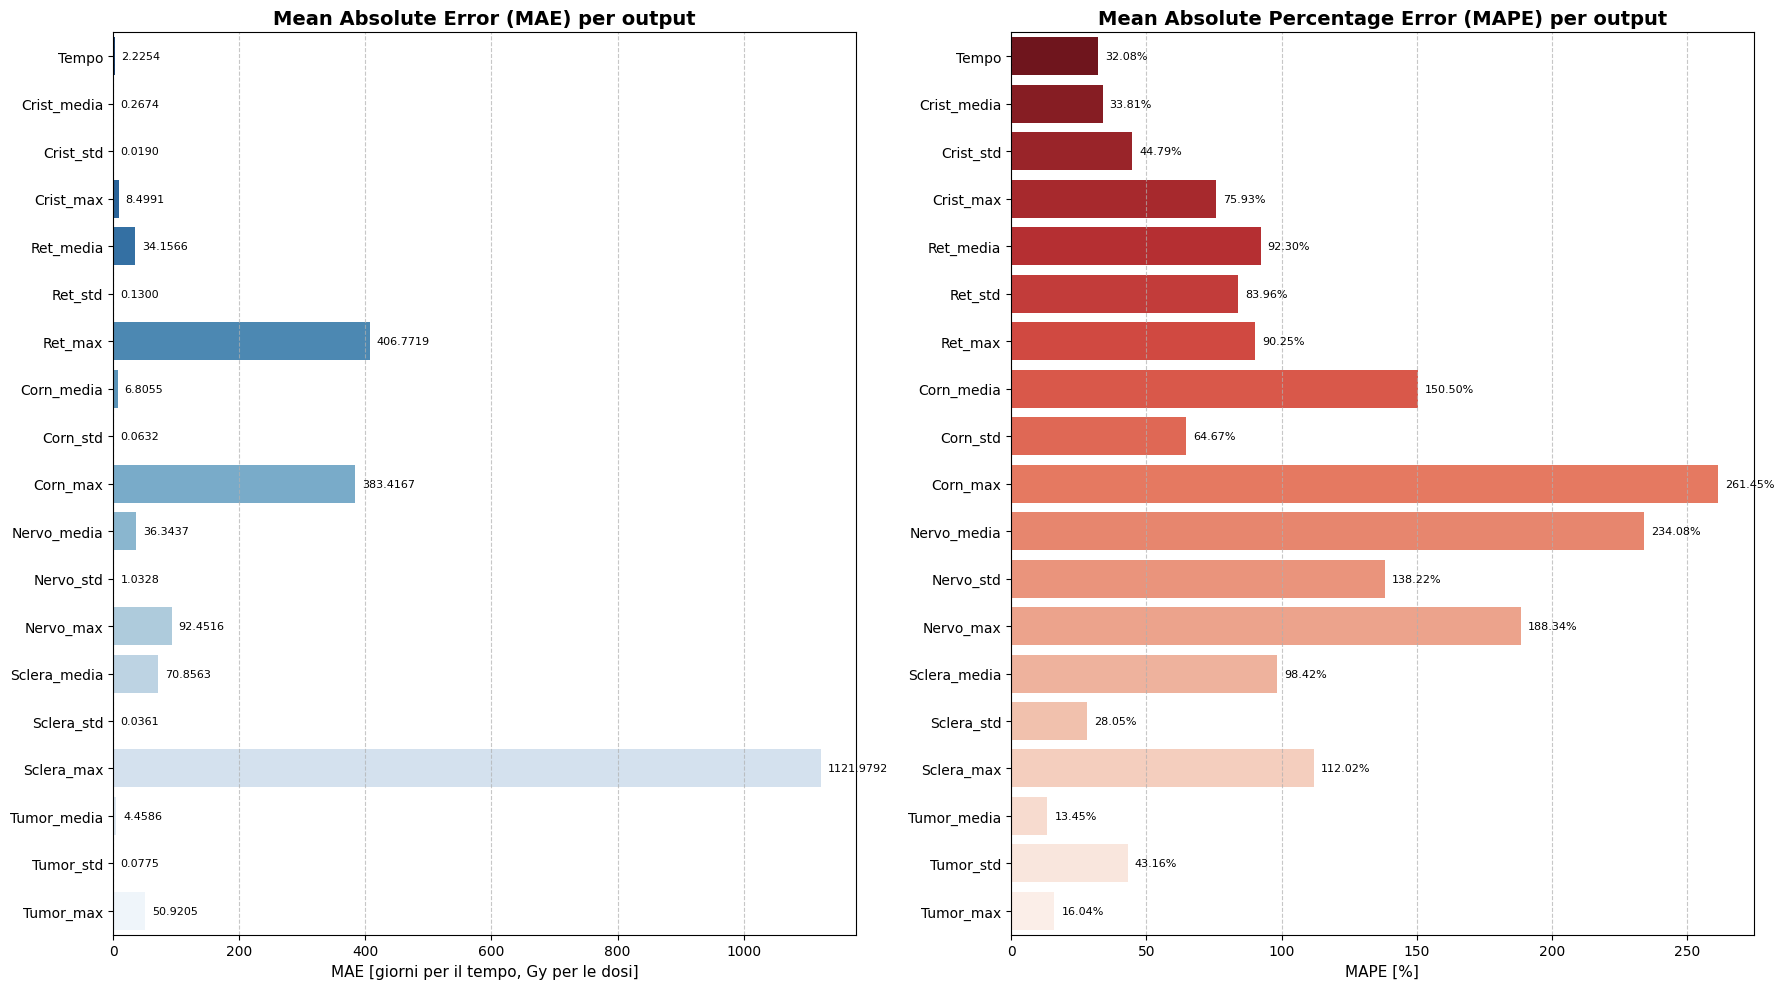

In [15]:
# METRICHE QUANTITATIVE SUL TEST SET

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)


# Controlli preliminari
if y_test_reale.shape != test_pred_reale.shape:
    raise ValueError(
        f"Shape incompatibili: target {y_test_reale.shape}, "
        f"predizioni {test_pred_reale.shape}."
    )

if y_test_reale.ndim != 2:
    raise ValueError(
        f"I target devono essere bidimensionali, "
        f"trovata shape {y_test_reale.shape}."
    )

if y_test_reale.shape[1] != N_OUTPUT:
    raise ValueError(
        f"Attesi {N_OUTPUT} output, "
        f"trovati {y_test_reale.shape[1]}."
    )

if len(y_test_reale) < 2:
    raise ValueError(
        "Il test set deve contenere almeno due campioni."
    )

if not np.all(np.isfinite(y_test_reale)):
    raise ValueError(
        "y_test_reale contiene valori NaN o infiniti."
    )

if not np.all(np.isfinite(test_pred_reale)):
    raise ValueError(
        "test_pred_reale contiene valori NaN o infiniti."
    )


# Nomi e unità degli output
nomi_output = [
    "Tempo"
] + list(COLS_OUTPUT)

if len(nomi_output) != N_OUTPUT:
    raise ValueError(
        f"Sono stati definiti {len(nomi_output)} nomi, "
        f"ma il modello produce {N_OUTPUT} output."
    )

unita_output = [
    "giorni" if indice == 0 else "Gy"
    for indice in range(N_OUTPUT)
]


# Calcolo delle metriche
risultati_metriche = []

for indice, nome in enumerate(nomi_output):

    y_true = y_test_reale[:, indice]
    y_pred = test_pred_reale[:, indice]

    errore = y_pred - y_true
    errore_assoluto = np.abs(errore)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        np.mean(
            errore**2
        )
    )

    bias = np.mean(
        errore
    )

    std_target = np.std(
        y_true,
        ddof=1
    )

    minimo_target = np.min(
        y_true
    )

    massimo_target = np.max(
        y_true
    )

    # Errore percentuale assoluto medio
    # calcolato nello spazio fisico
    denominatore = np.maximum(
        np.abs(y_true),
        1e-12
    )

    errore_percentuale = 100.0 * np.mean(
        errore_assoluto / denominatore
    )

    if np.isclose(
        std_target,
        0.0,
        atol=1e-12,
        rtol=1e-8
    ):
        r2 = np.nan

    else:
        r2 = r2_score(
            y_true,
            y_pred
        )

    risultati_metriche.append({
        "Output": nome,
        "Unità": unita_output[indice],
        "MAE": mae,
        "Errore percentuale [%]": errore_percentuale,
        "RMSE": rmse,
        "Bias": bias,
        "R²": r2,
        "Std target": std_target,
        "Min target": minimo_target,
        "Max target": massimo_target
    })


df_metriche_test = pd.DataFrame(
    risultati_metriche
)


# Controllo numerico della relazione tra RMSE, R² e varianza
for indice, risultato in df_metriche_test.iterrows():

    r2 = risultato["R²"]

    if not np.isfinite(r2):
        continue

    rmse = risultato["RMSE"]
    std_target = risultato["Std target"]

    n_campioni = len(y_test_reale)

    r2_ricostruito = 1.0 - (
        n_campioni * rmse**2
    ) / (
        (n_campioni - 1) * std_target**2
    )

    if not np.isclose(
        r2,
        r2_ricostruito,
        atol=1e-8,
        rtol=1e-6
    ):
        raise RuntimeError(
            f"Controllo di coerenza fallito per "
            f"'{risultato['Output']}': "
            f"R² = {r2:.8f}, "
            f"R² ricostruito = {r2_ricostruito:.8f}."
        )


# Tabella compatta del tempo
df_tempo_compatto = pd.DataFrame({
    "Output": [
        "Tempo di trattamento"
    ],
    "Unità": [
        "giorni"
    ],
    "MAE": [
        df_metriche_test.loc[0, "MAE"]
    ],
    "Errore percentuale [%]": [
        df_metriche_test.loc[
            0,
            "Errore percentuale [%]"
        ]
    ]
})


# Tabella compatta degli organi
organi = [
    "Cristallino",
    "Retina",
    "Cornea",
    "Nervo ottico",
    "Sclera",
    "Tumore"
]

risultati_organi = []

for indice_organo, organo in enumerate(organi):

    indice_media = 1 + 3 * indice_organo
    indice_massimo = indice_media + 2

    risultati_organi.append({
        "Organo": organo,
        "MAE dose media [Gy]": (
            df_metriche_test.loc[
                indice_media,
                "MAE"
            ]
        ),
        "Errore percentuale dose media [%]": (
            df_metriche_test.loc[
                indice_media,
                "Errore percentuale [%]"
            ]
        ),
        "MAE dose massima [Gy]": (
            df_metriche_test.loc[
                indice_massimo,
                "MAE"
            ]
        )
    })


df_organi_compatto = pd.DataFrame(
    risultati_organi
)


# Visualizzazione
print(
    "Metriche sul test set — "
    "riepilogo compatto"
)

print(
    f"Campioni di test: {len(y_test_reale)}"
)

print(
    f"Predizione centrale: {STIMATORE_CENTRALE}"
)

print()
print(
    "Errore sul tempo di trattamento"
)

display(
    df_tempo_compatto.style
    .hide(axis="index")
    .format({
        "MAE": "{:.4f}",
        "Errore percentuale [%]": "{:.2f}"
    })
)

print()
print(
    "Errore sulle dosi medie e massime"
)

display(
    df_organi_compatto.style
    .hide(axis="index")
    .format({
        "MAE dose media [Gy]": "{:.4f}",
        "Errore percentuale dose media [%]": "{:.2f}",
        "MAE dose massima [Gy]": "{:.4f}"
    })
)

# Tabella completa per la relazione: media, std, max di ogni organo
righe_complete = []

for indice_organo, organo in enumerate(organi):

    for etichetta, offset in [
        ("Dose media", 0),
        ("Dev. std.", 1),
        ("Dose massima", 2),
    ]:

        indice = 1 + 3 * indice_organo + offset

        righe_complete.append({
            "Struttura": f"{organo} — {etichetta}",
            "MAE [Gy]": df_metriche_test.loc[indice, "MAE"],
            "MAPE [%]": df_metriche_test.loc[indice, "Errore percentuale [%]"],
        })


df_completo = pd.DataFrame(
    [{
        "Struttura": "Tempo di trattamento",
        "MAE [Gy]": df_metriche_test.loc[0, "MAE"],
        "MAPE [%]": df_metriche_test.loc[0, "Errore percentuale [%]"],
    }]
    + righe_complete
)


print()
print(
    "Tabella completa — MAE e MAPE per tutte le grandezze"
)

display(
    df_completo.style
    .hide(axis="index")
    .format({
        "MAE [Gy]": "{:.4f}",
        "MAPE [%]": "{:.2f}",
    })
)
# GRAFICI DELLE METRICHE SUL TEST SET

import matplotlib.pyplot as plt
import seaborn as sns


# Seleziono le colonne utili per i grafici
df_grafici_metriche = df_metriche_test[
    [
        "Output",
        "MAE",
        "Errore percentuale [%]"
    ]
].copy()

df_grafici_metriche = df_grafici_metriche.rename(
    columns={
        "Errore percentuale [%]": "MAPE [%]"
    }
)


# Controllo che MAE e MAPE contengano valori validi
if not np.all(np.isfinite(df_grafici_metriche["MAE"])):
    raise ValueError(
        "La colonna MAE contiene valori NaN o infiniti."
    )

if not np.all(np.isfinite(df_grafici_metriche["MAPE [%]"])):
    raise ValueError(
        "La colonna MAPE contiene valori NaN o infiniti."
    )


# Creo i due grafici affiancati
plt.figure(figsize=(18, 10))


# Grafico del MAE
plt.subplot(1, 2, 1)

ax_mae = sns.barplot(
    data=df_grafici_metriche,
    x="MAE",
    y="Output",
    hue="Output",
    palette="Blues_r",
    legend=False
)

plt.title(
    "Mean Absolute Error (MAE) per output",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "MAE [giorni per il tempo, Gy per le dosi]",
    fontsize=11
)

plt.ylabel("")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.7
)


# Aggiungo il valore del MAE accanto a ogni barra
for barra in ax_mae.patches:

    valore = barra.get_width()

    ax_mae.annotate(
        f"{valore:.4f}",
        (
            valore,
            barra.get_y() + barra.get_height() / 2
        ),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=8
    )


# Grafico del MAPE
plt.subplot(1, 2, 2)

ax_mape = sns.barplot(
    data=df_grafici_metriche,
    x="MAPE [%]",
    y="Output",
    hue="Output",
    palette="Reds_r",
    legend=False
)

plt.title(
    "Mean Absolute Percentage Error (MAPE) per output",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "MAPE [%]",
    fontsize=11
)

plt.ylabel("")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.7
)


# Aggiungo il valore percentuale accanto a ogni barra
for barra in ax_mape.patches:

    valore = barra.get_width()

    ax_mape.annotate(
        f"{valore:.2f}%",
        (
            valore,
            barra.get_y() + barra.get_height() / 2
        ),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=8
    )


plt.tight_layout()
plt.show()

In [16]:
# DIAGNOSTICA DELLE PRESTAZIONI SUL TEST SET


# Tabella delle metriche di errore
colonne_errore = [
    "Output",
    "Unità",
    "MAE",
    "RMSE",
    "Bias",
    "R²"
]

print(
    "Metriche diagnostiche sul test set — "
    "settore angolare escluso dal training"
)

print(
    f"Campioni di test: {len(y_test_reale)}"
)

print(
    f"Predizione centrale: {STIMATORE_CENTRALE}"
)

display(
    df_metriche_test[
        colonne_errore
    ].style
    .hide(axis="index")
    .format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "Bias": "{:+.4f}",
        "R²": lambda valore: (
            f"{valore:.4f}"
            if np.isfinite(valore)
            else "n.d."
        )
    })
)


# Tabella della scala e della variabilità dei target
colonne_target = [
    "Output",
    "Unità",
    "Std target",
    "Min target",
    "Max target"
]

print()
print(
    "Scala e variabilità dei target Geant4"
)

display(
    df_metriche_test[
        colonne_target
    ].style
    .hide(axis="index")
    .format({
        "Std target": "{:.4f}",
        "Min target": "{:.4f}",
        "Max target": "{:.4f}"
    })
)


# Riepilogo dei coefficienti R²
numero_r2_negativi = int(
    np.sum(
        df_metriche_test["R²"] < 0.0
    )
)

numero_r2_positivi = int(
    np.sum(
        df_metriche_test["R²"] >= 0.0
    )
)

numero_r2_non_definiti = int(
    df_metriche_test["R²"]
    .isna()
    .sum()
)

print()
print("Riepilogo R²")

print(
    f"  Output con R² positivo o nullo: "
    f"{numero_r2_positivi}/{N_OUTPUT}"
)

print(
    f"  Output con R² negativo:         "
    f"{numero_r2_negativi}/{N_OUTPUT}"
)

print(
    f"  Output con R² non definito:     "
    f"{numero_r2_non_definiti}/{N_OUTPUT}"
)

print()
print(
    "Un R² negativo indica prestazioni peggiori "
    "rispetto al predittore costante basato sulla "
    "media del target nel test set."
)

print(
    "Per target caratterizzati da una dispersione molto "
    "ridotta, R² può risultare numericamente molto negativo "
    "e deve essere interpretato insieme a MAE, RMSE e "
    "Std target."
)

Metriche diagnostiche sul test set — settore angolare escluso dal training
Campioni di test: 19
Predizione centrale: deterministica


Output,Unità,MAE,RMSE,Bias,R²
Tempo,giorni,2.2254,2.2554,+2.2254,-1.9188
Crist_media,Gy,0.2674,0.2917,+0.2674,0.0408
Crist_std,Gy,0.0190,0.0254,-0.0148,-4.4653
Crist_max,Gy,8.4991,9.1827,+8.4991,-1.3384
Ret_media,Gy,34.1566,34.5710,+34.1566,-3.0716
Ret_std,Gy,0.1300,0.1337,+0.1300,-3.5347
Ret_max,Gy,406.7719,418.3409,+406.7719,-2.6972
Corn_media,Gy,6.8055,7.7847,+6.8055,-1.0721
Corn_std,Gy,0.0632,0.0752,+0.0584,-1.9675
Corn_max,Gy,383.4167,459.9660,+359.8268,-0.6945



Scala e variabilità dei target Geant4


Output,Unità,Std target,Min target,Max target
Tempo,giorni,1.3563,6.2860,11.5634
Crist_media,Gy,0.3060,0.5912,1.7639
Crist_std,Gy,0.0112,0.0161,0.0620
Crist_max,Gy,6.1696,7.0684,29.7001
Ret_media,Gy,17.6024,27.9581,96.5427
Ret_std,Gy,0.0645,0.1058,0.3788
Ret_max,Gy,223.5297,307.4528,1123.3606
Corn_media,Gy,5.5562,1.7943,20.5205
Corn_std,Gy,0.0449,0.0500,0.1990
Corn_max,Gy,363.0301,49.5800,1249.4846



Riepilogo R²
  Output con R² positivo o nullo: 5/19
  Output con R² negativo:         14/19
  Output con R² non definito:     0/19

Un R² negativo indica prestazioni peggiori rispetto al predittore costante basato sulla media del target nel test set.
Per target caratterizzati da una dispersione molto ridotta, R² può risultare numericamente molto negativo e deve essere interpretato insieme a MAE, RMSE e Std target.


### Valutazione complessiva

Nel complesso, il modello mantiene capacità predittive soltanto per alcuni
output, mentre l'estrapolazione verso il settore near-tumor non risulta
affidabile.

Il risultato non dimostra che l'architettura sia inadeguata in condizioni
interpolative. Evidenzia invece che le prestazioni del surrogate model
dipendono in modo critico dalla copertura angolare del training set.

Una valutazione basata esclusivamente su split casuali potrebbe quindi
fornire una stima eccessivamente ottimistica della capacità di generalizzare
verso regioni geometriche non rappresentate nei dati di addestramento.

## 10. Predizioni e dispersione MC Dropout

### 10.1 Predetto rispetto a Geant4

Le predizioni centrali del surrogate model vengono confrontate con i valori
ottenuti dalle simulazioni Geant4 nel test set. Lo stimatore centrale è quello
selezionato sul validation set nella sezione 7 e rimane invariato durante
l'intera valutazione.

Gli scatter plot riportano separatamente:

- la dose media nei sei organi;
- la dose massima nei sei organi.

Ogni punto rappresenta una configurazione angolare appartenente al settore
escluso dal training. La linea diagonale

$$
\widehat y=y
$$

rappresenta la predizione ideale. I punti al di sopra della diagonale
corrispondono a sovrastime, mentre quelli al di sotto corrispondono a
sottostime.

Per ciascun organo vengono riportati MAE, bias e coefficiente di
determinazione $R^2$. Gli assi hanno gli stessi limiti e la stessa scala,
in modo che la distanza dalla diagonale sia direttamente confrontabile
all'interno di ciascun pannello.

I grafici descrivono la struttura degli errori, ma non consentono da soli di
determinarne la causa. I risultati devono essere interpretati considerando
che l'intero settore near-tumor è assente dal training set.

### Predizione della dose media

Per la maggior parte degli organi a rischio, i punti si collocano
prevalentemente al di sopra della diagonale, indicando una tendenza alla
sovrastima della dose media.

Quando MAE e bias positivo coincidono, tutte le configurazioni del test set
presentano errori dello stesso segno. Nell'esecuzione corrente questo
comportamento interessa diversi organi a rischio.

Il nervo ottico presenta un bias medio positivo, ma la differenza tra MAE e
bias mostra che non tutte le configurazioni vengono sovrastimate. Il suo
coefficiente $R^2$ positivo indica che una parte della variazione tra le
configurazioni viene riprodotta, sebbene rimanga un errore quantitativo
rilevante.

La dose media al tumore presenta invece un bias negativo: il modello tende a
sottostimarla. Il relativo errore percentuale è più contenuto rispetto a
quello di diversi organi a rischio, ma il valore negativo di $R^2$ indica che
la variazione tra le configurazioni non viene riprodotta correttamente.

Nel complesso, la dipendenza angolare della dose media viene ricostruita
soltanto parzialmente nel settore escluso.

### Predizione della dose massima

Anche per la dose massima si osserva una prevalente sovrastima degli organi a
rischio. Per alcune strutture la coincidenza tra MAE e bias positivo indica
che tutte le configurazioni del test set vengono sovrastimate.

Le dosi massime di retina, cornea e sclera presentano errori assoluti elevati
e coefficienti $R^2$ negativi. Il modello non riproduce quindi correttamente
né il livello quantitativo né la variazione di queste quantità nel settore
near-tumor.

Il nervo ottico conserva una correlazione parziale tra valori veri e
predizioni, come indicato dal coefficiente $R^2$ positivo, ma presenta ancora
un bias rilevante.

La dose massima al tumore è l'output con il coefficiente $R^2$ più elevato
nell'esecuzione corrente. Il modello ne riproduce quindi una parte
significativa della variazione angolare, pur mantenendo una tendenza alla
sovrastima.

La dose massima è una statistica di estremo e può essere particolarmente
sensibile ai dettagli locali della distribuzione spaziale. Gli scatter plot
mostrano che la sua estrapolazione risulta più difficile per diversi organi a
rischio.

### Interpretazione

Gli scatter plot evidenziano una capacità di estrapolazione fortemente
dipendente dall'output. Alcune quantità, in particolare la dose massima al
tumore e alcune dosi del nervo ottico, conservano parte della variazione
presente nei dati Geant4. Per molte dosi degli organi a rischio si osservano
invece bias elevati e coefficienti $R^2$ negativi.

Il risultato costituisce una failure analysis del surrogate model nello
splitting patologico adottato. Non rappresenta una stima delle prestazioni
attese in condizioni interpolative, ma mostra i limiti del modello quando la
regione clinicamente rilevante non è rappresentata nei dati di training.

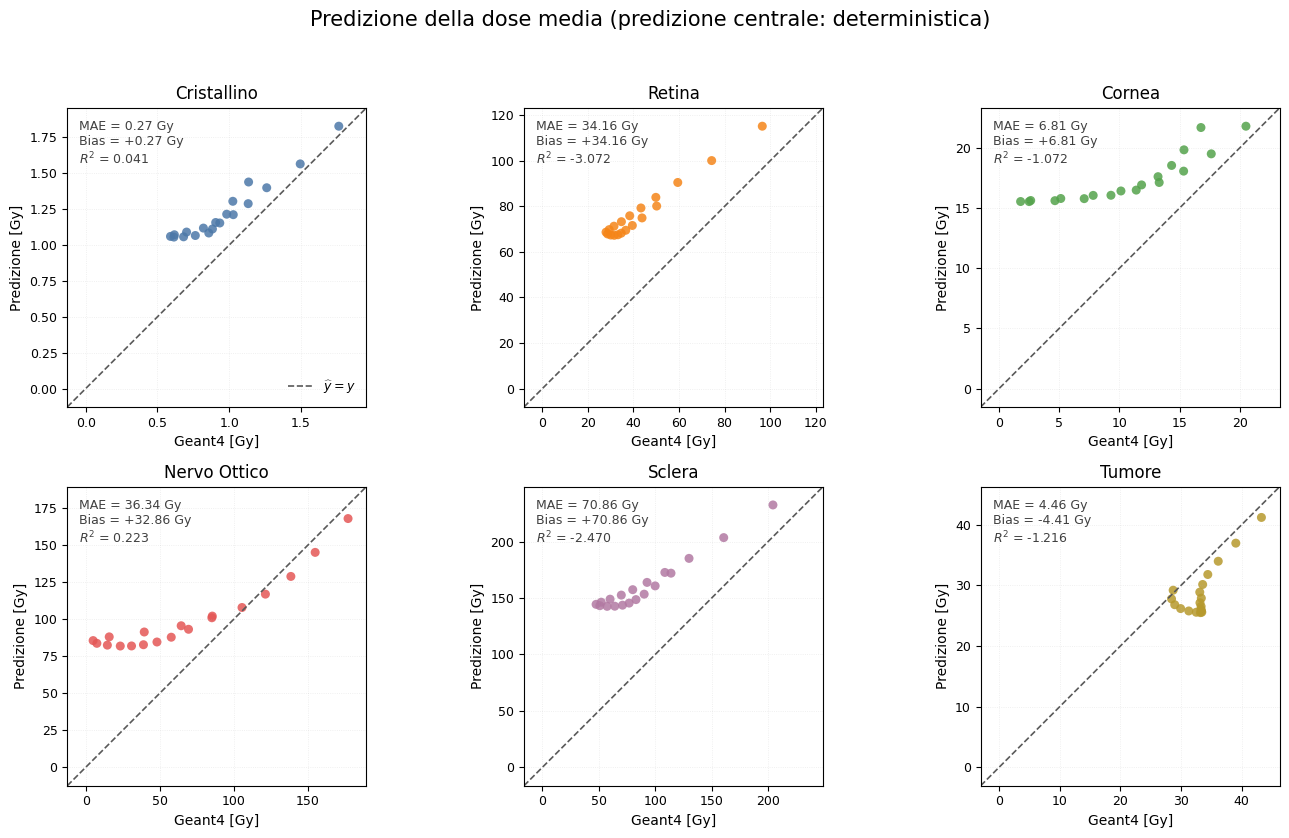

Grafico salvato in: output/scatter_dose_media_continuous_split.png


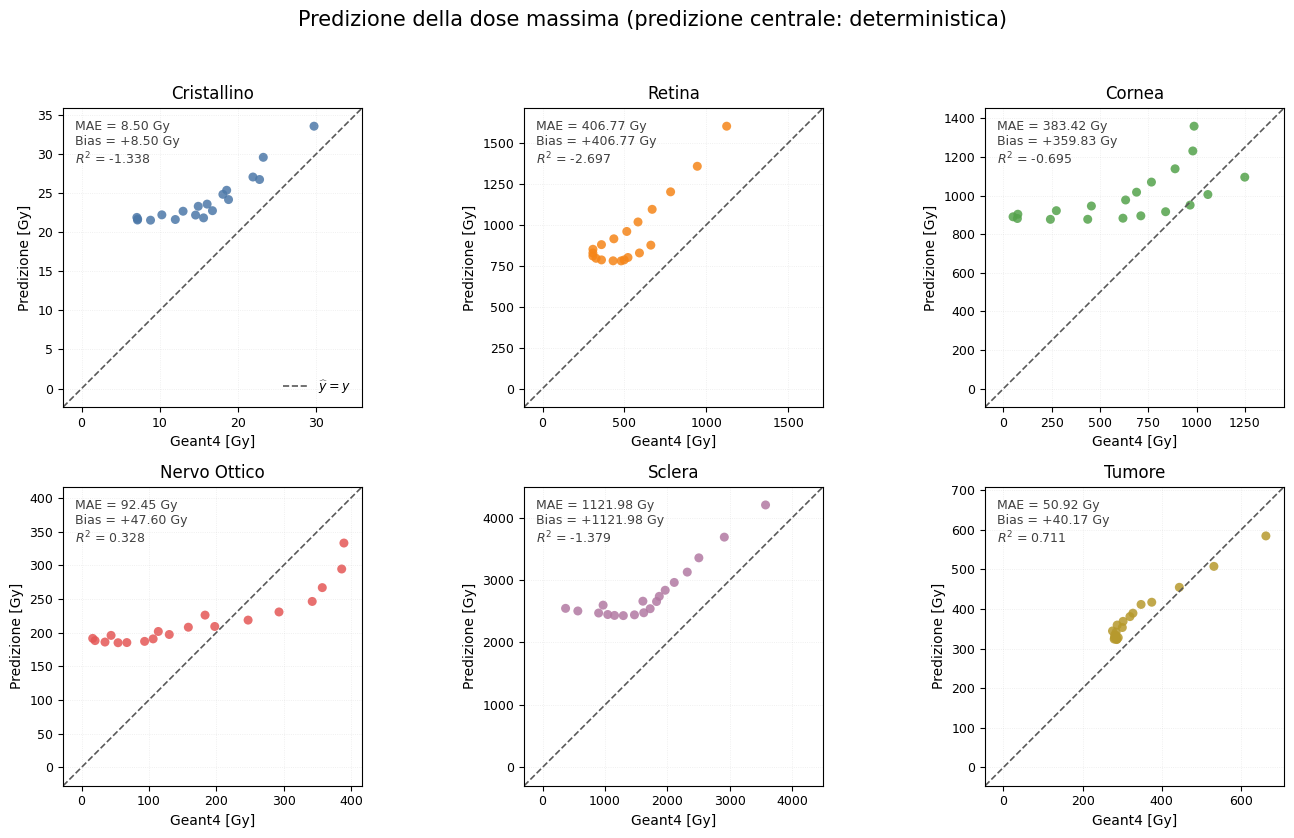

Grafico salvato in: output/scatter_dose_massima_continuous_split.png


In [17]:
# SCATTER PLOT DELLE DOSI SUL TEST SET

COLORI_ORGANI = {
    "Cristallino": "#4C78A8",
    "Retina": "#F58518",
    "Cornea": "#54A24B",
    "Nervo Ottico": "#E45756",
    "Sclera": "#B279A2",
    "Tumore": "#B6992D"
}

COLOR_REFERENCE = "0.35"


# Controlli preliminari
if y_test_reale.shape != test_pred_reale.shape:
    raise ValueError(
        f"Shape incompatibili: target {y_test_reale.shape}, "
        f"predizioni {test_pred_reale.shape}."
    )

if y_test_reale.ndim != 2:
    raise ValueError(
        f"Gli array devono essere bidimensionali, "
        f"trovata shape {y_test_reale.shape}."
    )

if y_test_reale.shape[1] != N_OUTPUT:
    raise ValueError(
        f"Attesi {N_OUTPUT} output, "
        f"trovati {y_test_reale.shape[1]}."
    )

if N_OUTPUT != 19:
    raise ValueError(
        f"La mappa degli indici è definita per 19 output, "
        f"ma N_OUTPUT vale {N_OUTPUT}."
    )

if len(ORGANI) != 6:
    raise ValueError(
        "Devono essere definiti esattamente sei organi."
    )

if set(COLORI_ORGANI) != set(ORGANI):
    raise ValueError(
        "Le chiavi di COLORI_ORGANI non corrispondono "
        "agli organi definiti in ORGANI."
    )

if not np.all(np.isfinite(y_test_reale)):
    raise ValueError(
        "I target del test set contengono NaN o infiniti."
    )

if not np.all(np.isfinite(test_pred_reale)):
    raise ValueError(
        "Le predizioni del test set contengono NaN o infiniti."
    )


# Configurazione dei grafici
configurazioni_scatter = [
    {
        "quantita": "Dose media",
        "indici": [
            1 + 3 * i
            for i in range(len(ORGANI))
        ],
        "titolo": "Predizione della dose media",
        "nome_file": "scatter_dose_media_continuous_split.png"
    },
    {
        "quantita": "Dose massima",
        "indici": [
            3 + 3 * i
            for i in range(len(ORGANI))
        ],
        "titolo": "Predizione della dose massima",
        "nome_file": "scatter_dose_massima_continuous_split.png"
    }
]


# Verifica degli indici utilizzati
for configurazione in configurazioni_scatter:

    if len(configurazione["indici"]) != len(ORGANI):
        raise RuntimeError(
            f"Numero di indici non valido per "
            f"'{configurazione['quantita']}'."
        )

    if any(
        indice < 0 or indice >= N_OUTPUT
        for indice in configurazione["indici"]
    ):
        raise IndexError(
            f"Almeno un indice non è valido per "
            f"'{configurazione['quantita']}'."
        )


# Costruzione degli scatter plot
for configurazione in configurazioni_scatter:

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(14, 8.5)
    )

    axes = axes.ravel()

    fig.suptitle(
        f"{configurazione['titolo']} "
        f"(predizione centrale: {STIMATORE_CENTRALE})",
        fontsize=15
    )

    for i, organo in enumerate(ORGANI):

        indice_output = configurazione[
            "indici"
        ][i]

        valori_veri = y_test_reale[
            :,
            indice_output
        ]

        valori_predetti = test_pred_reale[
            :,
            indice_output
        ]


        # Metriche quantitative
        errore_organo = valori_predetti - valori_veri

        mae = np.mean(
            np.abs(errore_organo)
        )

        bias = np.mean(
            errore_organo
        )

        std_target = np.std(
            valori_veri,
            ddof=1
        )

        if np.isclose(
            std_target,
            0.0,
            atol=1e-12,
            rtol=1e-8
        ):
            r2 = np.nan

        else:
            r2 = r2_score(
                valori_veri,
                valori_predetti
            )


        # Limiti comuni per asse x e asse y
        minimo = min(
            0.0,
            float(valori_veri.min()),
            float(valori_predetti.min())
        )

        massimo = max(
            0.0,
            float(valori_veri.max()),
            float(valori_predetti.max())
        )

        ampiezza = massimo - minimo

        if np.isclose(
            ampiezza,
            0.0,
            atol=1e-12
        ):
            margine = 1.0

        else:
            margine = 0.07 * ampiezza

        limiti = (
            minimo - margine,
            massimo + margine
        )


        # Scatter plot
        ax = axes[i]

        ax.scatter(
            valori_veri,
            valori_predetti,
            s=42,
            alpha=0.85,
            color=COLORI_ORGANI[organo],
            edgecolors="none"
        )

        ax.plot(
            limiti,
            limiti,
            linestyle="--",
            linewidth=1.2,
            color=COLOR_REFERENCE,
            label=r"$\widehat{y}=y$"
        )

        ax.set_xlim(limiti)
        ax.set_ylim(limiti)

        ax.set_aspect(
            "equal",
            adjustable="box"
        )

        ax.set_title(
            organo,
            fontsize=12
        )

        ax.set_xlabel(
            "Geant4 [Gy]",
            fontsize=10
        )

        ax.set_ylabel(
            "Predizione [Gy]",
            fontsize=10
        )

        ax.grid(
            True,
            linestyle=":",
            linewidth=0.6,
            alpha=0.25
        )

        ax.tick_params(
            axis="both",
            labelsize=9
        )


        # Testo delle metriche
        if np.isfinite(r2):

            testo_metriche = (
                f"MAE = {mae:.2f} Gy\n"
                f"Bias = {bias:+.2f} Gy\n"
                rf"$R^2$ = {r2:.3f}"
            )

        else:

            testo_metriche = (
                f"MAE = {mae:.2f} Gy\n"
                f"Bias = {bias:+.2f} Gy\n"
                r"$R^2$ = n.d."
            )

        ax.text(
            0.04,
            0.96,
            testo_metriche,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            color="0.25"
        )


        # La legenda della diagonale viene mostrata una sola volta
        if i == 0:

            ax.legend(
                loc="lower right",
                frameon=False,
                fontsize=9
            )


    fig.tight_layout(
        rect=[
            0.0,
            0.0,
            1.0,
            0.95
        ]
    )

    percorso_output = (
        OUT_DIR
        / configurazione["nome_file"]
    )

    fig.savefig(
        percorso_output,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(
        f"Grafico salvato in: "
        f"{percorso_output}"
    )

In [18]:
# ANALISI MINIMA DELLA STRUTTURA A DOPPIO RAMO

TOLLERANZA_ANGOLO = 1e-6

# Le asimmetrie Geant4 inferiori al 2% sono considerate
# troppo piccole per attribuire un significato stabile al segno.
SOGLIA_ASIMMETRIA = 0.02

theta_rami = np.asarray(
    theta_test_signed,
    dtype=float
)


# Controlli preliminari
if theta_rami.ndim != 1:
    raise ValueError(
        "theta_test_signed deve essere monodimensionale."
    )

if len(theta_rami) != len(y_test_reale):
    raise ValueError(
        "Il numero di angoli non coincide con "
        "il numero di campioni del test set."
    )

if y_test_reale.shape != test_pred_reale.shape:
    raise ValueError(
        f"Shape incompatibili: target {y_test_reale.shape}, "
        f"predizioni {test_pred_reale.shape}."
    )


# Costruzione delle coppie -theta e +theta
angoli_assoluti = np.unique(
    np.round(
        np.abs(
            theta_rami[
                ~np.isclose(
                    theta_rami,
                    0.0,
                    atol=TOLLERANZA_ANGOLO
                )
            ]
        ),
        decimals=8
    )
)

angoli_assoluti.sort()

coppie_angolari = []

for angolo in angoli_assoluti:

    indice_negativo = np.flatnonzero(
        np.isclose(
            theta_rami,
            -angolo,
            atol=TOLLERANZA_ANGOLO
        )
    )

    indice_positivo = np.flatnonzero(
        np.isclose(
            theta_rami,
            angolo,
            atol=TOLLERANZA_ANGOLO
        )
    )

    if (
        len(indice_negativo) != 1
        or len(indice_positivo) != 1
    ):
        raise ValueError(
            f"Coppia angolare incompleta per |theta| = "
            f"{angolo:.1f}°."
        )

    coppie_angolari.append(
        (
            float(angolo),
            int(indice_negativo[0]),
            int(indice_positivo[0])
        )
    )


def calcola_asimmetria(valore_negativo, valore_positivo):
    """
    Asimmetria normalizzata tra +theta e -theta.

    A > 0: valore maggiore a +theta
    A < 0: valore maggiore a -theta
    """

    scala = 0.5 * (
        abs(valore_positivo)
        + abs(valore_negativo)
    )

    if scala <= 1e-12:
        return np.nan

    return (
        valore_positivo
        - valore_negativo
    ) / scala


# Si analizzano soltanto gli output mostrati negli scatter plot
output_analizzati = []

for i, organo in enumerate(ORGANI):

    output_analizzati.append({
        "Output": f"{organo} — dose media",
        "Indice": 1 + 3 * i
    })

    output_analizzati.append({
        "Output": f"{organo} — dose massima",
        "Indice": 3 + 3 * i
    })


righe_rami = []

for output in output_analizzati:

    indice_output = output["Indice"]

    asimmetria_geant4 = []
    asimmetria_predetta = []

    for _, indice_negativo, indice_positivo in coppie_angolari:

        asimmetria_geant4.append(
            calcola_asimmetria(
                y_test_reale[
                    indice_negativo,
                    indice_output
                ],
                y_test_reale[
                    indice_positivo,
                    indice_output
                ]
            )
        )

        asimmetria_predetta.append(
            calcola_asimmetria(
                test_pred_reale[
                    indice_negativo,
                    indice_output
                ],
                test_pred_reale[
                    indice_positivo,
                    indice_output
                ]
            )
        )

    asimmetria_geant4 = np.asarray(
        asimmetria_geant4
    )

    asimmetria_predetta = np.asarray(
        asimmetria_predetta
    )

    valori_validi = (
        np.isfinite(asimmetria_geant4)
        &
        np.isfinite(asimmetria_predetta)
    )

    a_geant4 = asimmetria_geant4[
        valori_validi
    ]

    a_predetta = asimmetria_predetta[
        valori_validi
    ]


    # Correlazione dell'andamento con |theta|
    if (
        len(a_geant4) >= 2
        and not np.isclose(np.std(a_geant4), 0.0)
        and not np.isclose(np.std(a_predetta), 0.0)
    ):

        correlazione = np.corrcoef(
            a_geant4,
            a_predetta
        )[0, 1]

    else:

        correlazione = np.nan


    # Il segno viene confrontato soltanto quando
    # l'asimmetria Geant4 è sufficientemente grande.
    maschera_segno = (
        np.abs(a_geant4)
        >= SOGLIA_ASIMMETRIA
    )

    numero_coppie_segno = int(
        np.sum(maschera_segno)
    )

    if numero_coppie_segno > 0:

        segno_concorde = np.mean(
            np.sign(
                a_geant4[maschera_segno]
            )
            ==
            np.sign(
                a_predetta[maschera_segno]
            )
        )

    else:

        segno_concorde = np.nan


    # Confronto robusto dell'ampiezza dei due rami
    ampiezza_geant4 = np.median(
        np.abs(a_geant4)
    )

    ampiezza_predetta = np.median(
        np.abs(a_predetta)
    )

    if ampiezza_geant4 > 1e-12:

        rapporto_ampiezza = (
            ampiezza_predetta
            / ampiezza_geant4
        )

    else:

        rapporto_ampiezza = np.nan


    righe_rami.append({
        "Output": output["Output"],
        "Correlazione A": correlazione,
        "Segno concorde": segno_concorde,
        "Ampiezza predetta / Geant4": rapporto_ampiezza,
        "Coppie usate per il segno": (
            f"{numero_coppie_segno}/"
            f"{len(coppie_angolari)}"
        )
    })


df_doppio_ramo = pd.DataFrame(
    righe_rami
)

print(
    "Analisi della struttura a doppio ramo"
)

print(
    f"Coppie angolari analizzate: "
    f"{len(coppie_angolari)}"
)

display(
    df_doppio_ramo.style
    .hide(axis="index")
    .format({
        "Correlazione A": lambda valore: (
            f"{valore:.3f}"
            if np.isfinite(valore)
            else "n.d."
        ),
        "Segno concorde": lambda valore: (
            f"{valore:.1%}"
            if np.isfinite(valore)
            else "n.d."
        ),
        "Ampiezza predetta / Geant4": lambda valore: (
            f"{valore:.3f}"
            if np.isfinite(valore)
            else "n.d."
        )
    })
)

Analisi della struttura a doppio ramo
Coppie angolari analizzate: 9


Output,Correlazione A,Segno concorde,Ampiezza predetta / Geant4,Coppie usate per il segno
Cristallino — dose media,0.989,100.0%,0.566,8/9
Cristallino — dose massima,0.701,87.5%,0.563,8/9
Retina — dose media,0.997,100.0%,0.675,9/9
Retina — dose massima,0.982,100.0%,1.366,8/9
Cornea — dose media,0.361,75.0%,0.199,8/9
Cornea — dose massima,-0.881,44.4%,1.673,9/9
Nervo Ottico — dose media,-0.401,100.0%,0.305,9/9
Nervo Ottico — dose massima,-0.369,100.0%,0.203,9/9
Sclera — dose media,0.996,100.0%,0.634,9/9
Sclera — dose massima,0.091,100.0%,0.378,9/9


### Analisi della struttura a doppio ramo

Per alcuni output, lo scatter tra valore Geant4 e predizione presenta una
struttura a doppio ramo. Questa configurazione deriva dalle coppie angolari
$+\theta$ e $-\theta$ e non indica che il modello assegni due valori allo
stesso input.

Per verificare se la separazione dei rami corrisponda a un'asimmetria presente
nelle simulazioni, viene confrontata la quantità

$$
A(\theta)
=
\frac{
y(+\theta)-y(-\theta)
}{
\frac{1}{2}
\left(
|y(+\theta)|+|y(-\theta)|
\right)
}
$$

calcolata sui valori Geant4 e sulle predizioni.

La correlazione tra le due asimmetrie descrive se il modello riproduce
l'evoluzione della separazione al variare di $|\theta|$. La concordanza del
segno indica invece se identifica correttamente quale lato presenta il valore
maggiore. Il rapporto tra le ampiezze misura se il doppio ramo è attenuato,
amplificato oppure riprodotto con il modulo corretto.

Nell'esecuzione corrente, la struttura è riprodotta in modo particolarmente
convincente per la dose media e massima della retina, per la dose media della
sclera e per la dose massima al tumore. Per questi output la correlazione è
elevata e il segno dell'asimmetria è concorde per quasi tutte le coppie.

Per alcune quantità, come la dose media della retina e della sclera, il modello
riproduce correttamente l'andamento ma attenua la separazione tra i rami. Per
la dose massima della retina la separazione risulta invece leggermente
amplificata.

Per nervo ottico e dose massima della sclera, il modello identifica
generalmente il lato corretto, ma non riproduce accuratamente la variazione
dell'asimmetria con l'angolo. La dose massima della cornea presenta infine una
bassa concordanza del segno e una correlazione negativa, per cui il relativo
doppio ramo non può essere considerato una ricostruzione fedele del
comportamento Geant4.

La struttura a doppio ramo è quindi matematicamente motivata e, per alcuni
output, supportata quantitativamente dai dati. La sua affidabilità deve però
essere valutata separatamente per ciascuna quantità e non può essere estesa
automaticamente a tutti gli organi.

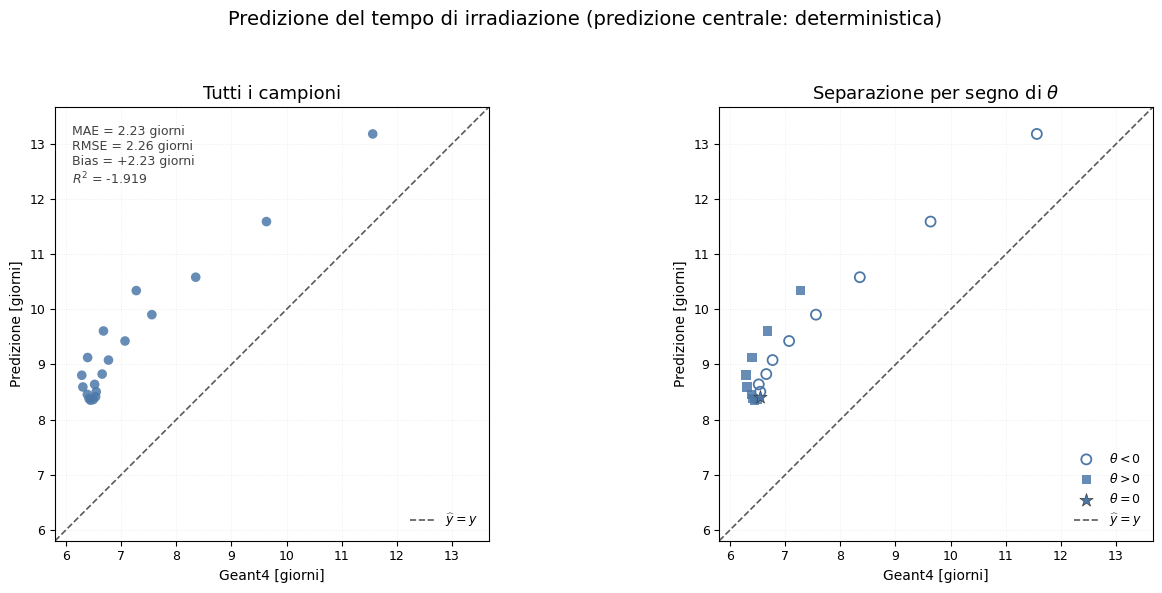

Grafico salvato in:
  output/scatter_tempo_confronto.png


In [19]:
# SCATTER PLOT DEL TEMPO DI IRRADIAZIONE

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


COLOR_TIME = "#4C78A8"
COLOR_REFERENCE = "0.35"


# Controlli preliminari
if y_test_reale.shape != test_pred_reale.shape:
    raise ValueError(
        f"Shape incompatibili: target {y_test_reale.shape}, "
        f"predizioni {test_pred_reale.shape}."
    )

if y_test_reale.ndim != 2:
    raise ValueError(
        f"Gli array devono essere bidimensionali, "
        f"trovata shape {y_test_reale.shape}."
    )

if y_test_reale.shape[1] != N_OUTPUT:
    raise ValueError(
        f"Attesi {N_OUTPUT} output, "
        f"trovati {y_test_reale.shape[1]}."
    )

if len(y_test_reale) < 2:
    raise ValueError(
        "Il test set deve contenere almeno due campioni."
    )

if not np.all(np.isfinite(y_test_reale[:, 0])):
    raise ValueError(
        "I tempi reali contengono valori NaN o infiniti."
    )

if not np.all(np.isfinite(test_pred_reale[:, 0])):
    raise ValueError(
        "Le predizioni del tempo contengono valori NaN o infiniti."
    )


# Dati
tempi_veri = y_test_reale[:, 0]
tempi_predetti = test_pred_reale[:, 0]

theta_tempo = np.asarray(
    theta_test_signed,
    dtype=float
)

if theta_tempo.ndim != 1:
    raise ValueError(
        "theta_test_signed deve essere monodimensionale."
    )

if len(theta_tempo) != len(tempi_veri):
    raise ValueError(
        "Il numero di angoli non coincide con "
        "il numero di campioni del test set."
    )

if not np.all(np.isfinite(theta_tempo)):
    raise ValueError(
        "Gli angoli del test set contengono NaN o infiniti."
    )


# Metriche
errore_tempo = tempi_predetti - tempi_veri

mae = np.mean(
    np.abs(errore_tempo)
)

rmse = np.sqrt(
    np.mean(errore_tempo**2)
)

bias = np.mean(
    errore_tempo
)

std_target = np.std(
    tempi_veri,
    ddof=1
)

if np.isclose(
    std_target,
    0.0,
    atol=1e-12,
    rtol=1e-8
):
    r2 = np.nan

else:
    r2 = r2_score(
        tempi_veri,
        tempi_predetti
    )


# Limiti comuni degli assi
minimo = min(
    float(tempi_veri.min()),
    float(tempi_predetti.min())
)

massimo = max(
    float(tempi_veri.max()),
    float(tempi_predetti.max())
)

ampiezza = massimo - minimo

if np.isclose(
    ampiezza,
    0.0,
    atol=1e-12
):
    margine = 1.0

else:
    margine = 0.07 * ampiezza

limiti = (
    minimo - margine,
    massimo + margine
)


# Testo delle metriche
if np.isfinite(r2):

    testo_metriche = (
        f"MAE = {mae:.2f} giorni\n"
        f"RMSE = {rmse:.2f} giorni\n"
        f"Bias = {bias:+.2f} giorni\n"
        rf"$R^2$ = {r2:.3f}"
    )

else:

    testo_metriche = (
        f"MAE = {mae:.2f} giorni\n"
        f"RMSE = {rmse:.2f} giorni\n"
        f"Bias = {bias:+.2f} giorni\n"
        r"$R^2$ = n.d."
    )


# Separazione degli angoli
mask_zero = np.isclose(
    theta_tempo,
    0.0,
    atol=1e-8
)

mask_negativi = (
    (theta_tempo < 0.0)
    & ~mask_zero
)

mask_positivi = (
    (theta_tempo > 0.0)
    & ~mask_zero
)


# Creo un'unica figura con i due grafici affiancati
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.5, 6.0)
)

ax_sinistra = axes[0]
ax_destra = axes[1]


# Grafico con tutti i campioni
ax_sinistra.scatter(
    tempi_veri,
    tempi_predetti,
    s=48,
    alpha=0.85,
    color=COLOR_TIME,
    edgecolors="none"
)

ax_sinistra.plot(
    limiti,
    limiti,
    linestyle="--",
    linewidth=1.2,
    color=COLOR_REFERENCE,
    label=r"$\widehat{y}=y$"
)

ax_sinistra.set_xlim(limiti)
ax_sinistra.set_ylim(limiti)

ax_sinistra.set_aspect(
    "equal",
    adjustable="box"
)

ax_sinistra.set_title(
    "Tutti i campioni",
    fontsize=13
)

ax_sinistra.set_xlabel(
    "Geant4 [giorni]",
    fontsize=10
)

ax_sinistra.set_ylabel(
    "Predizione [giorni]",
    fontsize=10
)

ax_sinistra.grid(
    True,
    linestyle=":",
    linewidth=0.6,
    alpha=0.25
)

ax_sinistra.tick_params(
    axis="both",
    labelsize=9
)

ax_sinistra.text(
    0.04,
    0.96,
    testo_metriche,
    transform=ax_sinistra.transAxes,
    va="top",
    ha="left",
    fontsize=9,
    color="0.25"
)

ax_sinistra.legend(
    loc="lower right",
    frameon=False,
    fontsize=9
)


# Grafico con separazione per segno dell'angolo
ax_destra.scatter(
    tempi_veri[mask_negativi],
    tempi_predetti[mask_negativi],
    s=52,
    marker="o",
    facecolors="none",
    edgecolors=COLOR_TIME,
    linewidths=1.3,
    label=r"$\theta<0$"
)

ax_destra.scatter(
    tempi_veri[mask_positivi],
    tempi_predetti[mask_positivi],
    s=48,
    marker="s",
    color=COLOR_TIME,
    edgecolors="none",
    alpha=0.85,
    label=r"$\theta>0$"
)

ax_destra.scatter(
    tempi_veri[mask_zero],
    tempi_predetti[mask_zero],
    s=100,
    marker="*",
    color=COLOR_TIME,
    edgecolors="0.25",
    linewidths=0.5,
    label=r"$\theta=0$",
    zorder=5
)

ax_destra.plot(
    limiti,
    limiti,
    linestyle="--",
    linewidth=1.2,
    color=COLOR_REFERENCE,
    label=r"$\widehat{y}=y$"
)

ax_destra.set_xlim(limiti)
ax_destra.set_ylim(limiti)

ax_destra.set_aspect(
    "equal",
    adjustable="box"
)

ax_destra.set_title(
    r"Separazione per segno di $\theta$",
    fontsize=13
)

ax_destra.set_xlabel(
    "Geant4 [giorni]",
    fontsize=10
)

ax_destra.set_ylabel(
    "Predizione [giorni]",
    fontsize=10
)

ax_destra.grid(
    True,
    linestyle=":",
    linewidth=0.6,
    alpha=0.25
)

ax_destra.tick_params(
    axis="both",
    labelsize=9
)

ax_destra.legend(
    loc="lower right",
    frameon=False,
    fontsize=9
)


# Titolo comune
fig.suptitle(
    f"Predizione del tempo di irradiazione "
    f"(predizione centrale: {STIMATORE_CENTRALE})",
    fontsize=14
)

fig.tight_layout(
    rect=[0, 0, 1, 0.94]
)


# Salvataggio
OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

percorso_output = (
    OUT_DIR
    / "scatter_tempo_confronto.png"
)

fig.savefig(
    percorso_output,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    f"Grafico salvato in:\n"
    f"  {percorso_output}"
)

## 11. Learning curves

Le learning curves descrivono l'andamento della loss sul training set e sul
validation set durante l'ottimizzazione.

La loss è calcolata nello spazio dei target trasformati mediante `log1p` e
successivamente standardizzati utilizzando esclusivamente le statistiche del
training set. I suoi valori non sono quindi direttamente interpretabili nelle
unità fisiche originali, ma permettono di confrontare l'evoluzione
dell'ottimizzazione nelle diverse epoche.

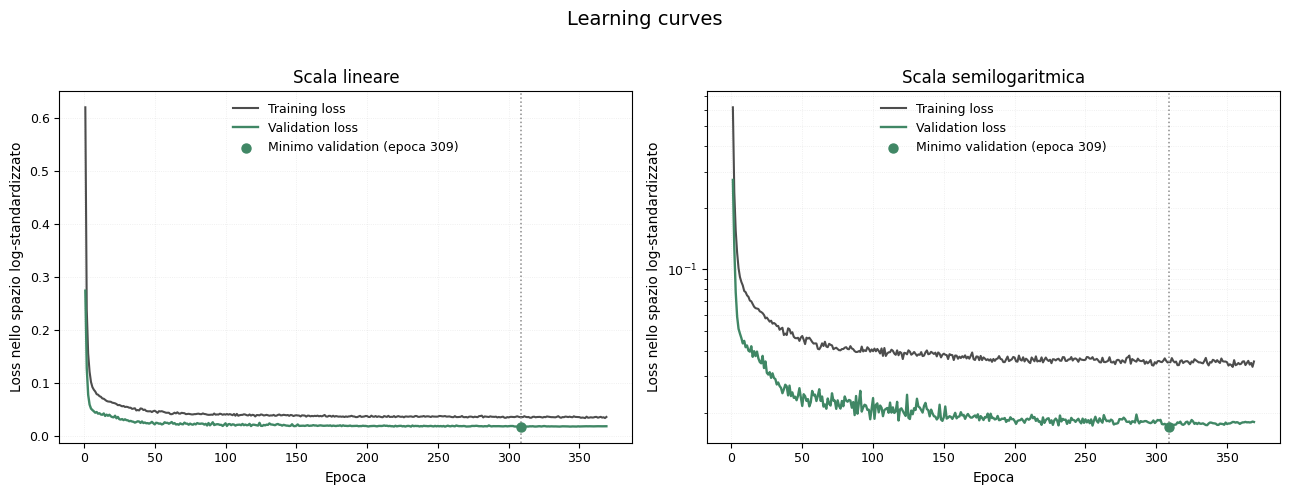

Epoche eseguite: 369
Epoca con validation loss minima: 309
Validation loss minima: 0.017041
Rapporto train/validation nell'ultima epoca: 1.98
Grafici salvati in:
  output/learning_curves_continuous_split.png
  output/learning_curves_lineare.png
  output/learning_curves_semilog.png


In [20]:
# LEARNING CURVES

COLOR_TRAIN = "0.30"
COLOR_VALIDATION = "#408765"
COLOR_REFERENCE = "0.55"


# Preparazione delle loss
train_losses_np = np.asarray(
    train_losses,
    dtype=np.float64
).reshape(-1)

val_losses_np = np.asarray(
    val_losses,
    dtype=np.float64
).reshape(-1)


# Controlli preliminari
if train_losses_np.size == 0:
    raise ValueError(
        "La sequenza train_losses è vuota."
    )

if val_losses_np.size == 0:
    raise ValueError(
        "La sequenza val_losses è vuota."
    )

if train_losses_np.shape != val_losses_np.shape:
    raise ValueError(
        f"Numero di epoche incompatibile: "
        f"training={len(train_losses_np)}, "
        f"validation={len(val_losses_np)}."
    )

if not np.all(np.isfinite(train_losses_np)):
    raise ValueError(
        "train_losses contiene valori NaN o infiniti."
    )

if not np.all(np.isfinite(val_losses_np)):
    raise ValueError(
        "val_losses contiene valori NaN o infiniti."
    )

if np.any(train_losses_np <= 0.0):
    raise ValueError(
        "train_losses contiene valori nulli o negativi, "
        "non compatibili con la scala logaritmica."
    )

if np.any(val_losses_np <= 0.0):
    raise ValueError(
        "val_losses contiene valori nulli o negativi, "
        "non compatibili con la scala logaritmica."
    )


# Epoche e minimo della validation loss
epoche = np.arange(
    1,
    len(train_losses_np) + 1
)

indice_epoca_migliore = int(
    np.argmin(val_losses_np)
)

epoca_migliore_curve = int(
    epoche[indice_epoca_migliore]
)

validation_loss_minima = float(
    val_losses_np[indice_epoca_migliore]
)

if epoca_migliore_curve != best_epoch:
    raise RuntimeError(
        f"Il minimo delle curve ricade all'epoca "
        f"{epoca_migliore_curve}, mentre il training "
        f"ha salvato l'epoca {best_epoch}."
    )


# Funzione che disegna una coppia di curve su un asse dato
def disegna_curve(ax, scala_log):

    ax.plot(
        epoche,
        train_losses_np,
        color=COLOR_TRAIN,
        linewidth=1.5,
        label="Training loss"
    )

    ax.plot(
        epoche,
        val_losses_np,
        color=COLOR_VALIDATION,
        linewidth=1.7,
        label="Validation loss"
    )

    ax.axvline(
        epoca_migliore_curve,
        color=COLOR_REFERENCE,
        linestyle=":",
        linewidth=1.1
    )

    ax.scatter(
        epoca_migliore_curve,
        validation_loss_minima,
        color=COLOR_VALIDATION,
        s=42,
        zorder=3,
        label=(
            f"Minimo validation "
            f"(epoca {epoca_migliore_curve})"
        )
    )

    if scala_log:
        ax.set_yscale("log")
        titolo = "Scala semilogaritmica"
    else:
        titolo = "Scala lineare"

    ax.set_title(
        titolo,
        fontsize=12
    )

    ax.set_xlabel(
        "Epoca",
        fontsize=10
    )

    ax.set_ylabel(
        "Loss nello spazio log-standardizzato",
        fontsize=10
    )

    ax.grid(
        True,
        which="both",
        linestyle=":",
        linewidth=0.6,
        alpha=0.25
    )

    ax.tick_params(
        axis="both",
        labelsize=9
    )

    ax.legend(
        frameon=False,
        fontsize=9
    )


# Figura combinata: lineare (sinistra) e semilogaritmica (destra)
fig, (ax_lin, ax_log) = plt.subplots(
    1,
    2,
    figsize=(13.0, 5.0)
)

disegna_curve(ax_lin, scala_log=False)
disegna_curve(ax_log, scala_log=True)

fig.suptitle(
    "Learning curves",
    fontsize=14
)

fig.tight_layout(
    rect=[0.0, 0.0, 1.0, 0.96]
)

percorso_combinato = (
    OUT_DIR
    / "learning_curves_continuous_split.png"
)

fig.savefig(
    percorso_combinato,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# Salvataggio anche dei due pannelli separati, per l'affiancamento in LaTeX
for scala_log, nome_file in [
    (False, "learning_curves_lineare.png"),
    (True, "learning_curves_semilog.png"),
]:

    fig_singola, ax_singola = plt.subplots(
        figsize=(6.5, 5.0)
    )

    disegna_curve(ax_singola, scala_log=scala_log)

    fig_singola.tight_layout()

    fig_singola.savefig(
        OUT_DIR / nome_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig_singola)


# Riepilogo
rapporto_finale = float(
    train_losses_np[-1]
    / val_losses_np[-1]
)

print(
    f"Epoche eseguite: "
    f"{len(epoche)}"
)

print(
    f"Epoca con validation loss minima: "
    f"{epoca_migliore_curve}"
)

print(
    f"Validation loss minima: "
    f"{validation_loss_minima:.6f}"
)

print(
    f"Rapporto train/validation nell'ultima epoca: "
    f"{rapporto_finale:.2f}"
)

print(
    f"Grafici salvati in:\n"
    f"  {percorso_combinato}\n"
    f"  {OUT_DIR / 'learning_curves_lineare.png'}\n"
    f"  {OUT_DIR / 'learning_curves_semilog.png'}"
)

# Task 2A — Ricerca su griglia della posizione della placca

Dopo aver addestrato e valutato il modello surrogato, la seconda parte
dell'analisi utilizza la rete neurale per confrontare diverse possibili
posizioni angolari della placca.

L'obiettivo è individuare, tra le configurazioni considerate, quelle che
rispettano un insieme di vincoli operativi sul tempo di irradiazione e sulle
dosi medie agli organi a rischio. Le configurazioni ammissibili vengono quindi
ordinate mediante uno score costruito a partire dalle dosi massime predette.

In questa prima fase viene effettuata una ricerca esaustiva sulla stessa griglia
angolare utilizzata per generare il dataset originale:

$$
\theta \in
\left\{
0^\circ,5^\circ,\ldots,355^\circ
\right\}.
$$

La griglia contiene quindi 72 configurazioni, separate da un passo angolare di

$$
\Delta\theta=5^\circ.
$$

Per ciascun valore di $\theta$ viene costruito il vettore di input

$$
\mathbf{x}(\theta)
=
\left[
\sin\theta,\,
\cos\theta,\,
\sin\phi,\,
\cos\phi,\,
r
\right].
$$


Per ogni configurazione il surrogato produce il tempo di irradiazione e le
quantità dosimetriche relative alle strutture anatomiche considerate. Queste
predizioni vengono successivamente utilizzate per applicare i vincoli di
ammissibilità e, qualora l'insieme ammissibile risulti non vuoto, costruire il
ranking delle configurazioni.

La procedura costituisce una ricerca discreta sulla griglia originale e non
una vera ottimizzazione continua: essa può al più identificare il migliore tra
i 72 nodi valutati, senza individuare soluzioni intermedie tra due angoli
consecutivi. Occorre inoltre sottolineare che l'esito dipende dalla natura
dello split adottato. Nel partizionamento a blocchi angolari qui utilizzato,
l'intero settore near-tumor è escluso dal training e dalla validation: come si
osserverà, in questo regime di estrapolazione l'applicazione di soglie assolute
conduce a un insieme ammissibile vuoto,

$$
\Theta_{\mathrm{hard}}=\varnothing,
$$

e la ricerca su griglia non seleziona alcuna configurazione. Questo risultato
non è un limite della procedura, ma la sua conclusione diagnostica: motiva
l'introduzione del ranking gerarchico della Task 2B, in cui l'ordinamento
relativo delle configurazioni sostituisce la classificazione binaria per
soglie, e della successiva ottimizzazione continua della Task 2C.

In [21]:
# TASK 2 — RICERCA DELLA POSIZIONE OTTIMALE DELLA PLACCA

print("\nTask 2 — Ricerca della posizione ottimale con vincoli hard")


# Spazio di ricerca
angoli_gradi = np.arange(
    0,
    360,
    5
)

angoli_rad = np.radians(
    angoli_gradi
)

numero_angoli = len(
    angoli_gradi
)


# Coordinate non angolari, lette dal solo training set.
# Nel dataset attuale phi e r sono costanti.
sin_phi_train = X[idx_train, 2]
cos_phi_train = X[idx_train, 3]
raggio_train = X[idx_train, 4]

if np.ptp(raggio_train) > 1e-9:
    raise ValueError(
        "Il raggio non è costante nel training set: "
        "la costruzione della griglia richiede una revisione."
    )

if np.ptp(sin_phi_train) > 1e-9 or np.ptp(cos_phi_train) > 1e-9:
    raise ValueError(
        "La coordinata phi non è costante nel training set: "
        "la costruzione della griglia richiede una revisione."
    )

sin_phi_fisso = float(sin_phi_train[0])
cos_phi_fisso = float(cos_phi_train[0])
raggio_fisso = float(raggio_train[0])


# Costruzione degli input
X_opt = np.zeros(
    (numero_angoli, N_INPUT),
    dtype=np.float64
)

X_opt[:, 0] = np.sin(
    angoli_rad
)

X_opt[:, 1] = np.cos(
    angoli_rad
)

X_opt[:, 2] = sin_phi_fisso
X_opt[:, 3] = cos_phi_fisso
X_opt[:, 4] = raggio_fisso


# Controlli sugli input
if X_opt.shape != (
    numero_angoli,
    N_INPUT
):
    raise ValueError(
        f"Shape inattesa per X_opt: "
        f"{X_opt.shape}."
    )

if not np.all(np.isfinite(X_opt)):
    raise ValueError(
        "X_opt contiene valori NaN o infiniti."
    )


# Preprocessing degli input
feature_da_scalare = X_opt[
    :,
    COLONNA_INIZIO_SCALING_X:
]

if feature_da_scalare.shape[1] != scaler_X.n_features_in_:
    raise ValueError(
        f"Lo scaler_X richiede "
        f"{scaler_X.n_features_in_} feature, "
        f"ma lo slice selezionato ne contiene "
        f"{feature_da_scalare.shape[1]}."
    )

# Le componenti trigonometriche rimangono inalterate.
# Vengono standardizzate soltanto le feature sulle quali
# scaler_X è stato fittato, attualmente il raggio.
X_opt_scaled = X_opt.copy()

X_opt_scaled[
    :,
    COLONNA_INIZIO_SCALING_X:
] = scaler_X.transform(
    feature_da_scalare
)

if not np.all(
    np.isfinite(X_opt_scaled)
):
    raise ValueError(
        "Il preprocessing degli input ha prodotto "
        "valori NaN o infiniti."
    )


# Conversione in tensore
X_opt_t = torch.as_tensor(
    X_opt_scaled,
    dtype=torch.float32,
    device=device
)


# Predizione con lo stesso stimatore centrale adottato nella Task 1
mc_opt = mc_dropout_predict(
    modello,
    X_opt_t,
    scaler_y,
    num_simulations=NUM_MC_SIMULATIONS,
    mc_seed=MC_SEED
)

stimatori_opt = costruisci_stimatori(
    mc_opt,
    predizione_deterministica(
        modello,
        X_opt_t,
        scaler_y
    ),
    scaler_y
)

pred_reale_opt = stimatori_opt[
    STIMATORE_CENTRALE
]

# Dispersione MC associata, utilizzata per la discussione
std_opt = mc_opt["std_physical_raw"]

if not np.all(
    np.isfinite(pred_reale_opt)
):
    raise ValueError(
        "Le predizioni fisiche contengono "
        "valori NaN o infiniti."
    )


# Indici degli output
IDX_MEDIA = {
    "crist": 1,
    "retina": 4,
    "cornea": 7,
    "nervo": 10,
    "sclera": 13
}

IDX_MAX = {
    "crist": 3,
    "retina": 6,
    "cornea": 9,
    "nervo": 12,
    "sclera": 15
}

IDX_TUMORE_MEDIA = 16


# Estrazione delle quantità utilizzate
tempo_opt = pred_reale_opt[:, 0]

tumore_media_opt = pred_reale_opt[
    :,
    IDX_TUMORE_MEDIA
]

crist_media_opt = pred_reale_opt[
    :,
    IDX_MEDIA["crist"]
]

retina_media_opt = pred_reale_opt[
    :,
    IDX_MEDIA["retina"]
]

cornea_media_opt = pred_reale_opt[
    :,
    IDX_MEDIA["cornea"]
]

nervo_media_opt = pred_reale_opt[
    :,
    IDX_MEDIA["nervo"]
]

sclera_media_opt = pred_reale_opt[
    :,
    IDX_MEDIA["sclera"]
]

crist_max_opt = pred_reale_opt[
    :,
    IDX_MAX["crist"]
]

retina_max_opt = pred_reale_opt[
    :,
    IDX_MAX["retina"]
]

cornea_max_opt = pred_reale_opt[
    :,
    IDX_MAX["cornea"]
]

nervo_max_opt = pred_reale_opt[
    :,
    IDX_MAX["nervo"]
]

sclera_max_opt = pred_reale_opt[
    :,
    IDX_MAX["sclera"]
]


# Soglie operative
LIMITE_TEMPO = 7.0

LIMITE_MEDIA = {
    "crist": 5.0,
    "retina": 45.0,
    "cornea": 50.0,
    "nervo": 55.0,
    "sclera": 100.0
}

# Fattore convenzionale, privo di riferimento clinico,
# usato soltanto per normalizzare le dosi massime
# nel calcolo dello score di ranking.
FATTORE_MAX = 1.5

LIMITE_MAX = {
    nome: FATTORE_MAX * limite
    for nome, limite
    in LIMITE_MEDIA.items()
}


# Controllo della fisicità
indici_ottimizzazione = [
    0,
    IDX_MEDIA["crist"],
    IDX_MEDIA["retina"],
    IDX_MEDIA["cornea"],
    IDX_MEDIA["nervo"],
    IDX_MEDIA["sclera"],
    IDX_MAX["crist"],
    IDX_MAX["retina"],
    IDX_MAX["cornea"],
    IDX_MAX["nervo"],
    IDX_MAX["sclera"]
]

maschera_predizioni_fisiche = np.all(
    pred_reale_opt[
        :,
        indici_ottimizzazione
    ] >= 0.0,
    axis=1
)


# Score normalizzato sulle dosi massime
score_max_oar = (
    crist_max_opt
    / LIMITE_MAX["crist"]

    + retina_max_opt
    / LIMITE_MAX["retina"]

    + cornea_max_opt
    / LIMITE_MAX["cornea"]

    + nervo_max_opt
    / LIMITE_MAX["nervo"]

    + sclera_max_opt
    / LIMITE_MAX["sclera"]
)


# Applicazione dei vincoli hard
vincoli = {
    "Predizioni non fisiche": ~maschera_predizioni_fisiche,
    "Tempo": tempo_opt > LIMITE_TEMPO,
    "Cristallino medio": crist_media_opt > LIMITE_MEDIA["crist"],
    "Retina media": retina_media_opt > LIMITE_MEDIA["retina"],
    "Cornea media": cornea_media_opt > LIMITE_MEDIA["cornea"],
    "Nervo ottico medio": nervo_media_opt > LIMITE_MEDIA["nervo"],
    "Sclera media": sclera_media_opt > LIMITE_MEDIA["sclera"],
}

maschera_violazioni = np.zeros(
    numero_angoli,
    dtype=bool
)

for violazione in vincoli.values():
    maschera_violazioni |= violazione

maschera_vincoli = ~maschera_violazioni

angoli_validi = angoli_gradi[
    maschera_vincoli
]


# Riepilogo delle violazioni
print(
    "\nNumero di configurazioni che violano ciascun vincolo "
    f"(su {numero_angoli}):"
)

for nome_vincolo, violazione in vincoli.items():

    print(
        f"  {nome_vincolo:<24} "
        f"{int(violazione.sum()):3d}"
    )


# Dettaglio sulle configurazioni più prossime all'ammissibilità
NUM_ANGOLI_DETTAGLIO = 5

ordine_per_tempo = np.argsort(tempo_opt)

print(
    f"\nDettaglio delle {NUM_ANGOLI_DETTAGLIO} configurazioni "
    "con tempo predetto minimo:"
)

for i in ordine_per_tempo[:NUM_ANGOLI_DETTAGLIO]:

    motivi = [
        nome
        for nome, violazione in vincoli.items()
        if violazione[i]
    ]

    esito = (
        ", ".join(motivi)
        if motivi
        else "tutti i vincoli soddisfatti"
    )

    print(
        f"  {angoli_gradi[i]:3d}°  "
        f"t = {tempo_opt[i]:7.2f} d  |  {esito}"
    )


# Selezione della configurazione migliore
if len(angoli_validi) == 0:

    df_validi = pd.DataFrame()

    df_ordinato = pd.DataFrame()

    migliore_configurazione = None

    print(
        "\nNessun angolo soddisfa contemporaneamente "
        "tutti i vincoli adottati."
    )

    indice_tempo_minimo = int(
        np.argmin(tempo_opt)
    )

    print(
        f"\nMinimo tempo predetto: "
        f"{tempo_opt[indice_tempo_minimo]:.4f} giorni "
        f"all'angolo {angoli_gradi[indice_tempo_minimo]}°, "
        f"contro un limite di {LIMITE_TEMPO:.1f} giorni."
    )

    print(
        f"Dispersione MC associata: "
        f"{std_opt[indice_tempo_minimo, 0]:.4f} giorni."
    )


else:

    print(
        f"\n{len(angoli_validi)} configurazioni "
        "rispettano tutti i vincoli."
    )

    df_validi = pd.DataFrame({
        "Angolo (°)":
            angoli_validi,

        "Tempo (giorni)":
            tempo_opt[maschera_vincoli],

        "Tumore media (Gy)":
            tumore_media_opt[maschera_vincoli],

        "Crist. media (Gy)":
            crist_media_opt[maschera_vincoli],

        "Retina media (Gy)":
            retina_media_opt[maschera_vincoli],

        "Cornea media (Gy)":
            cornea_media_opt[maschera_vincoli],

        "Nervo media (Gy)":
            nervo_media_opt[maschera_vincoli],

        "Sclera media (Gy)":
            sclera_media_opt[maschera_vincoli],

        "Crist. max (Gy)":
            crist_max_opt[maschera_vincoli],

        "Retina max (Gy)":
            retina_max_opt[maschera_vincoli],

        "Cornea max (Gy)":
            cornea_max_opt[maschera_vincoli],

        "Nervo max (Gy)":
            nervo_max_opt[maschera_vincoli],

        "Sclera max (Gy)":
            sclera_max_opt[maschera_vincoli],

        "Score max OAR":
            score_max_oar[maschera_vincoli]
    })

    df_ordinato = (
        df_validi
        .sort_values(
            by="Score max OAR",
            ascending=True
        )
        .reset_index(drop=True)
    )

    migliore_configurazione = (
        df_ordinato.iloc[0]
    )

    print(
        f"\nMigliore configurazione: "
        f"{int(migliore_configurazione['Angolo (°)'])}°"
    )

    for etichetta in [
        "Tempo (giorni)",
        "Tumore media (Gy)",
        "Crist. media (Gy)",
        "Retina media (Gy)",
        "Cornea media (Gy)",
        "Nervo media (Gy)",
        "Sclera media (Gy)",
        "Score max OAR",
    ]:

        print(
            f"  {etichetta:<20} "
            f"{migliore_configurazione[etichetta]:.4f}"
        )

    print(
        "\nPrime 14 configurazioni valide:"
    )

    display(
        df_ordinato
        .head(14)
        .round(4)
    )


Task 2 — Ricerca della posizione ottimale con vincoli hard

Numero di configurazioni che violano ciascun vincolo (su 72):
  Predizioni non fisiche     0
  Tempo                     72
  Cristallino medio         46
  Retina media              72
  Cornea media              47
  Nervo ottico medio        72
  Sclera media              72

Dettaglio delle 5 configurazioni con tempo predetto minimo:
   10°  t =    8.35 d  |  Tempo, Retina media, Nervo ottico medio, Sclera media
    5°  t =    8.36 d  |  Tempo, Retina media, Nervo ottico medio, Sclera media
   15°  t =    8.38 d  |  Tempo, Retina media, Nervo ottico medio, Sclera media
    0°  t =    8.42 d  |  Tempo, Retina media, Nervo ottico medio, Sclera media
   20°  t =    8.46 d  |  Tempo, Retina media, Nervo ottico medio, Sclera media

Nessun angolo soddisfa contemporaneamente tutti i vincoli adottati.

Minimo tempo predetto: 8.3522 giorni all'angolo 10°, contro un limite di 7.0 giorni.
Dispersione MC associata: 5.2430 giorni.


### Validazione del ranking

La qualità della Task 2B viene valutata confrontando la graduatoria prodotta
dal modello con l'ammissibilità calcolata direttamente sui valori Geant4.

Applicando alle quantità simulate gli stessi vincoli operativi utilizzati
nella Task 2A si ottiene un insieme non vuoto di configurazioni ammissibili
secondo Geant4. La posizione occupata da queste configurazioni nella
graduatoria predetta permette di valutare l'utilità pratica del ranking.

Se le configurazioni ammissibili secondo Geant4 compaiono nelle prime
posizioni, il modello conserva una capacità di ordinamento utile, anche se le
predizioni assolute non sono sufficientemente accurate per applicare
direttamente i vincoli hard.

La validazione non richiede quindi che il surrogato classifichi correttamente
ogni configurazione come ammissibile o non ammissibile. Verifica invece se il
ranking concentri nelle prime posizioni le soluzioni che meritano una
successiva valutazione mediante simulazioni Geant4.

Un bias sistematico può preservare parzialmente l'ordinamento relativo quando
agisce in modo simile sulle diverse configurazioni. Questa proprietà non è
però garantita: errori dipendenti dall'angolo o differenti tra gli output
possono modificare la graduatoria. La capacità di ranking deve pertanto essere
verificata empiricamente confrontando le posizioni assegnate dal surrogato con
l'ammissibilità ottenuta dalle simulazioni.

La Task 2B viene quindi interpretata come una procedura di screening. Il suo
obiettivo non è sostituire la verifica Geant4, ma ridurre il numero di
configurazioni da simulare selezionando prioritariamente quelle considerate
più promettenti dal modello.

In [22]:
# TASK 2B — RANKING GERARCHICO DELLE CONFIGURAZIONI CANDIDATE

print(
    "\nTask 2B — Ranking gerarchico "
    "delle configurazioni candidate"
)


# Controllo delle variabili prodotte dalla Task 2A
variabili_richieste_2b = [
    "pred_reale_opt",
    "angoli_gradi",
    "LIMITE_MEDIA",
    "LIMITE_MAX",
    "IDX_MEDIA",
    "IDX_MAX"
]

variabili_mancanti_2b = [
    nome
    for nome in variabili_richieste_2b
    if nome not in globals()
]

if variabili_mancanti_2b:

    raise NameError(
        "Prima di eseguire la Task 2B è necessario "
        "eseguire la Task 2A. Variabili mancanti: "
        + ", ".join(variabili_mancanti_2b)
    )


# Preparazione degli array
pred_reale_2b = np.asarray(
    pred_reale_opt,
    dtype=np.float64
)

angoli_2b = np.asarray(
    angoli_gradi,
    dtype=int
).reshape(-1)

numero_angoli_2b = len(
    angoli_2b
)


# Controlli preliminari
if N_OUTPUT != 19:

    raise ValueError(
        f"La Task 2B è definita per 19 output, "
        f"ma N_OUTPUT vale {N_OUTPUT}."
    )

if pred_reale_2b.shape != (
    numero_angoli_2b,
    N_OUTPUT
):

    raise ValueError(
        f"Shape inattesa delle predizioni: "
        f"{pred_reale_2b.shape}."
    )


# Le soglie e gli indici sono quelli definiti nella Task 2A
ORGANI_OAR = [
    "crist",
    "retina",
    "cornea",
    "nervo",
    "sclera"
]

IDX_TUMORE_2B = {
    "media": 16,
    "std": 17,
    "max": 18
}


# Parametri delle classi tumorali
SOGLIA_CLASSE_A_2B = 1.05
SOGLIA_CLASSE_B_2B = 1.10
SOGLIA_CLASSE_C_2B = 1.25

TOP_K_2B = 10


# Estrazione delle quantità predette
tempo_2b = pred_reale_2b[:, 0]

tumore_media_2b = pred_reale_2b[
    :,
    IDX_TUMORE_2B["media"]
]

tumore_max_2b = pred_reale_2b[
    :,
    IDX_TUMORE_2B["max"]
]

dose_media_2b = {
    organo: pred_reale_2b[:, IDX_MEDIA[organo]]
    for organo in ORGANI_OAR
}

dose_max_2b = {
    organo: pred_reale_2b[:, IDX_MAX[organo]]
    for organo in ORGANI_OAR
}


# Controllo della fisicità
indici_ranking_2b = (
    [0]
    + [IDX_MEDIA[organo] for organo in ORGANI_OAR]
    + [IDX_MAX[organo] for organo in ORGANI_OAR]
    + [IDX_TUMORE_2B["media"], IDX_TUMORE_2B["max"]]
)

quantita_ranking_2b = pred_reale_2b[
    :,
    indici_ranking_2b
]

maschera_fisica_2b = (
    np.all(
        np.isfinite(
            quantita_ranking_2b
        ),
        axis=1
    )
    & np.all(
        quantita_ranking_2b >= 0.0,
        axis=1
    )
)

numero_fisici_2b = int(
    np.sum(
        maschera_fisica_2b
    )
)

if numero_fisici_2b == 0:

    raise RuntimeError(
        "Nessuna configurazione presenta "
        "predizioni fisiche utilizzabili."
    )


# Indicatore relativo della prestazione tumorale
tempo_minimo_2b = float(
    np.min(
        tempo_2b[
            maschera_fisica_2b
        ]
    )
)

if tempo_minimo_2b <= 0.0:

    raise RuntimeError(
        "Il tempo minimo predetto non è positivo."
    )

rapporto_tempo_2b = np.full(
    numero_angoli_2b,
    np.nan,
    dtype=np.float64
)

rapporto_tempo_2b[
    maschera_fisica_2b
] = (
    tempo_2b[
        maschera_fisica_2b
    ]
    / tempo_minimo_2b
)


# Classificazione tumorale
soglie_classi_2b = [
    ("A", 1, SOGLIA_CLASSE_A_2B),
    ("B", 2, SOGLIA_CLASSE_B_2B),
    ("C", 3, SOGLIA_CLASSE_C_2B),
    ("D", 4, np.inf)
]

classe_tumorale_2b = np.full(
    numero_angoli_2b,
    "Esclusa",
    dtype=object
)

ordine_classe_2b = np.full(
    numero_angoli_2b,
    99,
    dtype=int
)

limite_inferiore = 0.0

for etichetta, ordine, limite_superiore in soglie_classi_2b:

    maschera_classe = (
        maschera_fisica_2b
        & (rapporto_tempo_2b > limite_inferiore)
        & (rapporto_tempo_2b <= limite_superiore)
    )

    classe_tumorale_2b[maschera_classe] = etichetta
    ordine_classe_2b[maschera_classe] = ordine

    limite_inferiore = limite_superiore


# Rapporti normalizzati delle dosi medie agli OAR
rapporti_media_oar_2b = np.column_stack([
    dose_media_2b[organo] / LIMITE_MEDIA[organo]
    for organo in ORGANI_OAR
])

numero_superamenti_oar_2b = np.sum(
    rapporti_media_oar_2b > 1.0,
    axis=1
)

score_eccesso_oar_2b = np.sum(
    np.maximum(
        rapporti_media_oar_2b - 1.0,
        0.0
    ),
    axis=1
)

rapporto_peggiore_oar_2b = np.max(
    rapporti_media_oar_2b,
    axis=1
)


# Score normalizzato sulle dosi massime
rapporti_max_oar_2b = np.column_stack([
    dose_max_2b[organo] / LIMITE_MAX[organo]
    for organo in ORGANI_OAR
])

score_max_oar_2b = np.sum(
    rapporti_max_oar_2b,
    axis=1
)


# Indicatori descrittivi dei limiti assoluti
tempo_entro_limite_2b = (
    tempo_2b
    <= LIMITE_TEMPO
)

tutti_oar_entro_limite_2b = np.all(
    rapporti_media_oar_2b
    <= 1.0,
    axis=1
)


# Ammissibilità reale, valutata sui valori Geant4
mappa_angolo_riga = {
    int(round(angolo)): riga
    for riga, angolo in enumerate(theta_deg)
}

righe_geant4_2b = np.array([
    mappa_angolo_riga[int(angolo)]
    for angolo in angoli_2b
])

y_geant4_2b = y[righe_geant4_2b]

ammissibile_geant4_2b = (
    (y_geant4_2b[:, 0] <= LIMITE_TEMPO)
)

for organo in ORGANI_OAR:

    ammissibile_geant4_2b &= (
        y_geant4_2b[:, IDX_MEDIA[organo]]
        <= LIMITE_MEDIA[organo]
    )


# Identificazione del settore angolare
distanza_angolare_2b = np.minimum(
    angoli_2b,
    360 - angoli_2b
)

settore_2b = np.where(
    distanza_angolare_2b <= SOGLIA_GRADI,
    "near-tumor",
    "far-from-tumor"
)


# DataFrame completo
df_task2b_all = pd.DataFrame({
    "Angolo (°)":
        angoli_2b,

    "Settore":
        settore_2b,

    "Predizione fisica":
        maschera_fisica_2b,

    "Ammissibile Geant4":
        ammissibile_geant4_2b,

    "Classe tumorale":
        classe_tumorale_2b,

    "Ordine classe":
        ordine_classe_2b,

    "Tempo (giorni)":
        tempo_2b,

    "Tempo relativo":
        rapporto_tempo_2b,

    "Tempo entro 7 giorni":
        tempo_entro_limite_2b,

    "Tumore medio (Gy)":
        tumore_media_2b,

    "Tumore max (Gy)":
        tumore_max_2b,

    "Numero superamenti OAR":
        numero_superamenti_oar_2b,

    "Tutti OAR entro limite":
        tutti_oar_entro_limite_2b,

    "Score eccesso OAR":
        score_eccesso_oar_2b,

    "Peggior rapporto OAR":
        rapporto_peggiore_oar_2b,

    "Score max OAR":
        score_max_oar_2b,

    "Crist. media (Gy)":
        dose_media_2b["crist"],

    "Retina media (Gy)":
        dose_media_2b["retina"],

    "Cornea media (Gy)":
        dose_media_2b["cornea"],

    "Nervo media (Gy)":
        dose_media_2b["nervo"],

    "Sclera media (Gy)":
        dose_media_2b["sclera"]
})


# Esclusione delle sole configurazioni non fisiche
df_candidati_2b = (
    df_task2b_all[
        df_task2b_all[
            "Predizione fisica"
        ]
    ]
    .copy()
)


# Ranking lessicografico
criteri_ranking_2b = [
    "Ordine classe",
    "Numero superamenti OAR",
    "Score eccesso OAR",
    "Peggior rapporto OAR",
    "Score max OAR",
    "Tempo relativo",
    "Angolo (°)"
]

df_ranking_2b = (
    df_candidati_2b
    .sort_values(
        by=criteri_ranking_2b,
        ascending=[True] * len(criteri_ranking_2b)
    )
    .reset_index(drop=True)
)

df_ranking_2b.insert(
    0,
    "Posizione",
    np.arange(
        1,
        len(df_ranking_2b) + 1
    )
)


# Selezione dei primi candidati
numero_top_2b = min(
    TOP_K_2B,
    len(df_ranking_2b)
)

df_top_2b = (
    df_ranking_2b
    .head(numero_top_2b)
    .copy()
)

candidato_prioritario_2b = (
    df_ranking_2b.iloc[0]
)


# Report sintetico
indice_tempo_minimo_2b = int(
    np.argmin(
        np.where(
            maschera_fisica_2b,
            tempo_2b,
            np.inf
        )
    )
)

print(
    f"Configurazioni analizzate: "
    f"{numero_angoli_2b}"
)

print(
    f"Configurazioni fisiche incluse: "
    f"{numero_fisici_2b}"
)

print(
    f"\nTempo minimo predetto: "
    f"{tempo_minimo_2b:.3f} giorni "
    f"all'angolo "
    f"{angoli_2b[indice_tempo_minimo_2b]}°"
)


print(
    "\nDistribuzione delle classi tumorali:"
)

distribuzione_classi_2b = (
    df_ranking_2b[
        "Classe tumorale"
    ]
    .value_counts()
    .reindex(
        ["A", "B", "C", "D"],
        fill_value=0
    )
)

for classe, conteggio in (
    distribuzione_classi_2b.items()
):

    print(
        f"  Classe {classe}: "
        f"{conteggio}"
    )


print(
    "\nCandidato prioritario del ranking:"
)

for etichetta, formato in [
    ("Angolo (°)", "{:.0f}°"),
    ("Settore", "{}"),
    ("Classe tumorale", "{}"),
    ("Tempo (giorni)", "{:.3f}"),
    ("Tempo relativo", "{:.4f}"),
    ("Numero superamenti OAR", "{:.0f}"),
    ("Score eccesso OAR", "{:.4f}"),
    ("Peggior rapporto OAR", "{:.4f}"),
    ("Score max OAR", "{:.4f}"),
    ("Ammissibile Geant4", "{}"),
]:

    print(
        f"  {etichetta:<24} "
        + formato.format(
            candidato_prioritario_2b[etichetta]
        )
    )


# Validazione del ranking rispetto ai dati Geant4
numero_ammissibili_geant4 = int(
    ammissibile_geant4_2b.sum()
)

print(
    f"\nValidazione del ranking sui valori Geant4"
)

print(
    f"  Configurazioni realmente ammissibili: "
    f"{numero_ammissibili_geant4}/{numero_angoli_2b}"
)

if numero_ammissibili_geant4 > 0:

    print(
        "  Angoli ammissibili: "
        + ", ".join(
            f"{a}°"
            for a in angoli_2b[ammissibile_geant4_2b]
        )
    )

    posizioni_ammissibili = df_ranking_2b.loc[
        df_ranking_2b["Ammissibile Geant4"],
        "Posizione"
    ].to_numpy()

    print(
        f"  Posizioni nel ranking: "
        + ", ".join(str(p) for p in posizioni_ammissibili)
    )

    print(
        f"  Prima configurazione ammissibile "
        f"in posizione {posizioni_ammissibili.min()} "
        f"su {len(df_ranking_2b)}"
    )


print(
    "\nIl risultato rappresenta una priorità del modello "
    "surrogato e deve essere verificato con Geant4."
)


# Visualizzazione dei primi candidati
colonne_visualizzazione_2b = [
    "Posizione",
    "Angolo (°)",
    "Settore",
    "Classe tumorale",
    "Tempo (giorni)",
    "Tempo relativo",
    "Tumore medio (Gy)",
    "Numero superamenti OAR",
    "Score eccesso OAR",
    "Peggior rapporto OAR",
    "Score max OAR",
    "Ammissibile Geant4"
]

print(
    f"\nPrime {numero_top_2b} configurazioni "
    "del ranking gerarchico:"
)

display(
    df_top_2b[
        colonne_visualizzazione_2b
    ].round(4)
)


Task 2B — Ranking gerarchico delle configurazioni candidate
Configurazioni analizzate: 72
Configurazioni fisiche incluse: 72

Tempo minimo predetto: 8.352 giorni all'angolo 10°

Distribuzione delle classi tumorali:
  Classe A: 8
  Classe B: 4
  Classe C: 4
  Classe D: 56

Candidato prioritario del ranking:
  Angolo (°)               0°
  Settore                  near-tumor
  Classe tumorale          A
  Tempo (giorni)           8.415
  Tempo relativo           1.0075
  Numero superamenti OAR   3
  Score eccesso OAR        1.5248
  Peggior rapporto OAR     1.5549
  Score max OAR            46.3015
  Ammissibile Geant4       True

Validazione del ranking sui valori Geant4
  Configurazioni realmente ammissibili: 7/72
  Angoli ammissibili: 0°, 5°, 10°, 340°, 345°, 350°, 355°
  Posizioni nel ranking: 1, 2, 3, 4, 5, 9, 10
  Prima configurazione ammissibile in posizione 1 su 72

Il risultato rappresenta una priorità del modello surrogato e deve essere verificato con Geant4.

Prime 10 configu

,Posizione,Angolo (°),Settore,Classe tumorale,Tempo (giorni),Tempo relativo,Tumore medio (Gy),Numero superamenti OAR,Score eccesso OAR,Peggior rapporto OAR,Score max OAR,Ammissibile Geant4
0,1,0,near-tumor,A,8.4152,1.0075,26.1028,3,1.5248,1.5549,46.3015,True
1,2,355,near-tumor,A,8.5054,1.0183,26.5501,3,1.5352,1.5507,46.8548,True
2,3,5,near-tumor,A,8.3644,1.0015,25.7863,3,1.5409,1.6005,45.9705,True
3,4,350,near-tumor,A,8.6394,1.0344,27.1450,3,1.5731,1.5842,47.6554,True
4,5,10,near-tumor,A,8.3522,1.0000,25.5931,3,1.5847,1.6602,45.8566,True
5,6,15,near-tumor,A,8.3809,1.0034,25.5231,3,1.6596,1.7368,45.9728,False
6,7,20,near-tumor,A,8.4570,1.0126,25.5852,3,1.7720,1.8348,46.3533,False
7,8,25,near-tumor,A,8.5920,1.0287,25.7983,3,1.9319,1.9607,47.0590,False
8,9,345,near-tumor,B,8.8260,1.0567,27.9147,3,1.6420,1.6281,48.7523,True
9,10,340,near-tumor,B,9.0800,1.0871,28.9013,3,1.7486,1.6857,50.2286,True



# Task 2C — Ottimizzazione differenziabile continua della posizione

Le sezioni precedenti hanno valutato il modello surrogato sui 72 angoli
appartenenti alla griglia originale, caratterizzata da un passo di
$5^\circ$.

In questa sezione la posizione angolare della placca viene invece trattata
come una variabile continua e ottimizzata mediante il gradiente della funzione
obiettivo:

$$
\theta\in\mathbb{R}.
$$

La periodicità viene preservata rappresentando l'angolo mediante

$$
\sin\theta,
\qquad
\cos\theta.
$$

Angoli che differiscono di $2\pi$ producono quindi lo stesso input geometrico.
Non è necessario imporre durante l'ottimizzazione un vincolo esplicito
sull'intervallo di $\theta$.

## Pipeline differenziabile

Tutte le trasformazioni comprese tra l'angolo e la funzione obiettivo vengono
implementate direttamente mediante operazioni PyTorch, in modo da non
interrompere il grafo computazionale.

La pipeline è

$$
\theta
\longrightarrow
\mathbf{x}(\theta)
\longrightarrow
\widetilde{\mathbf{x}}(\theta)
\longrightarrow
f_{\mathrm{NN}}\!\left(
\widetilde{\mathbf{x}}(\theta)
\right)
\longrightarrow
\widehat{\mathbf{y}}(\theta)
\longrightarrow
\mathcal{J}(\theta).
$$

Il vettore geometrico fornito alla rete è

$$
\mathbf{x}(\theta)
=
\left[
\sin\theta,\,
\cos\theta,\,
\sin\phi_0,\,
\cos\phi_0,\,
r_0
\right].
$$

Le coordinate $\phi_0$ e $r_0$ vengono mantenute costanti, poiché non variano
nel dataset disponibile.

La standardizzazione degli input, l'inversione della standardizzazione dei
target e la trasformazione inversa di `log1p` vengono riprodotte in PyTorch
utilizzando le statistiche degli scaler adattati sul training set.

Non viene utilizzato `scaler.transform` durante l'ottimizzazione, perché il
passaggio attraverso NumPy interromperebbe il calcolo del gradiente.

La rete viene mantenuta in modalità di valutazione. Il dropout è quindi
disattivato e la funzione obiettivo è deterministica.

## Funzione obiettivo

La posizione continua viene ricercata mediante

$$
\theta^\star
=
\operatorname*{arg\,min}_{\theta}
\mathcal{J}(\theta).
$$

La funzione obiettivo combina il tempo di irradiazione, le violazioni dei
limiti sulle dosi medie agli organi a rischio, un termine relativo alle dosi
massime e una penalità per eventuali predizioni non fisiche:

$$
\begin{aligned}
\mathcal{J}(\theta)
={}&
w_t
\frac{\widehat{t}(\theta)}{L_t}
\\[2mm]
&+
\lambda_t
\left[
\operatorname{ReLU}
\left(
\frac{\widehat{t}(\theta)}{L_t}-1
\right)
\right]^2
\\[2mm]
&+
\lambda_{\mathrm{OAR}}
\sum_{i\in\mathcal{O}}
\left[
\operatorname{ReLU}
\left(
\frac{
\widehat{D}_{i,\mathrm{mean}}(\theta)
}{
L_i
}
-1
\right)
\right]^2
\\[2mm]
&+
\lambda_{\mathrm{max}}
\sum_{i\in\mathcal{O}}
\frac{
\widehat{D}_{i,\mathrm{max}}(\theta)
}{
S_i
}
\\[2mm]
&+
\lambda_{\mathrm{phys}}
\sum_{j\in\mathcal{Q}}
\left[
\operatorname{ReLU}
\left(
-\widehat{q}_j(\theta)
\right)
\right]^2.
\end{aligned}
$$

In questa espressione:

- $\widehat{t}(\theta)$ è il tempo di irradiazione predetto;
- $L_t$ è il limite operativo sul tempo;
- $\mathcal{O}$ contiene cristallino, retina, cornea, nervo ottico e sclera;
- $\widehat{D}_{i,\mathrm{mean}}$ e
  $\widehat{D}_{i,\mathrm{max}}$ sono la dose media e la dose massima predette
  per l'organo $i$;
- $L_i$ è il limite adottato per la dose media;
- $S_i$ è la scala utilizzata per normalizzare la dose massima;
- $\mathcal{Q}$ contiene il tempo e le dosi medie e massime normalizzate,
  che devono assumere valori non negativi.

Il primo termine favorisce tempi di trattamento ridotti. Nel dataset il tempo
di irradiazione è calcolato rispetto al raggiungimento della prescrizione
tumorale; la prestazione sul tumore è quindi incorporata indirettamente nel
tempo.


Il termine sulle dosi massime agisce invece su tutte le configurazioni e
favorisce la riduzione complessiva dell'esposizione degli organi a rischio.

I coefficienti

$$
w_t,\quad
\lambda_t,\quad
\lambda_{\mathrm{OAR}},\quad
\lambda_{\mathrm{max}},\quad
\lambda_{\mathrm{phys}}
$$

determinano l'importanza relativa dei diversi contributi. I valori adottati
sono parametri operativi della procedura e non rappresentano pesi clinici
validati.

## Ottimizzazione multistart

La funzione obiettivo può essere non convessa e presentare più minimi locali.
L'ottimizzazione viene quindi ripetuta a partire da diversi angoli iniziali.

Per ogni inizializzazione, PyTorch calcola automaticamente

$$
\frac{\partial\mathcal{J}}{\partial\theta}
$$

attraverso la rappresentazione trigonometrica, il preprocessing, la rete
neurale e il postprocessing degli output.

Al termine dell'ottimizzazione, gli angoli vengono riportati nell'intervallo

$$
[0^\circ,360^\circ)
$$

mediante l'operazione modulo. Le soluzioni equivalenti vengono successivamente
raggruppate e la configurazione finale viene scelta confrontando i valori
della funzione obiettivo.


In [23]:
# TASK 2C — PIPELINE DIFFERENZIABILE E FUNZIONE OBIETTIVO

print(
    "\nTask 2C — Preparazione della pipeline differenziabile"
)


# Compatibilità con le variabili della Task 2A
if "SCALA_MAX" not in globals() and "LIMITE_MAX" in globals():
    SCALA_MAX = LIMITE_MAX


# Controllo delle variabili necessarie
variabili_richieste_2c = [
    "modello",
    "device",
    "scaler_X",
    "scaler_y",
    "sin_phi_fisso",
    "cos_phi_fisso",
    "raggio_fisso",
    "COLONNA_INIZIO_SCALING_X",
    "LIMITE_TEMPO",
    "LIMITE_MEDIA",
    "SCALA_MAX",
    "IDX_MEDIA",
    "IDX_MAX",
    "N_INPUT",
    "N_OUTPUT",
]

variabili_mancanti_2c = [
    nome
    for nome in variabili_richieste_2c
    if nome not in globals()
]

if variabili_mancanti_2c:
    raise NameError(
        "Variabili mancanti: "
        + ", ".join(variabili_mancanti_2c)
    )

if N_INPUT != 5 or N_OUTPUT != 19:
    raise ValueError(
        f"Attesi 5 input e 19 output, "
        f"trovati {N_INPUT} e {N_OUTPUT}."
    )

if COLONNA_INIZIO_SCALING_X != 4:
    raise ValueError(
        "La pipeline assume che soltanto il raggio, "
        "corrispondente alla colonna 4, sia standardizzato."
    )


# Il modello rimane fisso durante l'ottimizzazione
modello.eval()

for parametro in modello.parameters():
    parametro.requires_grad_(False)


# Statistiche degli scaler convertite in tensori
x_mean_2c = torch.as_tensor(
    scaler_X.mean_,
    dtype=torch.float32,
    device=device
)

x_scale_2c = torch.as_tensor(
    scaler_X.scale_,
    dtype=torch.float32,
    device=device
)

y_mean_2c = torch.as_tensor(
    scaler_y.mean_,
    dtype=torch.float32,
    device=device
)

y_scale_2c = torch.as_tensor(
    scaler_y.scale_,
    dtype=torch.float32,
    device=device
)

if x_mean_2c.numel() != 1:
    raise ValueError(
        "scaler_X deve contenere le statistiche "
        "della sola coordinata radiale."
    )

if y_mean_2c.numel() != N_OUTPUT:
    raise ValueError(
        "scaler_y non contiene le statistiche "
        "di tutti i 19 target."
    )

if (
    torch.any(x_scale_2c <= 0.0)
    or torch.any(y_scale_2c <= 0.0)
):
    raise ValueError(
        "Le scale degli scaler devono essere positive."
    )


# Indici e soglie utilizzati nella funzione obiettivo
ORGANI_OAR_2C = list(
    LIMITE_MEDIA.keys()
)

if (
    set(ORGANI_OAR_2C) != set(IDX_MEDIA.keys())
    or set(ORGANI_OAR_2C) != set(IDX_MAX.keys())
):
    raise ValueError(
        "Gli organi definiti in LIMITE_MEDIA, "
        "IDX_MEDIA e IDX_MAX non coincidono."
    )

indici_media_2c = [
    IDX_MEDIA[organo]
    for organo in ORGANI_OAR_2C
]

indici_max_2c = [
    IDX_MAX[organo]
    for organo in ORGANI_OAR_2C
]

limiti_media_2c = torch.tensor(
    [
        LIMITE_MEDIA[organo]
        for organo in ORGANI_OAR_2C
    ],
    dtype=torch.float32,
    device=device
)

scale_max_2c = torch.tensor(
    [
        SCALA_MAX[organo]
        for organo in ORGANI_OAR_2C
    ],
    dtype=torch.float32,
    device=device
)


# Pesi della funzione obiettivo
PESO_TEMPO_2C = 1.0
LAMBDA_TEMPO_2C = 1.0
LAMBDA_OAR_2C = 1.0
LAMBDA_MAX_2C = 0.1
LAMBDA_FISICA_2C = 10.0


# Coordinate mantenute costanti
SIN_PHI_FISSO_2C = float(
    sin_phi_fisso
)

COS_PHI_FISSO_2C = float(
    cos_phi_fisso
)

RAGGIO_FISSO_2C = float(
    raggio_fisso
)


# Predizione fisica differenziabile
def predizione_fisica_differenziabile_2c(
    theta_rad
):

    if not torch.is_tensor(theta_rad):
        theta_rad = torch.tensor(
            theta_rad,
            dtype=torch.float32,
            device=device
        )
    else:
        theta_rad = theta_rad.to(
            device=device,
            dtype=torch.float32
        )

    theta_rad = theta_rad.reshape(-1)

    sin_phi = torch.full_like(
        theta_rad,
        SIN_PHI_FISSO_2C
    )

    cos_phi = torch.full_like(
        theta_rad,
        COS_PHI_FISSO_2C
    )

    raggio = torch.full_like(
        theta_rad,
        RAGGIO_FISSO_2C
    )

    raggio_scaled = (
        raggio - x_mean_2c[0]
    ) / x_scale_2c[0]

    X_theta_scaled = torch.stack(
        [
            torch.sin(theta_rad),
            torch.cos(theta_rad),
            sin_phi,
            cos_phi,
            raggio_scaled,
        ],
        dim=1
    )

    pred_scaled = modello(
        X_theta_scaled
    )

    pred_log = (
        pred_scaled * y_scale_2c
        + y_mean_2c
    )

    pred_fisica = torch.expm1(
        pred_log
    )

    return pred_fisica


# Funzione obiettivo differenziabile
def funzione_obiettivo_differenziabile_2c(
    theta_rad,
    restituisci_dettagli=False
):

    pred_fisica = (
        predizione_fisica_differenziabile_2c(
            theta_rad
        )
    )

    tempo_relativo = (
        pred_fisica[:, 0]
        / float(LIMITE_TEMPO)
    )

    rapporti_media = (
        pred_fisica[:, indici_media_2c]
        / limiti_media_2c
    )

    rapporti_max = (
        pred_fisica[:, indici_max_2c]
        / scale_max_2c
    )

    termine_tempo = tempo_relativo

    penalita_tempo = torch.relu(
        tempo_relativo - 1.0
    ).pow(2)

    penalita_oar = torch.relu(
        rapporti_media - 1.0
    ).pow(2).sum(
        dim=1
    )

    termine_max = rapporti_max.sum(
        dim=1
    )

    quantita_normalizzate = torch.cat(
        [
            tempo_relativo.unsqueeze(1),
            rapporti_media,
            rapporti_max,
        ],
        dim=1
    )

    penalita_fisica = torch.relu(
        -quantita_normalizzate
    ).pow(2).sum(
        dim=1
    )

    obiettivo = (
        PESO_TEMPO_2C * termine_tempo
        + LAMBDA_TEMPO_2C * penalita_tempo
        + LAMBDA_OAR_2C * penalita_oar
        + LAMBDA_MAX_2C * termine_max
        + LAMBDA_FISICA_2C * penalita_fisica
    )

    if restituisci_dettagli:
        return {
            "totale": obiettivo,
            "tempo": termine_tempo,
            "penalita_tempo": penalita_tempo,
            "penalita_oar": penalita_oar,
            "dosi_massime": termine_max,
            "penalita_fisica": penalita_fisica,
            "predizioni": pred_fisica,
        }

    return obiettivo


# Verifica del grafo computazionale
theta_prova_2c = torch.tensor(
    [0.0],
    dtype=torch.float32,
    device=device,
    requires_grad=True
)

obiettivo_prova_2c = (
    funzione_obiettivo_differenziabile_2c(
        theta_prova_2c
    ).sum()
)

gradiente_prova_2c = torch.autograd.grad(
    obiettivo_prova_2c,
    theta_prova_2c
)[0]

if not torch.isfinite(
    obiettivo_prova_2c
).item():
    raise RuntimeError(
        "La funzione obiettivo non è finita a theta = 0°."
    )

if not torch.all(
    torch.isfinite(
        gradiente_prova_2c
    )
).item():
    raise RuntimeError(
        "Il gradiente non è finito a theta = 0°."
    )


print(
    "Pipeline differenziabile costruita correttamente."
)

print(
    f"  J(0°) = "
    f"{obiettivo_prova_2c.item():.6f}"
)

print(
    f"  dJ/dtheta a 0° = "
    f"{gradiente_prova_2c.item():+.6e} rad^(-1)"
)


Task 2C — Preparazione della pipeline differenziabile
Pipeline differenziabile costruita correttamente.
  J(0°) = 6.654795
  dJ/dtheta a 0° = -5.753558e-01 rad^(-1)


In [24]:
# TASK 2C — OTTIMIZZAZIONE DIFFERENZIABILE MULTISTART

print(
    "\nTask 2C — Ottimizzazione differenziabile multistart"
)


# Configurazione
ANGOLI_INIZIALI_2C = np.arange(
    0.0,
    360.0,
    30.0
)

N_STEP_2C = 500
LEARNING_RATE_2C = 0.05

PATIENCE_2C = 60
TOLLERANZA_LOSS_2C = 1e-7

TOLLERANZA_DUPLICATI_GRADI_2C = 0.5


# Controllo della funzione obiettivo
if (
    "funzione_obiettivo_differenziabile_2c"
    not in globals()
):
    raise NameError(
        "Eseguire prima la cella che definisce "
        "la pipeline differenziabile della Task 2C."
    )


# Distanza angolare circolare
def distanza_angolare_gradi_2c(
    theta_1,
    theta_2
):

    differenza = (
        abs(float(theta_1) - float(theta_2))
        % 360.0
    )

    return min(
        differenza,
        360.0 - differenza
    )


# Ottimizzazione da una singola inizializzazione
def ottimizza_da_angolo_iniziale_2c(
    theta_iniziale_gradi
):

    theta = torch.tensor(
        [
            np.deg2rad(
                float(theta_iniziale_gradi)
            )
        ],
        dtype=torch.float32,
        device=device,
        requires_grad=True
    )

    optimizer_theta = torch.optim.Adam(
        [theta],
        lr=LEARNING_RATE_2C
    )


    # Valutazione iniziale
    with torch.no_grad():

        loss_iniziale = (
            funzione_obiettivo_differenziabile_2c(
                theta
            )
            .item()
        )


    migliore_loss = float(
        loss_iniziale
    )

    migliore_theta_rad = float(
        theta.detach().item()
    )

    migliore_step = 0
    contatore_senza_miglioramento = 0

    convergenza_regolare = True
    step_eseguiti = 0


    # Ottimizzazione
    for step in range(
        1,
        N_STEP_2C + 1
    ):

        step_eseguiti = step

        optimizer_theta.zero_grad()

        loss = (
            funzione_obiettivo_differenziabile_2c(
                theta
            )
            .sum()
        )


        # Controllo della loss
        if not torch.isfinite(loss).item():

            convergenza_regolare = False
            break


        loss.backward()


        # Controllo del gradiente
        if (
            theta.grad is None
            or not torch.all(
                torch.isfinite(theta.grad)
            ).item()
        ):

            convergenza_regolare = False
            break


        # Limitazione del gradiente
        torch.nn.utils.clip_grad_norm_(
            [theta],
            max_norm=10.0
        )


        optimizer_theta.step()


        # Valutazione dopo l'aggiornamento
        with torch.no_grad():

            loss_corrente = (
                funzione_obiettivo_differenziabile_2c(
                    theta
                )
                .item()
            )


        if not np.isfinite(
            loss_corrente
        ):

            convergenza_regolare = False
            break


        # Salvataggio della migliore soluzione
        if (
            loss_corrente
            < migliore_loss - TOLLERANZA_LOSS_2C
        ):

            migliore_loss = float(
                loss_corrente
            )

            migliore_theta_rad = float(
                theta.detach().item()
            )

            migliore_step = step
            contatore_senza_miglioramento = 0

        else:

            contatore_senza_miglioramento += 1


        # Arresto anticipato
        if (
            contatore_senza_miglioramento
            >= PATIENCE_2C
        ):

            break


    # Angolo riportato nell'intervallo [0°, 360°)
    theta_ottimo_gradi = (
        np.rad2deg(
            migliore_theta_rad
        )
        % 360.0
    )


    return {
        "theta_iniziale_gradi":
            float(theta_iniziale_gradi),

        "theta_ottimo_gradi":
            float(theta_ottimo_gradi),

        "funzione_obiettivo":
            float(migliore_loss),

        "step_migliore":
            int(migliore_step),

        "step_eseguiti":
            int(step_eseguiti),

        "convergenza_regolare":
            bool(convergenza_regolare),
    }


# Esecuzione multistart
risultati_grezzi_2c = []

tempo_inizio_2c = time.perf_counter()


for theta_iniziale in ANGOLI_INIZIALI_2C:

    risultato = (
        ottimizza_da_angolo_iniziale_2c(
            theta_iniziale
        )
    )

    risultati_grezzi_2c.append(
        risultato
    )


tempo_totale_2c = (
    time.perf_counter()
    - tempo_inizio_2c
)


risultati_grezzi_2c = pd.DataFrame(
    risultati_grezzi_2c
)


if risultati_grezzi_2c.empty:

    raise RuntimeError(
        "L'ottimizzazione non ha prodotto risultati."
    )


risultati_grezzi_2c = (
    risultati_grezzi_2c
    .sort_values(
        "funzione_obiettivo",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


# Eliminazione delle soluzioni duplicate
righe_uniche_2c = []


for _, riga in risultati_grezzi_2c.iterrows():

    theta_candidato = float(
        riga["theta_ottimo_gradi"]
    )

    loss_candidata = float(
        riga["funzione_obiettivo"]
    )


    if (
        not np.isfinite(theta_candidato)
        or not np.isfinite(loss_candidata)
    ):

        continue


    duplicato = any(

        distanza_angolare_gradi_2c(
            theta_candidato,
            riga_salvata[
                "theta_ottimo_gradi"
            ]
        )
        < TOLLERANZA_DUPLICATI_GRADI_2C

        for riga_salvata
        in righe_uniche_2c
    )


    if not duplicato:

        righe_uniche_2c.append(
            riga.to_dict()
        )


if len(righe_uniche_2c) == 0:

    raise RuntimeError(
        "Nessuna inizializzazione ha prodotto "
        "una soluzione valida."
    )


risultati_ottimizzazione_2c = pd.DataFrame(
    righe_uniche_2c
)

risultati_ottimizzazione_2c = (
    risultati_ottimizzazione_2c
    .sort_values(
        "funzione_obiettivo",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


# Migliore soluzione
theta_ottimo_2c = float(
    risultati_ottimizzazione_2c.loc[
        0,
        "theta_ottimo_gradi"
    ]
)

loss_ottima_2c = float(
    risultati_ottimizzazione_2c.loc[
        0,
        "funzione_obiettivo"
    ]
)


theta_ottimo_rad_2c = torch.tensor(
    [
        np.deg2rad(
            theta_ottimo_2c
        )
    ],
    dtype=torch.float32,
    device=device
)


with torch.no_grad():

    dettagli_ottimo_2c = (
        funzione_obiettivo_differenziabile_2c(
            theta_ottimo_rad_2c,
            restituisci_dettagli=True
        )
    )

    predizione_ottima_2c = (
        dettagli_ottimo_2c[
            "predizioni"
        ][0]
        .detach()
        .cpu()
        .numpy()
    )


tempo_ottimo_2c = float(
    predizione_ottima_2c[0]
)


# Riepilogo
numero_esecuzioni_regolari_2c = int(
    risultati_grezzi_2c[
        "convergenza_regolare"
    ].sum()
)


print(
    f"Inizializzazioni eseguite: "
    f"{len(ANGOLI_INIZIALI_2C)}"
)

print(
    "Esecuzioni senza anomalie numeriche: "
    f"{numero_esecuzioni_regolari_2c}/"
    f"{len(ANGOLI_INIZIALI_2C)}"
)

print(
    f"Soluzioni distinte trovate: "
    f"{len(risultati_ottimizzazione_2c)}"
)

print(
    f"Tempo di calcolo: "
    f"{tempo_totale_2c:.3f} s"
)


print(
    "\nMigliore soluzione continua"
)

print(
    f"  theta* = "
    f"{theta_ottimo_2c:.4f}°"
)

print(
    f"  J(theta*) = "
    f"{loss_ottima_2c:.6f}"
)

print(
    f"  tempo predetto = "
    f"{tempo_ottimo_2c:.4f} giorni"
)


display(
    risultati_ottimizzazione_2c.head(10)
)


Task 2C — Ottimizzazione differenziabile multistart
Inizializzazioni eseguite: 12
Esecuzioni senza anomalie numeriche: 12/12
Soluzioni distinte trovate: 2
Tempo di calcolo: 1.185 s

Migliore soluzione continua
  theta* = 4.0268°
  J(theta*) = 6.634474
  tempo predetto = 8.3713 giorni


,theta_iniziale_gradi,theta_ottimo_gradi,funzione_obiettivo,step_migliore,step_eseguiti,convergenza_regolare
0,0.0,4.026838,6.634474,156,216,True
1,210.0,181.837312,242986.000000,74,134,True


In [25]:
# TASK 2C — CONFRONTO CON LA GRIGLIA DISCRETA E GEANT4

print(
    "\nTask 2C — Verifica dell'ottimo continuo"
)


# Controllo delle variabili necessarie
variabili_richieste_verifica_2c = [
    "theta_ottimo_2c",
    "loss_ottima_2c",
    "funzione_obiettivo_differenziabile_2c",
    "angoli_2b",
    "y_geant4_2b",
    "candidato_prioritario_2b",
    "LIMITE_TEMPO",
    "LIMITE_MEDIA",
    "SCALA_MAX",
    "IDX_MEDIA",
    "IDX_MAX",
]

variabili_mancanti_verifica_2c = [
    nome
    for nome in variabili_richieste_verifica_2c
    if nome not in globals()
]

if variabili_mancanti_verifica_2c:
    raise NameError(
        "Variabili mancanti: "
        + ", ".join(variabili_mancanti_verifica_2c)
    )


# Funzione obiettivo applicata agli output fisici
def funzione_obiettivo_da_output_2c(
    output_fisici
):

    output_fisici = np.asarray(
        output_fisici,
        dtype=np.float64
    )

    output_fisici = np.atleast_2d(
        output_fisici
    )


    tempo_relativo = (
        output_fisici[:, 0]
        / float(LIMITE_TEMPO)
    )


    rapporti_media = np.column_stack([
        output_fisici[:, IDX_MEDIA[organo]]
        / LIMITE_MEDIA[organo]

        for organo in ORGANI_OAR_2C
    ])


    rapporti_max = np.column_stack([
        output_fisici[:, IDX_MAX[organo]]
        / SCALA_MAX[organo]

        for organo in ORGANI_OAR_2C
    ])


    termine_tempo = tempo_relativo


    penalita_tempo = np.maximum(
        tempo_relativo - 1.0,
        0.0
    ) ** 2


    penalita_oar = np.sum(
        np.maximum(
            rapporti_media - 1.0,
            0.0
        ) ** 2,
        axis=1
    )


    termine_max = np.sum(
        rapporti_max,
        axis=1
    )


    quantita_normalizzate = np.column_stack([
        tempo_relativo,
        rapporti_media,
        rapporti_max,
    ])


    penalita_fisica = np.sum(
        np.maximum(
            -quantita_normalizzate,
            0.0
        ) ** 2,
        axis=1
    )


    return (
        PESO_TEMPO_2C
        * termine_tempo

        + LAMBDA_TEMPO_2C
        * penalita_tempo

        + LAMBDA_OAR_2C
        * penalita_oar

        + LAMBDA_MAX_2C
        * termine_max

        + LAMBDA_FISICA_2C
        * penalita_fisica
    )


# Profilo continuo della funzione obiettivo appresa
PASSO_GRIGLIA_FINE_2C = 0.1

theta_griglia_fine_2c = np.arange(
    0.0,
    360.0,
    PASSO_GRIGLIA_FINE_2C
)


theta_griglia_fine_rad_2c = torch.tensor(
    np.deg2rad(
        theta_griglia_fine_2c
    ),
    dtype=torch.float32,
    device=device
)


with torch.no_grad():

    j_griglia_fine_2c = (
        funzione_obiettivo_differenziabile_2c(
            theta_griglia_fine_rad_2c
        )
        .detach()
        .cpu()
        .numpy()
    )


indice_minimo_fine_2c = int(
    np.argmin(
        j_griglia_fine_2c
    )
)

theta_minimo_fine_2c = float(
    theta_griglia_fine_2c[
        indice_minimo_fine_2c
    ]
)

j_minimo_fine_2c = float(
    j_griglia_fine_2c[
        indice_minimo_fine_2c
    ]
)


# Valutazione del surrogato sulla griglia discreta di 5°
angoli_discreti_2c = np.asarray(
    angoli_2b,
    dtype=np.float64
)


angoli_discreti_rad_2c = torch.tensor(
    np.deg2rad(
        angoli_discreti_2c
    ),
    dtype=torch.float32,
    device=device
)


with torch.no_grad():

    dettagli_discreti_2c = (
        funzione_obiettivo_differenziabile_2c(
            angoli_discreti_rad_2c,
            restituisci_dettagli=True
        )
    )

    j_nn_discreta_2c = (
        dettagli_discreti_2c["totale"]
        .detach()
        .cpu()
        .numpy()
    )

    predizioni_discrete_2c = (
        dettagli_discreti_2c["predizioni"]
        .detach()
        .cpu()
        .numpy()
    )


indice_migliore_nn_discreto_2c = int(
    np.argmin(
        j_nn_discreta_2c
    )
)

theta_migliore_nn_discreto_2c = float(
    angoli_discreti_2c[
        indice_migliore_nn_discreto_2c
    ]
)

j_migliore_nn_discreto_2c = float(
    j_nn_discreta_2c[
        indice_migliore_nn_discreto_2c
    ]
)


# Valutazione della funzione obiettivo sui valori Geant4
j_geant4_2c = funzione_obiettivo_da_output_2c(
    y_geant4_2b
)


indice_migliore_geant4_2c = int(
    np.argmin(
        j_geant4_2c
    )
)

theta_migliore_geant4_2c = float(
    angoli_discreti_2c[
        indice_migliore_geant4_2c
    ]
)

j_migliore_geant4_2c = float(
    j_geant4_2c[
        indice_migliore_geant4_2c
    ]
)


# Configurazioni Geant4 più vicine all'ottimo continuo
differenza_assoluta_2c = np.abs(
    angoli_discreti_2c
    - theta_ottimo_2c
)

distanza_circolare_2c = np.minimum(
    differenza_assoluta_2c,
    360.0 - differenza_assoluta_2c
)


indici_vicini_2c = np.argsort(
    distanza_circolare_2c
)[:2]


df_vicini_2c = pd.DataFrame({
    "Angolo Geant4 (°)":
        angoli_discreti_2c[
            indici_vicini_2c
        ],

    "Distanza da theta* (°)":
        distanza_circolare_2c[
            indici_vicini_2c
        ],

    "J rete neurale":
        j_nn_discreta_2c[
            indici_vicini_2c
        ],

    "J Geant4":
        j_geant4_2c[
            indici_vicini_2c
        ],

    "Tempo NN (giorni)":
        predizioni_discrete_2c[
            indici_vicini_2c,
            0
        ],

    "Tempo Geant4 (giorni)":
        y_geant4_2b[
            indici_vicini_2c,
            0
        ],
})


# Confronto con il candidato della Task 2B
theta_ranking_2b = float(
    candidato_prioritario_2b[
        "Angolo (°)"
    ]
)


indice_ranking_2c = int(
    np.argmin(
        np.minimum(
            np.abs(
                angoli_discreti_2c
                - theta_ranking_2b
            ),
            360.0
            - np.abs(
                angoli_discreti_2c
                - theta_ranking_2b
            )
        )
    )
)


j_ranking_2c = float(
    j_nn_discreta_2c[
        indice_ranking_2c
    ]
)


# Differenze tra le soluzioni
distanza_ottimo_griglia_2c = (
    distanza_angolare_gradi_2c(
        theta_ottimo_2c,
        theta_migliore_nn_discreto_2c
    )
)

distanza_ottimo_geant4_2c = (
    distanza_angolare_gradi_2c(
        theta_ottimo_2c,
        theta_migliore_geant4_2c
    )
)


miglioramento_su_discreto_2c = (
    j_migliore_nn_discreto_2c
    - loss_ottima_2c
)

miglioramento_percentuale_2c = (
    100.0
    * miglioramento_su_discreto_2c
    / max(
        abs(j_migliore_nn_discreto_2c),
        1e-12
    )
)


# Report dei risultati
print(
    "\nConfronto delle soluzioni"
)

print(
    f"  Ottimo tramite Adam:       "
    f"{theta_ottimo_2c:.4f}° "
    f"| J = {loss_ottima_2c:.6f}"
)

print(
    f"  Minimo griglia fine 0.1°: "
    f"{theta_minimo_fine_2c:.4f}° "
    f"| J = {j_minimo_fine_2c:.6f}"
)

print(
    f"  Migliore griglia 5° NN:   "
    f"{theta_migliore_nn_discreto_2c:.0f}° "
    f"| J = {j_migliore_nn_discreto_2c:.6f}"
)

print(
    f"  Candidato Task 2B:        "
    f"{theta_ranking_2b:.0f}° "
    f"| J = {j_ranking_2c:.6f}"
)

print(
    f"  Migliore secondo Geant4:  "
    f"{theta_migliore_geant4_2c:.0f}° "
    f"| J = {j_migliore_geant4_2c:.6f}"
)


print(
    "\nDifferenze"
)

print(
    f"  Distanza tra ottimo continuo "
    f"e migliore punto NN a 5°: "
    f"{distanza_ottimo_griglia_2c:.4f}°"
)

print(
    f"  Distanza tra ottimo continuo "
    f"e migliore Geant4: "
    f"{distanza_ottimo_geant4_2c:.4f}°"
)

print(
    f"  Miglioramento rispetto alla "
    f"migliore configurazione NN discreta: "
    f"{miglioramento_su_discreto_2c:.6f} "
    f"({miglioramento_percentuale_2c:.4f}%)"
)


print(
    "\nConfigurazioni Geant4 più vicine "
    "all'ottimo continuo:"
)

display(
    df_vicini_2c.round(6)
)


Task 2C — Verifica dell'ottimo continuo

Confronto delle soluzioni
  Ottimo tramite Adam:       4.0268° | J = 6.634474
  Minimo griglia fine 0.1°: 4.0000° | J = 6.634480
  Migliore griglia 5° NN:   5° | J = 6.635690
  Candidato Task 2B:        0° | J = 6.654798
  Migliore secondo Geant4:  0° | J = 1.817607

Differenze
  Distanza tra ottimo continuo e migliore punto NN a 5°: 0.9732°
  Distanza tra ottimo continuo e migliore Geant4: 4.0268°
  Miglioramento rispetto alla migliore configurazione NN discreta: 0.001216 (0.0183%)

Configurazioni Geant4 più vicine all'ottimo continuo:


,Angolo Geant4 (°),Distanza da theta* (°),J rete neurale,J Geant4,Tempo NN (giorni),Tempo Geant4 (giorni)
0,5.0,0.973162,6.635690,2.008365,8.364430,6.494997
1,0.0,4.026838,6.654798,1.817607,8.415213,6.537440


## Task 3B — Zona ottima probabilistica dell'angolo
Negli altri modelli è presente anche una TASK 3A che qua non è stato possibile implementare a cusa dei limiti del modello stesso, dato che era basata sull'estrapolazione del vero angolo candiidato ottimale.

Le Task 2A–2C individuano un singolo angolo ottimo, deterministico o
continuo. La Task 3B ne quantifica invece l'**incertezza**: la stessa
ottimizzazione differenziabile della Task 2C viene ripetuta molte volte,
ognuna con una diversa maschera di Dropout mantenuta fissa lungo tutti gli
step. L'insieme degli angoli ottimi così ottenuti definisce una
distribuzione, dalla quale si ricavano media circolare e intervallo
empirico centrale al 95%, ossia la zona angolare entro cui la posizione
ottima della placca risulta stabile rispetto alla variabilità del modello.


   TASK 2D: ESTIMATING PROBABILISTIC CONTINUOUS OPTIMAL ZONE (GRADIENT DESCENT)
Esecuzione di 10000 ottimizzazioni via Gradient Descent con perturbazioni MC Dropout...
Numero di inizializzazioni multistart per run: 12
  └ Run [  20/10000] completata | valide: 20
  └ Run [  40/10000] completata | valide: 40
  └ Run [  60/10000] completata | valide: 60
  └ Run [  80/10000] completata | valide: 80
  └ Run [ 100/10000] completata | valide: 100
  └ Run [ 120/10000] completata | valide: 120
  └ Run [ 140/10000] completata | valide: 140
  └ Run [ 160/10000] completata | valide: 160
  └ Run [ 180/10000] completata | valide: 180
  └ Run [ 200/10000] completata | valide: 200
  └ Run [ 220/10000] completata | valide: 220
  └ Run [ 240/10000] completata | valide: 240
  └ Run [ 260/10000] completata | valide: 260
  └ Run [ 280/10000] completata | valide: 280
  └ Run [ 300/10000] completata | valide: 300
  └ Run [ 320/10000] completata | valide: 320
  └ Run [ 340/10000] completata | valide: 340
  └

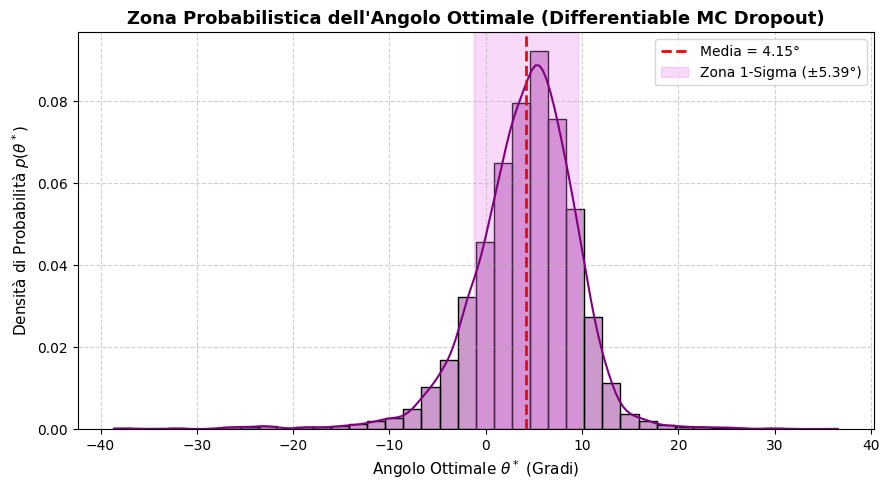


File salvati:
  ├─ output/task2d_ottimi_mc_dropout.csv
  └─ output/probabilistic_continuous_optimal_zone.png


In [26]:
# TASK 3B — ZONA OTTIMA PROBABILISTICA DELL'ANGOLO (MC DROPOUT)
# Ottimizzazione robusta differenziabile: ripetute discese del gradiente
# sull'angolo, ciascuna con una maschera di Dropout fissa, per stimare la
# distribuzione dell'angolo ottimo e la relativa zona di incertezza.

#IMPORT NECESSARI
import seaborn as sns
import torch.optim as optim


print("\n" + "=" * 85)
print("   TASK 2D: ESTIMATING PROBABILISTIC CONTINUOUS OPTIMAL ZONE (GRADIENT DESCENT)")
print("=" * 85)



# CONFIGURAZIONE


n_runs_mc = 10000          # Numero di ottimizzazioni MC indipendenti
n_steps_mc = 150          # Numero massimo di step per ciascuna ottimizzazione
lr_mc = 0.03              # Learning rate dell'angolo
patience_mc = 35          # Early stopping interno
tol_mc = 1e-7             # Miglioramento minimo della funzione obiettivo
seed_mc = SEED + 3000
stampa_ogni = 20



# CONTROLLI PRELIMINARI

variabili_richieste = [
    "modello",
    "device",
    "SEED",
    "OUT_DIR",
    "theta_ottimo_2c",
    "ANGOLI_INIZIALI_2C",
    "funzione_obiettivo_differenziabile_2c",
]

variabili_mancanti = [
    nome
    for nome in variabili_richieste
    if nome not in globals()
]

if variabili_mancanti:
    raise NameError(
        "Variabili mancanti per la Task 2D: "
        + ", ".join(variabili_mancanti)
    )


# Si utilizzano le inizializzazioni multistart definite nella Task 2C
angoli_iniziali_mc = np.asarray(
    ANGOLI_INIZIALI_2C,
    dtype=np.float64,
)


# Individuazione dei layer Dropout presenti nel modello
dropout_modules = [
    modulo
    for modulo in modello.modules()
    if isinstance(modulo, nn.Dropout)
]

if not dropout_modules:
    raise RuntimeError(
        "Il modello non contiene layer Dropout."
    )



# FUNZIONI DI SUPPORTO


def distanza_angolare(theta_1, theta_2):
    """
    Calcola la distanza circolare minima tra due angoli espressi
    in gradi.
    """

    differenza = abs(
        float(theta_1) - float(theta_2)
    ) % 360.0

    return min(
        differenza,
        360.0 - differenza,
    )


def attiva_dropout_fisso(seed):
    """
    Registra una maschera di Dropout fissa per ogni layer.

    Ogni run utilizza una diversa realizzazione stocastica della rete,
    ma la stessa maschera viene mantenuta durante tutti gli step della
    corrispondente ottimizzazione differenziabile.
    """

    torch.manual_seed(int(seed))

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

    maschere_dropout = {}
    handles = []

    def crea_hook(indice_modulo):

        def hook_dropout(modulo, inputs, output):

            x = inputs[0]

            if modulo.p == 0.0:
                return x

            # La prima dimensione viene posta pari a 1:
            # la stessa maschera viene applicata a tutti i multistart.
            if x.ndim >= 2:
                forma_maschera = (1, *x.shape[1:])
            else:
                forma_maschera = tuple(x.shape)

            chiave = (
                indice_modulo,
                tuple(forma_maschera),
                x.device.type,
                x.dtype,
            )

            if chiave not in maschere_dropout:

                probabilita_keep = 1.0 - float(modulo.p)

                maschera = (
                    torch.rand(
                        forma_maschera,
                        dtype=x.dtype,
                        device=x.device,
                    )
                    < probabilita_keep
                ).to(x.dtype)

                # Inverted dropout:
                # stesso riscalamento utilizzato da PyTorch
                maschere_dropout[chiave] = (
                    maschera / probabilita_keep
                )

            return x * maschere_dropout[chiave]

        return hook_dropout

    for indice, modulo in enumerate(dropout_modules):

        handle = modulo.register_forward_hook(
            crea_hook(indice)
        )

        handles.append(handle)

    return handles


def ottimizza_singola_run_mc(indice_run):
    """
    Esegue un'ottimizzazione multistart sotto una singola
    realizzazione fissa del Dropout.
    """

    seed_run = seed_mc + indice_run

    # Deve essere definito prima del try:
    # in questo modo il finally è sempre sicuro.
    handles = []

    try:

        handles = attiva_dropout_fisso(seed_run)

        # Tutti i punti iniziali vengono ottimizzati in parallelo
        theta_param = torch.tensor(
            np.deg2rad(angoli_iniziali_mc),
            dtype=torch.float32,
            device=device,
            requires_grad=True,
        )

        optimizer_plaque = optim.Adam(
            [theta_param],
            lr=lr_mc,
        )

        # Valutazione iniziale
        with torch.no_grad():

            migliori_loss = (
                funzione_obiettivo_differenziabile_2c(
                    theta_param
                )
                .detach()
                .clone()
            )

        if not torch.all(
            torch.isfinite(migliori_loss)
        ).item():

            raise FloatingPointError(
                "Loss iniziale non finita."
            )

        migliori_theta = theta_param.detach().clone()

        migliore_loss_globale = float(
            migliori_loss.min().item()
        )

        migliore_step = 0
        contatore_patience = 0
        step_eseguiti = 0



        # GRADIENT DESCENT


        for step in range(1, n_steps_mc + 1):

            step_eseguiti = step

            optimizer_plaque.zero_grad(
                set_to_none=True
            )

            loss_vettore = (
                funzione_obiettivo_differenziabile_2c(
                    theta_param
                )
            )

            if not torch.all(
                torch.isfinite(loss_vettore)
            ).item():

                raise FloatingPointError(
                    "Loss non finita."
                )

            # Ogni componente corrisponde a un diverso multistart
            loss_vettore.sum().backward()

            if (
                theta_param.grad is None
                or not torch.all(
                    torch.isfinite(theta_param.grad)
                ).item()
            ):

                raise FloatingPointError(
                    "Gradiente non finito."
                )

            torch.nn.utils.clip_grad_norm_(
                [theta_param],
                max_norm=10.0,
            )

            optimizer_plaque.step()

            # Riporta gli angoli nell'intervallo [-pi, pi)
            with torch.no_grad():

                theta_param.copy_(
                    torch.remainder(
                        theta_param + np.pi,
                        2.0 * np.pi,
                    )
                    - np.pi
                )

                loss_correnti = (
                    funzione_obiettivo_differenziabile_2c(
                        theta_param
                    )
                    .detach()
                )

            if not torch.all(
                torch.isfinite(loss_correnti)
            ).item():

                raise FloatingPointError(
                    "Loss aggiornata non finita."
                )

            # Migliore risultato raggiunto da ciascun multistart
            migliorati = (
                loss_correnti
                < migliori_loss - tol_mc
            )

            migliori_loss = torch.where(
                migliorati,
                loss_correnti,
                migliori_loss,
            )

            migliori_theta = torch.where(
                migliorati,
                theta_param.detach(),
                migliori_theta,
            )

            nuova_migliore_loss = float(
                migliori_loss.min().item()
            )

            if (
                nuova_migliore_loss
                < migliore_loss_globale - tol_mc
            ):

                migliore_loss_globale = (
                    nuova_migliore_loss
                )

                migliore_step = step
                contatore_patience = 0

            else:

                contatore_patience += 1

            if contatore_patience >= patience_mc:
                break



        # SELEZIONE DEL MIGLIORE MULTISTART

        indice_migliore = int(
            torch.argmin(migliori_loss).item()
        )

        theta_ottimo = float(
            np.rad2deg(
                migliori_theta[indice_migliore].item()
            )
            % 360.0
        )

        loss_ottima = float(
            migliori_loss[indice_migliore].item()
        )

        return {
            "run": indice_run,
            "seed": seed_run,
            "theta_ottimo_gradi": theta_ottimo,
            "funzione_obiettivo": loss_ottima,
            "step_migliore": migliore_step,
            "step_eseguiti": step_eseguiti,
            "convergenza_regolare": True,
        }

    except FloatingPointError as errore:

        print(
            f"Attenzione: run {indice_run + 1} non valida: "
            f"{errore}"
        )

        return {
            "run": indice_run,
            "seed": seed_run,
            "theta_ottimo_gradi": np.nan,
            "funzione_obiettivo": np.nan,
            "step_migliore": 0,
            "step_eseguiti": 0,
            "convergenza_regolare": False,
        }

    finally:

        # Rimozione sicura degli hook
        for handle in handles:
            handle.remove()



# ESECUZIONE DELLE OTTIMIZZAZIONI MC DROPOUT

# Salvataggio dello stato originale del modello
modalita_training_originale = modello.training

requires_grad_originali = [
    parametro.requires_grad
    for parametro in modello.parameters()
]

# Congelamento dei pesi della rete
for parametro in modello.parameters():
    parametro.requires_grad_(False)

# Il modello resta globalmente in evaluation mode.
# Le maschere di Dropout sono applicate tramite gli hook.
modello.eval()

risultati_mc = []
tempo_inizio = time.perf_counter()

print(
    f"Esecuzione di {n_runs_mc} ottimizzazioni via Gradient Descent "
    "con perturbazioni MC Dropout..."
)

print(
    f"Numero di inizializzazioni multistart per run: "
    f"{len(angoli_iniziali_mc)}"
)

try:

    for run in range(n_runs_mc):

        risultato_run = ottimizza_singola_run_mc(run)

        risultati_mc.append(
            risultato_run
        )

        if (
            (run + 1) % stampa_ogni == 0
            or run + 1 == n_runs_mc
        ):

            n_valide = sum(
                risultato["convergenza_regolare"]
                for risultato in risultati_mc
            )

            print(
                f"  └ Run [{run + 1:4d}/{n_runs_mc}] completata "
                f"| valide: {n_valide}"
            )

finally:

    # Ripristino dello stato originale dei parametri
    for parametro, stato in zip(
        modello.parameters(),
        requires_grad_originali,
    ):

        parametro.requires_grad_(stato)

    # Ripristino della modalità iniziale del modello
    modello.train(
        modalita_training_originale
    )

tempo_totale = (
    time.perf_counter()
    - tempo_inizio
)



# RACCOLTA DEI RISULTATI


risultati_mc = pd.DataFrame(
    risultati_mc
)

risultati_mc_validi = (
    risultati_mc[
        risultati_mc["convergenza_regolare"]
    ]
    .dropna(
        subset=[
            "theta_ottimo_gradi",
            "funzione_obiettivo",
        ]
    )
    .reset_index(drop=True)
)

if len(risultati_mc_validi) < 2:

    raise RuntimeError(
        "Sono necessarie almeno due ottimizzazioni MC valide."
    )

angoli_ottimi_continui = (
    risultati_mc_validi[
        "theta_ottimo_gradi"
    ]
    .to_numpy(dtype=np.float64)
)

losses_ottime = (
    risultati_mc_validi[
        "funzione_obiettivo"
    ]
    .to_numpy(dtype=np.float64)
)



# ANALISI STATISTICA CIRCOLARE

# Media circolare degli angoli ottimi
vettore_medio = np.mean(
    np.exp(
        1j * np.deg2rad(
            angoli_ottimi_continui
        )
    )
)

media_angolo_deg = float(
    np.rad2deg(
        np.angle(vettore_medio)
    )
    % 360.0
)

concentrazione_circolare = float(
    np.abs(vettore_medio)
)

# Scarti firmati rispetto alla media circolare in [-180°, 180°)
scarti_angolari = (
    (
        angoli_ottimi_continui
        - media_angolo_deg
        + 180.0
    )
    % 360.0
    - 180.0
)

std_angolo = float(
    np.std(
        scarti_angolari,
        ddof=1,
    )
)

# Angoli srotolati attorno alla media per la visualizzazione
angoli_plot = (
    media_angolo_deg
    + scarti_angolari
)

# Intervallo empirico centrale al 95%
q025, q975 = np.quantile(
    scarti_angolari,
    [0.025, 0.975],
)

limite_basso_95 = float(
    (
        media_angolo_deg
        + q025
    )
    % 360.0
)

limite_alto_95 = float(
    (
        media_angolo_deg
        + q975
    )
    % 360.0
)

distanza_deterministico = distanza_angolare(
    media_angolo_deg,
    theta_ottimo_2c,
)



# STAMPA DEI RISULTATI


print("\n" + "*" * 85)
print(" 🎯 RISULTATI DELL'OTTIMIZZAZIONE PROBABILISTICA CONTINUA")
print("*" * 85)

print(
    f" Run valide                           : "
    f"{len(risultati_mc_validi)}/{n_runs_mc}"
)

print(
    f" Tempo totale                         : "
    f"{tempo_totale:.3f} s"
)

print(
    f" Angolo Ottimale Deterministico       : "
    f"{theta_ottimo_2c:.2f}°"
)

print(
    f" Angolo Ottimale Medio (Mean θ*)      : "
    f"{media_angolo_deg:.2f}°"
)

print(
    f" Incertezza/Deviazione Standard (σ_θ) : "
    f"±{std_angolo:.2f}°"
)

print(
    f" Zona Probabilistica Empirica (95%)   : "
    f"[{limite_basso_95:.2f}°, "
    f"{limite_alto_95:.2f}°]"
)

if limite_basso_95 > limite_alto_95:

    print(
        "                                        "
        "(l'intervallo attraversa 0°/360°)"
    )

print(
    f" Distanza dall'Ottimo Deterministico   : "
    f"{distanza_deterministico:.2f}°"
)

print(
    f" Concentrazione Circolare R            : "
    f"{concentrazione_circolare:.6f}"
)

print(
    f" Loss Ottima Media                     : "
    f"{losses_ottime.mean():.6f} "
    f"± {losses_ottime.std(ddof=1):.6f}"
)

print("*" * 85)

print(
    "\nLa zona al 95% descrive la dispersione empirica degli "
    "angoli ottimi indotta dal Dropout e non rappresenta un "
    "intervallo di confidenza clinico formalmente calibrato."
)



# SALVATAGGIO DEI RISULTATI


file_csv = (
    OUT_DIR
    / "task2d_ottimi_mc_dropout.csv"
)

risultati_mc.to_csv(
    file_csv,
    index=False,
)



# GRAFICO: STIMA DELLA DENSITÀ DI PROBABILITÀ
# KDE / GAUSSIANA CONTINUA


plt.figure(figsize=(9, 5))

# Istogramma + curva di densità continua KDE
sns.histplot(
    angoli_plot,
    kde=True,
    color="purple",
    stat="density",
    bins=40,
    alpha=0.4,
)

# Media della distribuzione
plt.axvline(
    media_angolo_deg,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Media = {media_angolo_deg:.2f}°",
)

# Zona a una deviazione standard
plt.axvspan(
    media_angolo_deg - std_angolo,
    media_angolo_deg + std_angolo,
    color="violet",
    alpha=0.3,
    label=f"Zona 1-Sigma (±{std_angolo:.2f}°)",
)

plt.title(
    "Zona Probabilistica dell'Angolo Ottimale "
    "(Differentiable MC Dropout)",
    fontsize=13,
    fontweight="bold",
)

plt.xlabel(
    r"Angolo Ottimale $\theta^*$ (Gradi)",
    fontsize=11,
)

plt.ylabel(
    r"Densità di Probabilità $p(\theta^*)$",
    fontsize=11,
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.6,
)

plt.legend(loc="upper right")
plt.tight_layout()

file_figura = (
    OUT_DIR
    / "probabilistic_continuous_optimal_zone.png"
)

plt.savefig(
    file_figura,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("\nFile salvati:")
print(f"  ├─ {file_csv}")
print(f"  └─ {file_figura}")

# 12. Discussione e conclusioni

## Sintesi del lavoro

È stato costruito un modello surrogato differenziabile delle simulazioni
Monte Carlo Geant4 per la brachiterapia episclerale del retinoblastoma, con
l'obiettivo di sostituire il calcolo dosimetrico completo nella ricerca della
posizione ottimale della placca.

L'elemento distintivo del lavoro non è la prestazione predittiva, ma la
strategia di valutazione. Il modello è stato addestrato con uno split angolare
a blocchi che esclude dal training e dalla validation l'intero settore
$|\theta|\leq 45^\circ$ prossimo al tumore, cioè proprio la regione
clinicamente rilevante. Questa scelta trasforma il progetto in uno stress test
di estrapolazione, progettato per misurare ciò che uno split casuale non può
misurare: la capacità del surrogato di generalizzare verso configurazioni
geometriche non rappresentate nei dati.

## Risultati principali

Il modello converge in modo regolare nel dominio di addestramento, senza
overfitting rispetto al validation set, con un errore relativo medio di circa
$0.10$. Nel settore escluso lo stesso errore sale a circa $0.51$, con una
degradazione di un fattore cinque a parità di modello.

L'analisi degli errori ha permesso di caratterizzare il fallimento anziché
limitarsi a registrarlo:

- la sovrastima è sistematica e cresce al diminuire della dose reale,
  raggiungendo un fattore superiore a dieci per le strutture che nel settore
  near-tumor ricevono le dosi più basse;
- il bias è dovuto in parte costruttiva alla definizione del tempo di
  irradiazione, che separa il regime di training da quello di test di oltre
  due ordini di grandezza;
- la struttura a doppio ramo osservata negli scatter plot è stata ricondotta
  alla geometria simmetrica del test set e verificata quantitativamente contro
  l'asimmetria reale delle simulazioni;
- Monte Carlo Dropout misura la variabilità interna del modello ma non
  riconosce la mancata specificazione nel settore escluso: gli intervalli
  predittivi sono traslati, non semplicemente troppo stretti.

Un secondo risultato metodologico riguarda la model selection. La scelta dello
stimatore centrale, effettuata correttamente sul validation set, non si
trasferisce al settore escluso: l'ordinamento degli stimatori in-domain non
predice quello nel settore near-tumor. Il distribution shift degrada quindi
non solo le predizioni, ma anche l'affidabilità delle procedure di selezione
basate su dati in-domain.

## La Task 2 come conseguenza coerente

Le tre formulazioni della ricerca della posizione ottimale mostrano un arco
unico. La selezione con vincoli assoluti (Task 2A) produce un insieme
ammissibile vuoto, benché i dati Geant4 ammettano sette configurazioni valide:
il bias distrugge la calibrazione assoluta. Il ranking gerarchico (Task 2B)
recupera tutte e sette le configurazioni ammissibili entro le prime dieci
posizioni, con il candidato prioritario realmente ammissibile: l'ordinamento
relativo sopravvive al bias che la calibrazione assoluta non regge.
L'ottimizzazione differenziabile (Task 2C) dimostra infine che il gradiente si
propaga correttamente attraverso l'intera pipeline e converge allo stesso
minimo di una ricerca esaustiva, ereditando però lo scostamento del surrogato
rispetto all'ottimo Geant4.

## Contributo originale

Il contributo del gruppo consiste nell'aver progettato e analizzato uno split
di valutazione severo, nell'aver caratterizzato in modo quantitativo la natura
del fallimento in estrapolazione, e nell'aver mostrato che informazione
relativa e informazione assoluta si degradano in modo diverso sotto
distribution shift. Il confronto con gli split casuale e Leave-One-Out,
sviluppati parallelamente, permette di distinguere la capacità di
interpolazione da quella di generalizzazione geometrica.

## Limiti

Il dataset contiene 72 simulazioni con $\phi$ e $r$ costanti, per cui la
variabilità è limitata alla sola coordinata $\theta$. Il modello è fortemente
sovraparametrizzato rispetto al numero di simulazioni indipendenti, e la data
augmentation non aggiunge informazione. Il tempo di irradiazione è una
quantità derivata, e la sua distribuzione fortemente asimmetrica condiziona
l'intero comportamento del modello. Le soglie dosimetriche adottate nella Task
2 sono parametri operativi e non costituiscono una validazione clinica.

## Sviluppi futuri

Diverse direzioni potrebbero migliorare o estendere il lavoro. La predizione
dei rate di dose $\dot D = D/t$ anziché delle dosi assolute eliminerebbe la
dipendenza costruttiva dal tempo di irradiazione e potrebbe ridurre il bias in
estrapolazione. Un dataset con $\phi$ e $r$ variabili renderebbe il surrogato
effettivamente multidimensionale e sfrutterebbe appieno la pipeline già
predisposta. L'imposizione esplicita della simmetria fisica note, dove
presente, potrebbe stabilizzare le predizioni nel settore near-tumor.
Infine, tecniche di quantificazione dell'incertezza calibrate — ensemble
profondi o reti bayesiane — potrebbero fornire una stima dell'affidabilità che
Monte Carlo Dropout, in questo regime, non garantisce.

## Conclusione

Il modello surrogato non è affidabile come predittore assoluto nel settore
angolare escluso dal training, ma conserva una capacità di ordinamento
sufficiente a orientare la ricerca della posizione ottimale verso i candidati
corretti. Il risultato dimostra che la valutazione di un surrogato mediante
split casuale può risultare eccessivamente ottimistica, e che la scelta della
strategia di partizionamento è determinante quando il modello deve essere
impiegato in una regione dello spazio degli input non rappresentata nei dati.